# Logistics Data Warehouse — From Data to Story
**Course:** Data Warehousing and Visualisation  
**Author:** Soelema Remenda Pieka  
**University:** Università della Calabria  
**Academic Year:** 2025/2026  

---

This notebook implements the full data warehousing pipeline following the
six-lesson methodology studied in this course:

**L1 Quality Profiling → L2 Missing & Outliers → L3 Cleaning Pipeline →
L4 DFM & Star Schema → L5 ETL & DW Load → L6 OLAP & Storytelling**

The pipeline starts from ten raw CSV source files, builds a reconciled
database, assesses and cleans data quality, models a star schema using
the data-driven DFM approach, runs the ETL to produce the final data
warehouse tables, and exports them for analysis in Power BI.

All design decisions — attribute tree editing steps, star schema
definitions, glossary of measures — are documented in the project report.

**Dataset:** Synthetic Logistics Operations Database (2022–2024)  
**Source:** https://www.kaggle.com/datasets/yogape/logistics-operations-database  
**Repository:** https://github.com/SoelemaP/logistics-dw

---
## 0. Setup & Imports

In [32]:
# ── Core libraries ─────────────────────────────────────────────────
import pandas as pd                               # Core library for all DataFrame operations throughout the pipeline
import numpy as np                                # Numerical operations for derived column calculations and outlier detection
import os                                         # File system operations — create directories, manage paths
import json                                       # Read and write schema.json and manifest.json contracts
import warnings                                   # Suppress irrelevant warnings from sklearn and statsmodels
warnings.filterwarnings('ignore')

# ── Visualization ──────────────────────────────────────────────────
import missingno as msno                          # Missing value matrix visualization
import matplotlib.pyplot as plt                   # All charts — DQA scorecards, outlier plots, before/after comparisons
import matplotlib.patches as mpatches             # Custom legend elements in multi-table comparison charts
from datetime import datetime                     # Timestamp generation in AuditLog and ETLStep entries
import networkx as nx                             # Import NetworkX, used to represent and draw the attribute tree as a graph

# ── Statistical tests ──────────────────────────────────────────────
from scipy import stats                           # Welch t-test used in MNAR proxy test for trips FK columns
from scipy.stats import chi2_contingency          # Chi-squared independence test in MCAR classification
import statsmodels.api as sm                      # Logistic regression for MAR classification of missing FK columns

# ── Machine learning ───────────────────────────────────────────────
from sklearn.ensemble import IsolationForest      # Multivariate outlier detection on trips, loads, fuel_purchases
from sklearn.preprocessing import StandardScaler  # Feature scaling before IsolationForest

# ── Type hints ─────────────────────────────────────────────────────
from typing import Dict, List, Set                # Type hints for AttributeTree and ETLPipeline classes

# ── Paths ──────────────────────────────────────────────────────────
RAW_PATH        = 'data/raw/'                     # Source CSV files
RECONCILED_PATH = 'data/reconciled/'              # Reconciled database tables
OUTPUT_PATH     = 'data/output/'                  # Final DW star schema tables

# Create directories if they do not exist
os.makedirs(RECONCILED_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH,     exist_ok=True)

# ── Environment confirmation ───────────────────────────────────────
print('✅ Libraries loaded')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')
print(f'   Paths   : {RAW_PATH} | {RECONCILED_PATH} | {OUTPUT_PATH}')

✅ Libraries loaded
   Pandas  : 2.2.2
   NumPy   : 1.26.4
   Paths   : data/raw/ | data/reconciled/ | data/output/


---
## Section 1 — Reconciled Database in Report

---
## Section 2 — Reconciled Database

### 2.1 Load Raw CSVs

The ten selected source files are loaded into pandas DataFrames,
forming the reconciled database in memory.

In [2]:
# Load all 10 source CSV files
drivers = pd.read_csv(RAW_PATH + 'drivers.csv')
trucks = pd.read_csv(RAW_PATH + 'trucks.csv')
trailers = pd.read_csv(RAW_PATH + 'trailers.csv')
customers = pd.read_csv(RAW_PATH + 'customers.csv')
facilities = pd.read_csv(RAW_PATH + 'facilities.csv')
routes = pd.read_csv(RAW_PATH + 'routes.csv')
loads = pd.read_csv(RAW_PATH + 'loads.csv')
trips = pd.read_csv(RAW_PATH + 'trips.csv')
delivery_events = pd.read_csv(RAW_PATH + 'delivery_events.csv')
fuel_purchases = pd.read_csv(RAW_PATH + 'fuel_purchases.csv')

print("All files loaded successfully")
print(f"\nRow counts:")
print(f"  drivers:         {len(drivers):>10,}")
print(f"  trucks:          {len(trucks):>10,}")
print(f"  trailers:        {len(trailers):>10,}")
print(f"  customers:       {len(customers):>10,}")
print(f"  facilities:      {len(facilities):>10,}")
print(f"  routes:          {len(routes):>10,}")
print(f"  loads:           {len(loads):>10,}")
print(f"  trips:           {len(trips):>10,}")
print(f"  delivery_events: {len(delivery_events):>10,}")
print(f"  fuel_purchases:  {len(fuel_purchases):>10,}")

All files loaded successfully

Row counts:
  drivers:                150
  trucks:                 120
  trailers:               180
  customers:              200
  facilities:              50
  routes:                  58
  loads:               85,410
  trips:               85,410
  delivery_events:    170,820
  fuel_purchases:     196,442


### 2.2 Data Inspection

Inspect the raw tables to verify structure, data types, missing values,
and key design assumptions before quality assessment.

In [3]:
# ── Dictionary of all dataframes for easy iteration ────────────────
dataframes = {
    'drivers'        : drivers,
    'trucks'         : trucks,
    'trailers'       : trailers,
    'customers'      : customers,
    'facilities'     : facilities,
    'routes'         : routes,
    'loads'          : loads,
    'trips'          : trips,
    'delivery_events': delivery_events,
    'fuel_purchases' : fuel_purchases
}

In [4]:
# ── Quick inspection summary — compact grid ────────────────────────
# Shows key statistics for all tables in one view

summary_data = {}
for name, df in dataframes.items():
    summary_data[name] = {
        'rows'          : df.shape[0],
        'cols'          : df.shape[1],
        'missing_values': df.isnull().sum().sum(),
        'duplicate_rows': df.duplicated().sum(),
        'duplicate_ids' : df.duplicated(subset=df.columns[0]).sum()
    }

# Convert to DataFrame — tables as rows, metrics as columns
summary_df = pd.DataFrame(summary_data).T

# Format row count with thousands separator
summary_df['rows'] = summary_df['rows'].apply(lambda x: f'{int(x):,}')

print('📋 Reconciled database — inspection summary:')
print(summary_df.to_string())

📋 Reconciled database — inspection summary:
                    rows  cols  missing_values  duplicate_rows  duplicate_ids
drivers              150    12             124               0              0
trucks               120    11               0               0              0
trailers             180     9               0               0              0
customers            200     8               0               0              0
facilities            50     9               0               0              0
routes                58     9               0               0              0
loads             85,410    12               0               0              0
trips             85,410    12            5066               0              0
delivery_events  170,820    11               0               0              0
fuel_purchases   196,442    11            7868               0              0


In [5]:
# ── Detailed missing value inspection ─────────────────────────────
# Only tables with missing values are shown
# Shows count and percentage per affected column

for name in ['drivers', 'trips', 'fuel_purchases']:
    df = dataframes[name]
    missing     = df.isnull().sum()
    missing     = missing[missing > 0]
    missing_pct = (missing / len(df) * 100).round(2)

    print(f"\n{'='*50}")
    print(f"  {name.upper()} — Missing Values")
    print(f"{'='*50}")
    print(pd.DataFrame({'count': missing, 'pct (%)': missing_pct}).to_string())
    total_missing = missing.sum()
    total_cells   = len(df) * len(df.columns)
    total_pct     = round(total_missing / total_cells * 100, 2)
    print(f"  Total missing: {total_missing:,} / {total_cells:,} cells ({total_pct}%)")


  DRIVERS — Missing Values
                  count  pct (%)
termination_date    124    82.67
  Total missing: 124 / 1,800 cells (6.89%)

  TRIPS — Missing Values
            count  pct (%)
driver_id    1714     2.01
truck_id     1672     1.96
trailer_id   1680     1.97
  Total missing: 5,066 / 1,024,920 cells (0.49%)

  FUEL_PURCHASES — Missing Values
           count  pct (%)
truck_id    3880     1.98
driver_id   3988     2.03
  Total missing: 7,868 / 2,160,862 cells (0.36%)


In [6]:
# ── Verify design assumptions ──────────────────────────────────────
# Two assumptions made during the schema design are verified here
# before proceeding to quality assessment

# Assumption 1 — trip_status carries no analytical variance
# Expected: all records carry the value Completed
print('trip_status value counts:')
print(trips['trip_status'].value_counts())

# Assumption 2 — state-to-city mapping is one-to-one in routes
# Expected: each state maps to exactly one city
# Exception: Texas (TX) contains two cities (Dallas and Houston)
print('\nOrigin states — unique city count per state:')
print(routes.groupby('origin_state')['origin_city']
      .nunique().sort_values(ascending=False))

print('\nDestination states — unique city count per state:')
print(routes.groupby('destination_state')['destination_city']
      .nunique().sort_values(ascending=False))

trip_status value counts:
trip_status
Completed    85410
Name: count, dtype: int64

Origin states — unique city count per state:
origin_state
TX    2
AZ    1
NV    1
TN    1
PA    1
OR    1
OH    1
NY    1
NC    1
CO    1
MO    1
MN    1
MI    1
IL    1
GA    1
FL    1
WA    1
Name: origin_city, dtype: int64

Destination states — unique city count per state:
destination_state
TX    2
CA    1
CO    1
TN    1
PA    1
OR    1
OH    1
NY    1
NV    1
NC    1
MO    1
MN    1
MI    1
IN    1
IL    1
GA    1
FL    1
WA    1
Name: destination_city, dtype: int64


### 2.3 Reconciled Database Schema

The reconciled database schema is defined formally as a structured
dictionary capturing table names, primary keys, foreign keys, and
row counts. The reconciled tables are saved to `data/reconciled/`
and a manifest is exported for traceability.

In [7]:
# ── Define reconciled database schema ─────────────────────────────
# Captures the structure of the reconciled database:
# table names, primary keys, foreign keys, and row counts
# This mirrors the E/R schema designed in the report

reconciled_schema = {
    'drivers': {
        'primary_key'  : 'driver_id',
        'foreign_keys' : {},
        'rows'         : len(drivers),
        'layer'        : 'reference'
    },
    'trucks': {
        'primary_key'  : 'truck_id',
        'foreign_keys' : {},
        'rows'         : len(trucks),
        'layer'        : 'reference'
    },
    'trailers': {
        'primary_key'  : 'trailer_id',
        'foreign_keys' : {},
        'rows'         : len(trailers),
        'layer'        : 'reference'
    },
    'customers': {
        'primary_key'  : 'customer_id',
        'foreign_keys' : {},
        'rows'         : len(customers),
        'layer'        : 'reference'
    },
    'facilities': {
        'primary_key'  : 'facility_id',
        'foreign_keys' : {},
        'rows'         : len(facilities),
        'layer'        : 'reference'
    },
    'routes': {
        'primary_key'  : 'route_id',
        'foreign_keys' : {},
        'rows'         : len(routes),
        'layer'        : 'reference'
    },
    'loads': {
        'primary_key'  : 'load_id',
        'foreign_keys' : {
            'customer_id': 'customers',
            'route_id'   : 'routes'
        },
        'rows'         : len(loads),
        'layer'        : 'planning'
    },
    'trips': {
        'primary_key'  : 'trip_id',
        'foreign_keys' : {
            'load_id'   : 'loads',
            'driver_id' : 'drivers',
            'truck_id'  : 'trucks',
            'trailer_id': 'trailers'
        },
        'rows'         : len(trips),
        'layer'        : 'execution'
    },
    'delivery_events': {
        'primary_key'  : 'event_id',
        'foreign_keys' : {
            'trip_id'    : 'trips',
            'facility_id': 'facilities'
        },
        'rows'         : len(delivery_events),
        'layer'        : 'execution'
    },
    'fuel_purchases': {
        'primary_key'  : 'fuel_purchase_id',
        'foreign_keys' : {
            'trip_id'  : 'trips',
            'truck_id' : 'trucks',
            'driver_id': 'drivers'
        },
        'rows'         : len(fuel_purchases),
        'layer'        : 'execution'
    }
}

# ── Print schema summary ───────────────────────────────────────────
print('📋 Reconciled database schema:')
print(f'\n{"Table":<20} {"Layer":<12} {"PK":<22} {"FKs":<10} {"Rows":>8}')
print('─' * 78)
for table, meta in reconciled_schema.items():
    fk_count = len(meta['foreign_keys'])
    print(f'{table:<20} {meta["layer"]:<12} {meta["primary_key"]:<22} '
          f'{fk_count:<10} {meta["rows"]:>8,}')

📋 Reconciled database schema:

Table                Layer        PK                     FKs            Rows
──────────────────────────────────────────────────────────────────────────────
drivers              reference    driver_id              0               150
trucks               reference    truck_id               0               120
trailers             reference    trailer_id             0               180
customers            reference    customer_id            0               200
facilities           reference    facility_id            0                50
routes               reference    route_id               0                58
loads                planning     load_id                2            85,410
trips                execution    trip_id                4            85,410
delivery_events      execution    event_id               2           170,820
fuel_purchases       execution    fuel_purchase_id       3           196,442


In [8]:
# ── Save reconciled tables to data/reconciled/ ─────────────────────
# Persists the raw source tables as the reconciled database
# These are the inputs for the quality assessment and ETL pipeline

for name, df in dataframes.items():
    path = RECONCILED_PATH + f'{name}.csv'
    df.to_csv(path, index=False)
    # Save each table as a CSV file in the reconciled folder

print('✅ Reconciled tables saved to data/reconciled/')

✅ Reconciled tables saved to data/reconciled/


In [9]:
# ── Export manifest.json ───────────────────────────────────────────
# The manifest is a metadata contract describing the reconciled database
# It is used for traceability and as input for the modeling step

manifest = {
    'generated_at': datetime.now().isoformat(),
    # Timestamp of generation

    'tables': {
        name: {
            'rows'        : meta['rows'],
            'primary_key' : meta['primary_key'],
            'foreign_keys': meta['foreign_keys'],
            'layer'       : meta['layer'],
            'columns'     : list(dataframes[name].columns)
        }
        for name, meta in reconciled_schema.items()
    }
}

# Save manifest to reconciled folder
manifest_path = RECONCILED_PATH + 'manifest.json'
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f'✅ Manifest saved to {manifest_path}')
print(f'   Tables: {len(manifest["tables"])}')
print(f'   Generated: {manifest["generated_at"][:19]}')

✅ Manifest saved to data/reconciled/manifest.json
   Tables: 10
   Generated: 2026-05-28T14:32:13


---
## Section 3 — Data Quality and Cleaning

This section follows the L1 → L2 → L3 pipeline:
- **L1** — ISO 25012 Data Quality Assessment on all 10 reconciled tables
- **L2** — Outlier detection and missing value analysis
- **L3** — Cleaning pipeline with full audit trail

### 3.1 Class Definitions

In [10]:
# ── DQAReport class (Lesson 1) ─────────────────────────────────────
# Paste DQAReport class here exactly as received from course materials
# 5 dimensions: Completeness, Uniqueness, Validity, Consistency, Timeliness

class DQAReport:
    """
    Structured, repeatable Data Quality Assessment Report.
    Evaluates ISO 25012 quality dimensions and produces a scored scorecard.
    
    Dimensions covered:
        1. Completeness  — are all required values present?
        2. Uniqueness    — are primary keys free from duplicates?
        3. Validity      — do values conform to domain rules?
        4. Consistency   — are values coherent across fields?
        5. Timeliness    — are dates within the expected window?
    """
    
    # Initialize the class with a dataframe, table name and optional primary key column
    def __init__(self, df: pd.DataFrame, table_name: str, primary_key: str = None):
        
        # Store a copy of the dataframe to avoid modifying the original
        self.df         = df.copy()

        # Store the logical name of the table being analyzed.
        self.table_name = table_name

        # Store the primary key column name for uniqueness checks (if provided)
        self.pk         = primary_key

        # Initialize results and flags dictionaries to store scores and issue flags for each dimension
        self.results    = {} # results: dimension -> {'score': float, 'issues': int, 'details': str}
        self.flags      = {} # flags: dimension -> boolean Series (True = issue row)


    # ── DIMENSION 1: Completeness ─────────────────────────────────────────
    def check_completeness(self, required_cols: list = None):
        """
        Measures the proportion of non-missing values across required columns.
        Score = 1 - (total missing / total values evaluated)
        """

        # If required_cols is not provided, check all columns in the dataframe
        cols           = required_cols or self.df.columns.tolist()

        # Calculate completeness score 
        missing_counts = self.df[cols].isnull().sum()         # Count of missing values per column
        total_values   = len(self.df) * len(cols)             # Total cells evaluated (rows * columns)
        total_missing  = missing_counts.sum()                 # Total missing values across all required columns
        score          = 1 - (total_missing / total_values)   # Completeness score calculation

        # Flag any row that has at least one missing value in the required columns
        flag_rows = self.df[cols].isnull().any(axis=1)
        self.flags['completeness'] = flag_rows               # Store the row-level flags for completeness issues

        # Store the completeness assessment results
        self.results['completeness'] = {
            'score'  : round(score, 4),                                                         # completeness score rounded to 4 decimal places
            'issues' : int(total_missing),                                                      # total missing values across all required columns
            'details': f"Missing per column: {missing_counts[missing_counts > 0].to_dict()}"    # dictionary of columns with missing values and their respective counts
        }

        # return self to allow method chaining
        return self


    # ── DIMENSION 2: Uniqueness ───────────────────────────────────────────
    def check_uniqueness(self, key_cols: list = None):
        """
        Measures the proportion of non-duplicate rows on the primary key.
        Score = 1 - (duplicate rows / total rows)
        """

        # If key_cols is not provided, use the primary key column if defined, otherwise check all columns
        cols  = key_cols or ([self.pk] if self.pk else self.df.columns.tolist())
        
        # Calculate uniqueness score
        dup   = self.df.duplicated(subset=cols, keep=False)   # Identify all duplicated rows based on the specified key columns (keep=False marks all duplicates as True)
        score = 1 - (dup.sum() / len(self.df))                # Uniqueness score calculation

        # Store the row-level flags for duplicate rows
        self.flags['uniqueness'] = dup

        # Store the uniqueness assessment results
        self.results['uniqueness'] = {
            'score'  : round(score, 4),                               # uniqueness score rounded to 4 decimal places
            'issues' : int(dup.sum()),                                # total duplicate rows based on the specified key columns
            'details': f"Duplicate rows on {cols}: {int(dup.sum())}"  # details string indicating how many duplicate rows were found
        }

        # return self to allow method chaining
        return self


    # ── DIMENSION 3: Validity ─────────────────────────────────────────────
    def check_validity(self, rules: dict):
        """
        Measures the proportion of rows passing all domain rules.
        rules: {col_name: lambda Series -> bool Series}  True = VALID
        Score = 1 - (rows with at least one violation / total rows)
        """

        # Initialize a boolean Series to track rows that violate any rule
        all_invalid  = pd.Series(False, index=self.df.index)

        # Initialize a list to store textual details of rule violations
        rule_details = []

        # Iterate over each column and its corresponding validation function
        for col, rule_fn in rules.items():

            # Skip columns that are not present in the dataframe
            if col not in self.df.columns:
                continue
            
            # Apply rule only to non-null values and get a boolean mask of valid rows
            valid_mask   = rule_fn(self.df[col])

            # mark rows as invalid if they fail the rule and are not null)
            invalid_mask = ~valid_mask & self.df[col].notna()

            # Update the all_invalid Series to flag any row that violates this rule using logical OR
            all_invalid |= invalid_mask

            # Append details about the number of invalid rows for this column to the rule_details list
            rule_details.append(f"{col}: {int(invalid_mask.sum())} invalid")

        # calculate validity score
        score = 1 - (all_invalid.sum() / len(self.df))

        # store the row-level flags for validity
        self.flags['validity'] = all_invalid

        # store validity assessment results
        self.results['validity'] = {
            'score'  : round(score, 4),                                                 # validity score rounded to 4 decimal places
            'issues' : int(all_invalid.sum()),                                          # total rows that violate at least one rule
            'details': " | ".join(rule_details) if rule_details else "No violations"    # details string summarizing all rule violations per column
        }

        # return self to allow method chaining
        return self


    # ── DIMENSION 4: Consistency ──────────────────────────────────────────
    def check_consistency(self, rules: list):
        """
        Measures the proportion of rows satisfying all cross-column rules.
        rules: list of callables  lambda df -> bool Series  True = CONSISTENT
        Score = 1 - (inconsistent rows / total rows)
        """

        # Initialize a boolean Series to track rows that violate any consistency rule
        all_inconsistent = pd.Series(False, index=self.df.index)

        # iterate over each consistency rule function in the provided list
        for rule_fn in rules:

            # apply the rule and invert it so that True indicates inconsistency (violation of the rule)
            inconsistent      = ~rule_fn(self.df)

            # Update the all_inconsistent Series to flag any row that violates this rule using logical OR
            all_inconsistent |= inconsistent

        # calculate consistency score
        score = 1 - (all_inconsistent.sum() / len(self.df))

        # store the row-level flags for consistency issues
        self.flags['consistency'] = all_inconsistent

        # store consistency assessment results
        self.results['consistency'] = {
            'score'  : round(score, 4),                                                             # consistency score rounded to 4 decimal places
            'issues' : int(all_inconsistent.sum()),                                                 # total rows that violate at least one consistency rule
            'details': f"{int(all_inconsistent.sum())} rows violate at least one consistency rule"  # details string indicating how many rows violated consistency rules
        }

        # return self to allow method chaining
        return self


    # ── DIMENSION 5: Timeliness ───────────────────────────────────────────
    def check_timeliness(self, date_col: str, max_age_days: int = 365,
                         allow_future: bool = False):
        """
        Measures the proportion of dates within the acceptable time window.
        Stale = older than max_age_days from today
        Future = date is after today (unless allow_future=True)
        Score = 1 - (stale + future rows / total rows)
        
        Note: for this project, max_age_days dynamic and based on the simulation period,
        are used to correctly assess the 2022-2024 simulation window
        without false stale-date flags from the current date (2026).
        """

        # Check if the specified date column exists in the dataframe; if not, skip this check and return self for chaining
        if date_col not in self.df.columns:
            return self

        # Current timestamp for comparison
        now    = pd.Timestamp.now()

        # convert the specified date column to datetime, coercing errors to NaT (Not a Time)
        col    = pd.to_datetime(self.df[date_col], errors='coerce')

        # flag rows as stale if the date is older than max_age_days from now
        stale  = (now - col).dt.days > max_age_days

        # flag rows as future if the date is after now (only if allow_future is False)
        future = col > now if not allow_future else pd.Series(False, index=col.index)

        # combine stale and future flags to identify any row that is either stale or future
        flag   = stale | future

        # calculate timeliness score
        score  = 1 - (flag.sum() / len(self.df))

        # store the row-level flags for timeliness issues
        self.flags['timeliness'] = flag

        # store timeliness assessment results
        self.results['timeliness'] = {                
            'score'  : round(score, 4),                                                                     # timeliness score rounded to 4 decimal places
            'issues' : int(flag.sum()),                                                                     # total rows that are either stale or future
            'details': f"Future dates: {int(future.sum())} | Stale (>{max_age_days}d): {int(stale.sum())}"  # details string indicating the number of future and stale dates
        }

        # return self to allow method chaining
        return self


    # ── SCORECARD ─────────────────────────────────────────────────────────
    def scorecard(self) -> pd.DataFrame:
        """Returns a summary DataFrame of all assessed dimensions."""

        # Initialize an empty list to store rows of the scorecard
        rows = []

        # Iterate over each dimension and its corresponding results to build the scorecard rows
        for dim, res in self.results.items():

            # Determine the emoji status based on the score thresholds
            emoji = '🟢' if res['score'] >= 0.95 else ('🟡' if res['score'] >= 0.80 else '🔴')

            # Append one summary row for the current dimension
            rows.append({
                'Table'    : self.table_name,  # Include the name of the analyzed table
                'Dimension': dim.capitalize(), # Capitalize the dimension name for presentation
                'Score'    : res['score'],     # The calculated score for this dimension
                'Issues'   : res['issues'],    # The total count of issues found for this dimension
                'Status'   : emoji,            # Emoji status based on score thresholds
                'Details'  : res['details']    # Detailed information about the issues found in this dimension
            })

        # Convert the list of rows into a DataFrame for better presentation and return it
        return pd.DataFrame(rows)

    # ── OVERALL SCORE ───────────────────────────────────────────────────
    def overall_score(self) -> float:
        """Returns the average score across all evaluated dimensions."""

        # If no dimensions were evaluated, return an overall score of 0.0 to indicate no quality
        if not self.results:
            return 0.0
        
        # Calculate the overall score as the mean of all dimension scores, rounded to 4 decimal places
        return round(np.mean([v['score'] for v in self.results.values()]), 4)

    # ── FLAGGED ROWS ───────────────────────────────────────────────────
    def flag_rows(self) -> pd.DataFrame:
        """Returns combined flag DataFrame, that feeds directly into cleaning pipeline."""
        return pd.DataFrame(self.flags, index=self.df.index)

    # ── SCORECARD PLOT ─────────────────────────────────────────────────
    def plot_scorecard(self, save_path: str = None):
        """Visualizes dimension scores as a horizontal bar chart."""

        # Get the scorecard DataFrame to use for plotting
        sc     = self.scorecard()

        # Determine bar colors based on score thresholds
        colors = ['#2ecc71' if s >= 0.95 else ('#f39c12' if s >= 0.80 else '#e74c3c')
                  for s in sc['Score']]

        # Create a horizontal bar chart to visualize the scores of each dimension
        fig, ax = plt.subplots(figsize=(9, max(3, len(sc) * 0.7)))              # Adjust height based on number of dimensions for better readability
        bars = ax.barh(sc['Dimension'], sc['Score'], color=colors,              # Set bar colors based on thresholds
                       edgecolor='white', height=0.5)
        ax.axvline(0.95, color='green',  linestyle='--', linewidth=1.5,         # Add vertical line for target threshold at 0.95
                   alpha=0.7, label='Target ≥ 0.95')
        ax.axvline(0.80, color='orange', linestyle='--', linewidth=1.5,         # Add vertical line for warning threshold at 0.80
                   alpha=0.7, label='Warning ≥ 0.80')
        ax.set_xlim(0, 1.1)                                                     # Set x-axis limits to show bars and thresholds clearly
        ax.set_xlabel('DQ Score (0–1)')                                         # Label for x-axis
        ax.set_title(f'Data Quality Scorecard — {self.table_name}\n'            # Title includes the name of the analyzed table
                     f'Overall: {self.overall_score():.2%}', fontweight='bold') # Title includes overall score percentage
        ax.legend(fontsize=8, bbox_to_anchor=(1.0, 1.0), loc='upper left')      # Add legend to explain threshold lines

        # Add score labels on each bar
        for bar, score in zip(bars, sc['Score']):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{score:.2%}', va='center', fontsize=9)

        plt.tight_layout()  # Adjust layout to prevent clipping of labels and title

        # Save the plot to a file if a save path is provided, otherwise just display it
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        # Print overall score and status in the console for quick reference
        overall = self.overall_score()
        status  = '🟢 GREEN' if overall >= 0.95 else ('🟡 YELLOW' if overall >= 0.80 else '🔴 RED')
        print(f"\n🏆 Overall Score — {self.table_name}: {overall:.2%}  {status}")

print("✅ DQAReport class defined — 5 dimensions ready")

✅ DQAReport class defined — 5 dimensions ready


In [11]:
# ── OutlierDetector class (Lesson 2) ──────────────────────────────
# Paste OutlierDetector class here exactly as received from course materials
# Methods: IQR, Z-score, Modified Z-score, Isolation Forest, LOF, Consensus

class OutlierDetector:
    # Define a class for structured and repeatable outlier detection on Data Warehouse tables.

    """
    Structured, repeatable outlier detection for DW tables.
    Supports univariate (IQR, Z-score, Modified Z-score) and
    multivariate (Isolation Forest, LOF) methods.
    """
    # Document the purpose of the class:
    # it applies multiple outlier detection methods and stores both row-level flags and summary results.

    def __init__(self, df: pd.DataFrame, table_name: str):
        # Initialize the class with a DataFrame and a table name.

        self.df         = df.copy()
        # Store a copy of the input DataFrame to avoid modifying the original dataset.

        self.table_name = table_name
        # Store the table name for reporting purposes.

        self.flags      = pd.DataFrame(False, index=df.index,
                                       columns=['iqr','zscore','mod_zscore',
                                                'isolation_forest','lof'])
        # Initialize a boolean DataFrame that will store row-level outlier flags
        # for each detection method. All rows start as False (not flagged).

        self.results    = {}
        # Initialize an empty dictionary to store summary results for each method.

    # ── IQR fence ─────────────────────────────────────────────────────────
    def detect_iqr(self, cols: list, multiplier: float = 1.5):
        # Define a univariate outlier detector based on the IQR rule.

        flag = pd.Series(False, index=self.df.index)
        # Initialize a boolean Series to accumulate row-level outlier flags across columns.

        details = {}
        # Initialize a dictionary to store per-column IQR details.

        for col in cols:
            # Iterate over each candidate column.

            if col not in self.df.columns: continue
            # Skip the column if it is not present in the DataFrame.

            s  = self.df[col].dropna()
            # Remove missing values before computing quartiles.

            Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
            # Compute the first and third quartiles.

            IQR    = Q3 - Q1
            # Compute the interquartile range.

            lo, hi = Q1 - multiplier * IQR, Q3 + multiplier * IQR
            # Compute lower and upper IQR fences.

            col_flag = ((self.df[col] < lo) | (self.df[col] > hi)) & self.df[col].notna()
            # Flag rows where the value falls outside the IQR fences
            # and is not missing.

            flag |= col_flag
            # Accumulate outlier flags across columns using logical OR.

            details[col] = {'Q1': round(Q1,2), 'Q3': round(Q3,2), 'IQR': round(IQR,2),
                            'lower_fence': round(lo,2), 'upper_fence': round(hi,2),
                            'outlier_count': int(col_flag.sum())}
            # Store per-column statistics and number of detected outliers.

        self.flags['iqr'] = flag
        # Save the final row-level IQR outlier flags.

        self.results['iqr'] = {'total_flagged': int(flag.sum()),
                               'pct': round(flag.mean()*100, 2), 'details': details}
        # Save the total number and percentage of flagged rows, plus detailed per-column info.

        return self
        # Return self to allow method chaining.

    # ── Z-score ────────────────────────────────────────────────────────────
    def detect_zscore(self, cols: list, threshold: float = 3.0):
        # Define a univariate outlier detector based on standard Z-scores.

        flag = pd.Series(False, index=self.df.index)
        # Initialize a boolean Series for accumulated row-level flags.

        details = {}
        # Initialize a dictionary to store per-column Z-score details.

        for col in cols:
            # Iterate over each candidate column.

            if col not in self.df.columns: continue
            # Skip missing columns.

            s         = self.df[col].fillna(self.df[col].mean())
            # Fill missing values with the column mean so Z-scores can be computed.

            z         = np.abs(stats.zscore(s))
            # Compute absolute Z-scores for the column.

            col_flag  = pd.Series(z > threshold, index=self.df.index) & self.df[col].notna()
            # Flag rows whose absolute Z-score exceeds the threshold
            # and whose original value is not missing.

            flag |= col_flag
            # Accumulate row-level flags across columns.

            details[col] = {'mean': round(self.df[col].mean(), 2),
                            'std' : round(self.df[col].std(), 2),
                            'max_z': round(z.max(), 2),
                            'outlier_count': int(col_flag.sum())}
            # Store summary statistics and number of outliers for the column.

        self.flags['zscore'] = flag
        # Save final row-level Z-score flags.

        self.results['zscore'] = {'total_flagged': int(flag.sum()),
                                  'pct': round(flag.mean()*100, 2), 'details': details}
        # Save overall Z-score summary results.

        return self
        # Return self to allow method chaining.

    # ── Modified Z-score (robust — uses median) ───────────────────────────
    def detect_modified_zscore(self, cols: list, threshold: float = 3.5):
        # Define a robust univariate outlier detector based on median and MAD.

        flag = pd.Series(False, index=self.df.index)
        # Initialize a boolean Series for accumulated row-level flags.

        details = {}
        # Initialize a dictionary to store per-column Modified Z-score details.

        for col in cols:
            # Iterate over each candidate column.

            if col not in self.df.columns: continue
            # Skip missing columns.

            s      = self.df[col].dropna()
            # Remove missing values before computing robust statistics.

            median = s.median()
            # Compute the median of the column.

            mad    = (s - median).abs().median()
            # Compute the Median Absolute Deviation (MAD).

            if mad == 0: continue
            # Skip the column if MAD is zero to avoid division by zero.

            mod_z  = 0.6745 * (self.df[col] - median) / mad
            # Compute the Modified Z-score using the standard scaling constant.

            col_flag = (mod_z.abs() > threshold) & self.df[col].notna()
            # Flag rows whose absolute Modified Z-score exceeds the threshold
            # and whose original value is not missing.

            flag |= col_flag
            # Accumulate row-level flags across columns.

            details[col] = {'median': round(median, 2), 'MAD': round(mad, 2),
                            'max_mod_z': round(mod_z.abs().max(), 2),
                            'outlier_count': int(col_flag.sum())}
            # Store robust summary statistics and number of outliers.

        self.flags['mod_zscore'] = flag
        # Save final row-level Modified Z-score flags.

        self.results['mod_zscore'] = {'total_flagged': int(flag.sum()),
                                      'pct': round(flag.mean()*100, 2), 'details': details}
        # Save overall Modified Z-score summary results.

        return self
        # Return self to allow method chaining.

    # ── Isolation Forest (multivariate) ───────────────────────────────────
    def detect_isolation_forest(self, cols: list,
                                 contamination: float = 0.05,
                                 n_estimators: int = 100):
        # Define a multivariate outlier detector based on Isolation Forest.

        valid_cols = [c for c in cols if c in self.df.columns
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        # Keep only valid numeric columns that exist in the DataFrame.

        X = self.df[valid_cols].fillna(self.df[valid_cols].median())
        # Build the feature matrix and fill missing values with median values.

        X_scaled = StandardScaler().fit_transform(X)
        # Standardize features before fitting the model.

        model  = IsolationForest(n_estimators=n_estimators,
                                 contamination=contamination,
                                 random_state=42)
        # Initialize the Isolation Forest model with chosen parameters.

        preds  = model.fit_predict(X_scaled)
        # Fit the model and predict labels:
        # -1 means outlier, 1 means inlier.

        scores = model.decision_function(X_scaled)
        # Compute anomaly scores: lower values indicate more anomalous rows.

        flag   = pd.Series(preds == -1, index=self.df.index)
        # Convert model predictions into a boolean outlier flag Series.

        self.flags['isolation_forest'] = flag
        # Save row-level Isolation Forest flags.

        self.results['isolation_forest'] = {
            'total_flagged': int(flag.sum()),
            # Store total number of outlier rows.

            'pct': round(flag.mean()*100, 2),
            # Store percentage of outlier rows.

            'cols_used': valid_cols,
            # Store which columns were used in the model.

            'min_score': round(scores.min(), 4),
            # Store the minimum anomaly score.

            'mean_score': round(scores.mean(), 4)
            # Store the average anomaly score.
        }

        self._if_scores = scores
        # Store raw Isolation Forest scores for possible later inspection.

        return self
        # Return self to allow method chaining.

    # ── Local Outlier Factor (density-based) ──────────────────────────────
    def detect_lof(self, cols: list, n_neighbors: int = 20,
                   contamination: float = 0.05):
        # Define a multivariate outlier detector based on Local Outlier Factor.

        valid_cols = [c for c in cols if c in self.df.columns
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        # Keep only valid numeric columns.

        X = self.df[valid_cols].fillna(self.df[valid_cols].median())
        # Build the feature matrix and fill missing values with median values.

        X_scaled = StandardScaler().fit_transform(X)
        # Standardize features before applying LOF.

        model  = LocalOutlierFactor(n_neighbors=n_neighbors,
                                    contamination=contamination)
        # Initialize the LOF model with chosen neighborhood size and contamination rate.

        preds  = model.fit_predict(X_scaled)
        # Fit the LOF model and predict labels:
        # -1 means outlier, 1 means inlier.

        flag   = pd.Series(preds == -1, index=self.df.index)
        # Convert predictions into a boolean outlier flag Series.

        self.flags['lof'] = flag
        # Save row-level LOF flags.

        self.results['lof'] = {
            'total_flagged': int(flag.sum()),
            # Store total number of flagged rows.

            'pct': round(flag.mean()*100, 2),
            # Store percentage of flagged rows.

            'cols_used': valid_cols,
            # Store which columns were used for LOF.
        }

        return self
        # Return self to allow method chaining.

    # ── Consensus flag (flagged by ≥ k methods) ───────────────────────────
    def consensus(self, min_methods: int = 2) -> pd.Series:
        # Define a consensus rule across methods.

        count = self.flags.sum(axis=1)
        # Count how many methods flagged each row.

        return count >= min_methods
        # Return a boolean Series marking rows flagged by at least min_methods methods.

    # ── Summary scorecard ─────────────────────────────────────────────────
    def scorecard(self) -> pd.DataFrame:
        # Define a method that summarizes outlier detection results across methods.

        rows = []
        # Initialize a list to collect scorecard rows.

        for method, res in self.results.items():
            # Iterate over each detection method and its stored results.

            rows.append({
                'Method': method.replace('_',' ').title(),
                # Format the method name for readability.

                'Flagged': res['total_flagged'],
                # Store number of flagged rows.

                'Pct (%)': res['pct'],
                # Store percentage of flagged rows.

                'Type': 'Multivariate' if method in ('isolation_forest','lof') else 'Univariate'
                # Label the method as univariate or multivariate.
            })

        df = pd.DataFrame(rows)
        # Convert the collected rows into a scorecard DataFrame.

        consensus = self.consensus()
        # Compute consensus flags using the default threshold (at least 2 methods).

        df.loc[len(df)] = {'Method': 'CONSENSUS (≥2 methods)',
                           'Flagged': int(consensus.sum()),
                           'Pct (%)': round(consensus.mean()*100, 2),
                           'Type': 'Combined'}
        # Add one final row summarizing the consensus outlier detection result.

        return df
        # Return the completed scorecard DataFrame.

print('✅ OutlierDetector class defined')
# Print a confirmation message indicating that the class has been successfully defined

✅ OutlierDetector class defined


In [12]:
# ── MissingnessAnalyzer class (Lesson 2) ──────────────────────────
# Paste MissingnessAnalyzer class here exactly as received from course materials
# Tests: MCAR chi-squared, MAR logistic regression, MNAR proxy

class MissingnessAnalyzer:
    # Define a class for structured analysis of missing-value patterns and mechanisms.

    """
    Structured analysis of missing value patterns and mechanisms.
    Provides quantitative tests to classify MCAR / MAR / MNAR.
    """
    # Document the purpose of the class:
    # it summarizes missingness and provides statistical tests or proxy checks
    # to support missingness classification.

    def __init__(self, df: pd.DataFrame, table_name: str):
        # Initialize the class with a DataFrame and a logical table name.

        self.df         = df.copy()
        # Store a copy of the input DataFrame to avoid modifying the original dataset.

        self.table_name = table_name
        # Store the table name for reporting and identification purposes.

        self.results    = {}
        # Initialize an empty dictionary to store analysis results if needed later.

    def summary(self) -> pd.DataFrame:
        # Define a method that returns a column-level missingness summary.

        """Basic missingness summary per column."""
        # Describe the purpose of this method.

        miss  = self.df.isnull().sum()
        # Count the number of missing values in each column.

        total = len(self.df)
        # Store the total number of rows in the dataset.

        pct   = (miss / total * 100).round(2)
        # Compute the percentage of missing values per column and round to 2 decimals.

        result = pd.DataFrame({
            'missing_count': miss,
            # Store the absolute number of missing values per column.

            'missing_pct'  : pct,
            # Store the percentage of missing values per column.

            'present_count': total - miss,
            # Store the number of non-missing values per column.

            'dtype'        : self.df.dtypes
            # Store the data type of each column.
        })
        # Build a summary DataFrame combining missing counts, percentages, present counts, and dtypes.

        result['status'] = result['missing_pct'].apply(
            lambda p: '🟢 OK' if p == 0 else ('🟡 Moderate' if p < 10 else '🔴 High')
        )
        # Add a qualitative status label based on missing percentage:
        # - 0% missing → OK
        # - less than 10% → Moderate
        # - 10% or more → High

        return result[result['missing_count'] > 0].sort_values('missing_pct', ascending=False)
        # Return only columns that actually contain missing values,
        # sorted from highest to lowest missing percentage.

    def test_mcar_chi2(self, col: str, group_col: str) -> dict:
        # Define a chi-squared independence test to evaluate whether missingness in one column
        # is related to an observed grouping variable.

        """
        Chi-squared test of independence:
        H0: missingness in `col` is independent of `group_col` (MCAR)
        Low p-value → reject H0 → likely MAR (depends on group_col)
        """
        # Explain the statistical interpretation of the test.

        temp = pd.DataFrame({
            'is_missing': self.df[col].isna().astype(int),
            # Create a binary indicator: 1 if the value is missing, 0 otherwise.

            'group'     : self.df[group_col].fillna('__MISSING__')
            # Copy the grouping column and replace any missing group values
            # with a placeholder so they can still be included in the test.
        })
        # Build a temporary DataFrame containing missingness status and grouping variable.

        contingency = pd.crosstab(temp['is_missing'], temp['group'])
        # Create a contingency table crossing missingness with group categories.

        chi2, p_value, dof, _ = chi2_contingency(contingency)
        # Run the chi-squared test of independence on the contingency table.

        return {
            'col'       : col,
            # Return the target column name.

            'group_col' : group_col,
            # Return the grouping column name.

            'chi2'      : round(chi2, 4),
            # Return the chi-squared test statistic, rounded to 4 decimals.

            'p_value'   : round(p_value, 6),
            # Return the p-value, rounded to 6 decimals.

            'dof'       : dof,
            # Return the degrees of freedom of the chi-squared test.

            'verdict'   : ('MAR — missingness depends on ' + group_col)
                           if p_value < 0.05 else 'Cannot reject MCAR',
            # Return an interpretation:
            # - low p-value → missingness depends on the observed group (likely MAR)
            # - otherwise → no evidence against MCAR

            'significance': '***' if p_value < 0.001 else ('**' if p_value < 0.01 else
                           ('*' if p_value < 0.05 else 'ns'))
            # Return a significance marker for easier interpretation.
        }

    def test_mar_logistic(self, col: str, candidate_predictors: list) -> dict:
        # Define a logistic regression test to evaluate whether missingness in one column
        # can be predicted from observed numeric variables.

        """
        Logistic regression: can observed columns predict missingness in `col`?
        High pseudo-R² → strong MAR signal.
        """
        # Explain the logic of the test.

        y = self.df[col].isna().astype(int)
        # Create the binary response variable:
        # 1 if the target column is missing, 0 otherwise.

        predictors = [c for c in candidate_predictors
                      if c in self.df.columns and c != col
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        # Keep only valid predictor columns:
        # - must exist in the DataFrame
        # - must be different from the target column
        # - must be numeric

        X_raw = self.df[predictors].fillna(self.df[predictors].median())
        # Fill missing values in the predictor matrix with column medians
        # so the logistic model can be fitted.

        X     = StandardScaler().fit_transform(X_raw)
        # Standardize predictors to zero mean and unit variance.

        X_sm  = sm.add_constant(X)
        # Add an intercept term for the logistic regression model.

        try:
            # Start a protected block to catch model-fitting errors.

            model     = sm.Logit(y, X_sm).fit(disp=False)
            # Fit a logistic regression model predicting missingness.

            pseudo_r2 = model.prsquared
            # Extract McFadden pseudo-R² as a measure of predictive strength.

            verdict   = ('Strong MAR signal' if pseudo_r2 > 0.1 else
                         ('Weak MAR signal'  if pseudo_r2 > 0.02 else 'Consistent with MCAR'))
            # Interpret the pseudo-R²:
            # - above 0.1 → strong evidence that missingness depends on observed variables
            # - above 0.02 → weak evidence
            # - otherwise → weak or no MAR signal

            return {'col': col, 'predictors': predictors,
                    'pseudo_r2': round(pseudo_r2, 4), 'verdict': verdict}
            # Return the tested column, predictors used, pseudo-R², and interpretation.

        except Exception as e:
            # Catch errors such as singular matrix, no predictors, or convergence issues.

            return {'col': col, 'predictors': predictors, 'pseudo_r2': None, 'verdict': f'Test failed: {e}'}
            # Return a failure message instead of interrupting execution.

    def test_mnar_correlation(self, col: str, numeric_cols: list) -> dict:
        # Define a proxy analysis for possible MNAR behavior by comparing other numeric variables
        # between rows where the target column is missing and rows where it is present.

        """
        Proxy MNAR test: compare mean of other numeric columns
        between rows where `col` is missing vs present.
        Large differences suggest MNAR (the missing values are 'special').
        """
        # Explain the purpose and limitation of this proxy test.

        present = self.df[self.df[col].notna()]
        # Select rows where the target column is present.

        missing = self.df[self.df[col].isna()]
        # Select rows where the target column is missing.

        diffs   = {}
        # Initialize a dictionary to store comparison results for each numeric column.

        for nc in numeric_cols:
            # Iterate over candidate numeric comparison columns.

            if nc == col or nc not in self.df.columns: continue
            # Skip the target column itself or any non-existing column.

            if not pd.api.types.is_numeric_dtype(self.df[nc]): continue
            # Skip non-numeric columns.

            mu_pres = present[nc].mean()
            # Compute the mean of the comparison column among rows where the target is present.

            mu_miss = missing[nc].mean()
            # Compute the mean of the comparison column among rows where the target is missing.

            if pd.notna(mu_pres) and pd.notna(mu_miss):
                # Continue only if both means are valid numbers.

                _, pval = stats.ttest_ind(present[nc].dropna(), missing[nc].dropna(),
                                          equal_var=False)
                # Run Welch’s t-test to compare the distributions between the two groups.

                diffs[nc] = {'mean_present': round(mu_pres, 2),
                             # Store the mean for rows where the target is present.

                             'mean_missing': round(mu_miss, 2),
                             # Store the mean for rows where the target is missing.

                             'p_value': round(pval, 4),
                             # Store the p-value of the comparison.

                             'significant': pval < 0.05}
                             # Mark whether the difference is statistically significant.

        mnar_signal = any(v['significant'] for v in diffs.values())
        # Check whether at least one comparison shows a significant difference.

        return {'col': col, 'comparisons': diffs,
                # Return all pairwise comparison results.

                'mnar_signal': mnar_signal,
                # Return a boolean indicating whether any proxy MNAR signal was detected.

                'verdict': ('Possible MNAR — significant group differences' if mnar_signal
                           else 'No MNAR signal detected')}
                # Return a human-readable interpretation of the proxy analysis.

print('✅ MissingnessAnalyzer class defined')
# Print a confirmation message indicating that the class has been successfully defined

✅ MissingnessAnalyzer class defined


In [13]:
# ── AuditLog and CleaningPipeline classes (Lesson 3) ──────────────
# Paste AuditLog and CleaningPipeline classes here exactly as received
# AuditLog: cell-level change tracking
# CleaningPipeline: 9 chainable steps with full audit trail

class AuditLog:
    """
    Records every cleaning transformation applied to the data.
    Each entry captures: step name, column, row index, before, after, timestamp.
    """
    # Define a class that stores the audit trail of all cleaning operations

    def __init__(self):
        self._entries = []
        # Initialize an empty list to store audit records

    def log(self, step: str, col: str, idx, before, after, reason: str = ''):
        # Log a single transformation event

        self._entries.append({
            'step'      : step,
            # Name of the cleaning step

            'column'    : col,
            # Column affected by the transformation

            'row_index' : idx,
            # Row index where the change occurred

            'before'    : before,
            # Original value before cleaning

            'after'     : after,
            # New value after cleaning

            'reason'    : reason,
            # Optional explanation for why the change was made

            'timestamp' : datetime.now().isoformat()
            # Timestamp of the transformation for traceability
        })

    def log_batch(self, step: str, col: str, mask: pd.Series,
                  before_series: pd.Series, after_series: pd.Series, reason: str = ''):
        """Log multiple changes at once (vectorized step)."""
        # Log multiple row-level changes produced by a vectorized operation

        changed_idx = mask[mask].index
        # Extract indexes of rows that were modified

        for idx in changed_idx:
            self.log(step, col, idx,
                     str(before_series.get(idx, 'N/A')),
                     str(after_series.get(idx, 'N/A')),
                     reason)
            # Reuse the single-record logger for each modified row

    def to_df(self) -> pd.DataFrame:
        # Convert the audit log into a pandas DataFrame
        return pd.DataFrame(self._entries)

    def summary(self) -> pd.DataFrame:
        # Return an aggregated summary of the audit log by cleaning step

        if not self._entries:
            return pd.DataFrame()
        # If no entries exist, return an empty DataFrame

        df = self.to_df()
        # Convert raw entries to DataFrame

        return (df.groupby('step')
                  .agg(changes=('row_index','count'),
                       cols_affected=('column', lambda x: ', '.join(x.unique())))
                  .reset_index()
                  .sort_values('changes', ascending=False))
        # Group entries by step, count changes, list affected columns, and sort by frequency

    def __len__(self):
        # Return the number of audit entries
        return len(self._entries)


class CleaningPipeline:
    """
    Modular, auditable data cleaning pipeline for DW tables.
    Each step is registered as a named transformation.
    All changes are captured in AuditLog.
    """
    # Define the main cleaning pipeline class

    def __init__(self, df: pd.DataFrame, table_name: str, pk_col: str = None):
        self.original   = df.copy()
        # Preserve an immutable copy of the original dataset

        self.df         = df.copy()
        # Create a working copy where transformations will be applied

        self.table_name = table_name
        # Store the table name for reporting

        self.pk_col     = pk_col
        # Store the primary key column if available

        self.audit      = AuditLog()
        # Attach an AuditLog instance to record all changes

        self._steps_run = []
        # Keep track of pipeline steps executed

    # ── STEP 1: Standardize strings ────────────────────────────────────────
    def standardize_strings(self, cols: list,
                              strip: bool = True,
                              lower: bool = False,
                              title_case: bool = False):
        """Strip whitespace, normalize casing."""
        # Standardize string columns by trimming whitespace and/or normalizing case

        for col in cols:
            # Iterate over the selected columns

            if col not in self.df.columns: continue
            # Skip missing columns

            before = self.df[col].copy()
            # Save original values for audit comparison

            s = self.df[col].astype(str)
            # Convert values to string for text operations

            if strip:      s = s.str.strip()
            # Remove leading and trailing whitespace if requested

            if lower:      s = s.str.lower()
            # Convert text to lowercase if requested

            if title_case: s = s.str.title()
            # Convert text to title case if requested

            changed = (s != before.astype(str)) & before.notna()
            # Identify rows where the standardized value differs from the original

            self.df.loc[changed, col] = s[changed]
            # Apply the transformation only to changed rows

            self.audit.log_batch('standardize_strings', col, changed,
                                  before, self.df[col],
                                  'Strip whitespace + normalize case')
            # Log all row-level changes

        self._steps_run.append('standardize_strings')
        # Register the executed step

        return self
        # Return self to allow method chaining

    # ── STEP 2: Canonicalize enum values ───────────────────────────────────
    def canonicalize_enum(self, col: str, mapping: dict,
                            unknown_value: str = 'Unknown'):
        """
        Map all variants of a categorical value to a canonical form.
        mapping: {canonical: [variant1, variant2, ...]}
        """
        # Map dirty categorical variants into canonical values

        if col not in self.df.columns: return self
        # Skip if the column does not exist

        reverse = {}
        # Build reverse lookup dictionary: dirty variant -> canonical value

        for canonical, variants in mapping.items():
            # Iterate through canonical values and their dirty variants

            for v in variants:
                reverse[v.strip().lower()] = canonical
                # Normalize the dirty value and map it to the canonical label

        before = self.df[col].copy()
        # Save original column values

        def _map(val):
            # Helper function to transform one value

            if pd.isna(val): return val
            # Preserve missing values

            return reverse.get(str(val).strip().lower(), unknown_value)
            # Normalize and map; use fallback label if not found

        self.df[col] = self.df[col].apply(_map)
        # Apply canonicalization to the entire column

        changed = (self.df[col] != before) & before.notna()
        # Detect modified rows

        self.audit.log_batch('canonicalize_enum', col, changed,
                              before, self.df[col],
                              f'Canonical mapping for {col}')
        # Log all changes

        self._steps_run.append(f'canonicalize_enum:{col}')
        # Register the executed step for this column

        return self
        # Return self for chaining

    # ── STEP 3: Parse and standardize dates ────────────────────────────────
    def parse_dates(self, col: str, output_format: str = '%Y-%m-%d'):
        """Parse mixed date formats into a single canonical format."""
        # Parse date strings and standardize them to a single output format

        if col not in self.df.columns: return self
        # Skip if column is missing

        before = self.df[col].copy()
        # Save original values

        parsed = pd.to_datetime(self.df[col], infer_datetime_format=True,
                                 dayfirst=False, errors='coerce')
        # Attempt to parse dates; invalid values become NaT

        failed = parsed.isna() & before.notna()
        # Identify rows that could not be parsed

        if failed.sum() > 0:
            print(f'  ⚠️  {failed.sum()} dates could not be parsed in {col}')
            # Print warning for unparseable dates

        self.df[col]  = parsed.dt.strftime(output_format).where(parsed.notna(), other=np.nan)
        # Convert parsed dates to the desired string format; keep invalid ones as NaN

        changed = (self.df[col].astype(str) != before.astype(str)) & before.notna()
        # Detect changed rows

        self.audit.log_batch('parse_dates', col, changed,
                              before, self.df[col], f'Normalize to {output_format}')
        # Log date transformations

        self._steps_run.append(f'parse_dates:{col}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 4: Unit conversion ────────────────────────────────────────────
    def convert_units(self, value_col: str, unit_col: str,
                       unit_conversions: dict, target_unit: str):
        """
        Normalize a numeric column that has mixed units.
        unit_conversions: {unit_name: multiplier_to_target}
        e.g. {'lb': 0.453592, 'kg': 1.0}
        """
        # Convert a numeric field stored in mixed units into one standard unit

        if value_col not in self.df.columns: return self
        # Skip if the value column is missing

        before = self.df[value_col].copy()
        # Save original numeric values

        converted = self.df.apply(
            lambda row: row[value_col] * unit_conversions.get(str(row[unit_col]), 1.0)
            if pd.notna(row[value_col]) else np.nan, axis=1
        ).round(4)
        # Convert values row by row using the conversion factor corresponding to the unit

        changed = (converted != before) & before.notna()
        # Detect rows where the numeric value changed

        self.df[value_col] = converted
        # Store converted values

        self.df[unit_col]  = target_unit
        # Replace all unit labels with the canonical target unit

        self.audit.log_batch('convert_units', value_col, changed,
                              before, self.df[value_col],
                              f'Convert to {target_unit}')
        # Log numeric conversions

        self._steps_run.append(f'convert_units:{value_col}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 5: Validate and fix numeric ranges ────────────────────────────
    def fix_invalid_numeric(self, col: str,
                             min_val: float = None,
                             max_val: float = None,
                             action: str = 'nullify'):
        """
        Handle values outside valid range.
        action: 'nullify' | 'clip' | 'remove'
        """
        # Handle numeric values outside business-valid bounds

        if col not in self.df.columns: return self
        # Skip if column is missing

        before = self.df[col].copy()
        # Save original values

        mask = pd.Series(False, index=self.df.index)
        # Initialize boolean mask for invalid rows

        if min_val is not None: mask |= (self.df[col] < min_val)
        # Flag values below minimum threshold

        if max_val is not None: mask |= (self.df[col] > max_val)
        # Flag values above maximum threshold

        mask &= self.df[col].notna()
        # Keep only non-missing invalid values

        if action == 'nullify':
            self.df.loc[mask, col] = np.nan
            # Replace invalid values with missing values

        elif action == 'clip':
            self.df[col] = self.df[col].clip(lower=min_val, upper=max_val)
            # Cap invalid values at the allowed bounds

        self.audit.log_batch(f'fix_invalid_numeric:{action}', col, mask,
                              before, self.df[col],
                              f'Range [{min_val}, {max_val}] — action={action}')
        # Log all invalid-value corrections

        self._steps_run.append(f'fix_invalid_numeric:{col}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 6: Winsorize outliers ─────────────────────────────────────────
    def winsorize(self, col: str, lower_pct: float = 0.01, upper_pct: float = 0.99):
        """Cap extreme values at percentile thresholds (Winsorization)."""
        # Winsorize a numeric column by capping extreme values at percentile cutoffs

        if col not in self.df.columns: return self
        # Skip if column is missing

        before = self.df[col].copy()
        # Save original values

        lo = self.df[col].quantile(lower_pct)
        # Compute lower percentile cutoff

        hi = self.df[col].quantile(upper_pct)
        # Compute upper percentile cutoff

        self.df[col] = self.df[col].clip(lower=lo, upper=hi)
        # Cap values outside the percentile range

        changed = (self.df[col] != before) & before.notna()
        # Detect changed rows

        self.audit.log_batch('winsorize', col, changed,
                              before, self.df[col],
                              f'Winsorize [{lower_pct:.0%}, {upper_pct:.0%}] → [{lo:.2f}, {hi:.2f}]')
        # Log winsorization changes

        self._steps_run.append(f'winsorize:{col}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 7: Impute missing values ──────────────────────────────────────
    def impute(self, col: str, strategy: str = 'median',
                group_col: str = None, mnar_flag: bool = False):
        """
        strategy: 'mean' | 'median' | 'mode' | 'constant:VALUE' | 'mnar_flag'
        group_col: if set, compute statistic within each group (MAR strategy)
        mnar_flag: if True, add a binary indicator column instead of imputing
        """
        # Fill missing values using several supported strategies

        if col not in self.df.columns: return self
        # Skip if column is missing

        miss_mask = self.df[col].isna()
        # Identify missing rows

        if not miss_mask.any(): return self
        # Exit early if no missing values exist

        if mnar_flag:
            flag_col = f'{col}_missing_flag'
            # Build name of indicator column

            self.df[flag_col] = miss_mask.astype(int)
            # Add binary flag instead of imputing values

            self.audit.log('impute', col, 'ALL', 'null', f'flag → {flag_col}', 'MNAR — do not impute')
            # Log the MNAR handling decision

            self._steps_run.append(f'mnar_flag:{col}')
            # Register special MNAR step

            return self
            # Stop here because no imputation is performed

        before = self.df[col].copy()
        # Save original values before imputation

        if group_col and group_col in self.df.columns:
            # Use group-wise imputation if a grouping column is provided

            if strategy == 'median':
                fill_vals = self.df.groupby(group_col)[col].transform('median')
                # Compute group-specific medians

            elif strategy == 'mean':
                fill_vals = self.df.groupby(group_col)[col].transform('mean')
                # Compute group-specific means

            else:
                fill_vals = self.df.groupby(group_col)[col].transform(
                    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
                # Compute group-specific mode

            self.df[col] = self.df[col].fillna(fill_vals)
            # Fill missing values with group-level statistics

        elif strategy.startswith('constant:'):
            val = strategy.split(':')[1]
            # Extract constant value from strategy string

            self.df[col] = self.df[col].fillna(val)
            # Fill missing values with constant

        elif strategy in ('mean', 'median'):
            stat_val = getattr(self.df[col], strategy)()
            # Compute global mean or median

            self.df[col] = self.df[col].fillna(stat_val)
            # Fill missing values with global statistic

        elif strategy == 'mode':
            self.df[col] = self.df[col].fillna(self.df[col].mode().iloc[0])
            # Fill missing values with most frequent value

        changed = miss_mask & self.df[col].notna()
        # Detect rows successfully imputed

        self.audit.log_batch('impute', col, changed,
                              before, self.df[col],
                              f'strategy={strategy}, group={group_col}')
        # Log imputation changes

        self._steps_run.append(f'impute:{col}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 8: Exact deduplication ────────────────────────────────────────
    def deduplicate_exact(self, key_cols: list, keep: str = 'first'):
        """Remove exact duplicates on specified key columns."""
        # Remove exact duplicate rows based on one or more key columns

        before_len = len(self.df)
        # Save dataset length before deduplication

        dup_mask   = self.df.duplicated(subset=key_cols, keep=keep)
        # Identify duplicate rows according to the given key columns

        for idx in self.df[dup_mask].index:
            self.audit.log('deduplicate_exact', str(key_cols), idx,
                           str(self.df.loc[idx, key_cols].to_dict()), 'REMOVED',
                           f'Duplicate on {key_cols}, keep={keep}')
            # Log each removed duplicate row

        self.df = self.df[~dup_mask].reset_index(drop=True)
        # Keep only non-duplicate rows and reset index

        removed = before_len - len(self.df)
        # Count how many rows were removed

        print(f'  🗑️  deduplicate_exact: removed {removed} rows on {key_cols}')
        # Print a short execution message

        self._steps_run.append(f'deduplicate_exact:{key_cols}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 9: Normalize numeric columns ──────────────────────────────────
    def normalize(self, cols: list, method: str = 'minmax'):
        """
        Normalize numeric columns.
        method: 'minmax' (0-1) | 'zscore' (μ=0, σ=1) | 'log1p' (log transform)
        Note: log1p used for highly skewed columns; add _normalized suffix.
        """
        # Create normalized versions of selected numeric columns

        valid_cols = [c for c in cols if c in self.df.columns
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        # Keep only existing numeric columns

        X = self.df[valid_cols].fillna(self.df[valid_cols].median())
        # Fill missing values before scaling

        if method == 'minmax':
            scaler = MinMaxScaler()
            # Initialize Min-Max scaler

            result = scaler.fit_transform(X)
            # Scale all values to [0,1]

        elif method == 'zscore':
            scaler = StandardScaler()
            # Initialize z-score scaler

            result = scaler.fit_transform(X)
            # Standardize to mean 0 and standard deviation 1

        elif method == 'log1p':
            result = np.log1p(np.clip(X, 0, None))
            # Apply log(1+x) transform after clipping negatives to zero

        else:
            raise ValueError(f'Unknown method: {method}')
            # Raise error for unsupported normalization method

        for i, col in enumerate(valid_cols):
            new_col = f'{col}_{method}'
            # Build new column name based on normalization method

            self.df[new_col] = result[:, i]
            # Save normalized values into a new column

            self.audit.log('normalize', col, 'ALL', 'raw', new_col,
                           f'method={method} → new col {new_col}')
            # Log the creation of the derived normalized column

        self._steps_run.append(f'normalize:{method}')
        # Register normalization step

        return self
        # Return self for chaining

    # ── Pipeline summary ───────────────────────────────────────────────────
    def summary(self):
        # Print a human-readable summary of the pipeline execution

        orig_rows = len(self.original)
        # Number of rows in original dataset

        curr_rows = len(self.df)
        # Number of rows after cleaning

        print(f'\n{"═"*55}')
        # Print top separator

        print(f'  CLEANING PIPELINE SUMMARY — {self.table_name}')
        # Print summary title with table name

        print(f'{"═"*55}')
        # Print separator

        print(f'  Original rows  : {orig_rows}')
        # Print original row count

        print(f'  Current rows   : {curr_rows} ({orig_rows - curr_rows} removed)')
        # Print final row count and number of removed rows

        print(f'  Steps run      : {len(self._steps_run)}')
        # Print number of executed steps

        print(f'  Audit entries  : {len(self.audit)}')
        # Print number of logged cell-level changes

        print(f'{"─"*55}')
        # Print separator before audit summary

        print(self.audit.summary().to_string(index=False))
        # Print grouped audit summary by step

        print(f'{"═"*55}')
        # Print closing separator

    @property
    def clean_df(self) -> pd.DataFrame:
        # Expose a safe copy of the cleaned dataset
        return self.df.copy()


print('✅ CleaningPipeline and AuditLog defined')
# Confirm that both classes have been successfully defined

✅ CleaningPipeline and AuditLog defined


In [14]:
# ── quick_dq_score function (Lesson 3) ────────────────────────────
# Lightweight before/after DQ scoring for cleaning ROI measurement

def quick_dq_score(df, pk_col, numeric_cols, cat_cols):
    """Fast DQ scoring for before/after comparison."""
    # Define a lightweight function to compute simple data quality scores
    # for comparison before and after cleaning

    completeness = 1 - df.isnull().sum().sum() / (len(df) * len(df.columns))
    # Completeness = proportion of non-missing cells in the table

    uniqueness   = 1 - df.duplicated(subset=[pk_col]).mean() if pk_col else 1.0
    # Uniqueness = proportion of non-duplicate rows based on the primary key

    validity_num = 1.0
    # Initialize numeric validity score at the maximum value

    for col in numeric_cols:
        # Iterate over numeric columns to assess invalid numeric values
        if col in df.columns:
            neg = (df[col] < 0).sum()
            # Count negative values — treated as invalid in this simplified scoring
            validity_num -= neg / len(df) / len(numeric_cols)
            # Penalize score proportionally to number of invalid values

    return {
        'Completeness': round(completeness, 4),
        'Uniqueness'  : round(uniqueness, 4),
        'Validity'    : round(max(validity_num, 0), 4)
    }

print("✅ quick_dq_score function defined")

✅ quick_dq_score function defined


In [15]:
# ── DQA pipeline function ──────────────────────────────────────────
# Single reusable entry point for running the full DQA on any table

# Dynamic max_age_days based on dataset simulation window (2022-2024)
DATASET_START = pd.Timestamp('2022-01-01')
MAX_AGE_DAYS  = np.ceil((pd.Timestamp.now() - DATASET_START).days / 100) * 100

# ─────────────────────────────────────────────────────────────────────────────
# run_dqa_pipeline - single entry point for repeatable DQA
# ─────────────────────────────────────────────────────────────────────────────

def run_dqa_pipeline(df, table_name, pk,
                     completeness_cols,
                     uniqueness_cols,
                     validity_rules,
                     consistency_rules,
                     date_col=None,
                     max_age_days=MAX_AGE_DAYS,
                     allow_future=False):
    """
    Single entry point for structured, repeatable DQA.
    Runs all 6 ISO 25012 dimensions and returns a DQAReport object.
    
    Parameters:
        df                : source DataFrame
        table_name        : name of the table being assessed
        pk                : primary key column name
        completeness_cols : list of columns that must be non-null
        uniqueness_cols   : list of columns forming the unique key
        validity_rules    : dict of {col: lambda Series -> bool Series}
        consistency_rules : list of lambdas df -> bool Series
        date_col          : column to check for timeliness (optional)
        max_age_days      : max allowed age in days for timeliness (default dynamic based on dataset start)
        allow_future      : whether to allow future dates (default True for historical data)
    
    Returns:
        DQAReport object with all results and flags populated
    """

    # Initialize the report
    report = DQAReport(df, table_name=table_name, primary_key=pk)

    # Run all dimensions
    report.check_completeness(completeness_cols)
    report.check_uniqueness(uniqueness_cols)
    report.check_validity(validity_rules)
    report.check_consistency(consistency_rules)

    # Timeliness — only if date column provided
    if date_col:
        report.check_timeliness(date_col,
                                max_age_days=max_age_days,
                                allow_future=allow_future)

    return report

print(f'✅ run_dqa_pipeline defined — MAX_AGE_DAYS={MAX_AGE_DAYS}')

✅ run_dqa_pipeline defined — MAX_AGE_DAYS=1700.0


### 3.2 Data Quality Assessment

ISO 25012 DQA is run on all 10 reconciled tables before any transformation.

| Dimension | Question |
|---|---|
| Completeness | Are all required values present? |
| Uniqueness | Are primary keys free from duplicates? |
| Validity | Do values conform to domain rules? |
| Consistency | Are values coherent across fields? |
| Timeliness | Are dates within the expected 2022–2024 window? |

**Scoring:** 🟢 ≥ 0.95 Acceptable · 🟡 0.80–0.95 Warning · 🔴 < 0.80 Critical

In [16]:
# ── DQA configurations for all 10 tables ──────────────────────────
# Each table is defined as a dictionary of DQA parameters
# Keeping all configurations in one cell makes them easy to compare and update

dqa_configs = {

    'drivers': dict(
        df                = drivers,
        pk                = 'driver_id',
        completeness_cols = ['driver_id', 'first_name', 'last_name',
                             'hire_date', 'home_terminal',
                             'employment_status', 'years_experience'],
        uniqueness_cols   = ['driver_id'],
        validity_rules    = {
            'hire_date'        : lambda s: pd.to_datetime(s, errors='coerce').notna(),
            # hire_date must be a parseable date
            'termination_date' : lambda s: pd.to_datetime(s, errors='coerce').notna(),
            # termination_date must be parseable if present
            'years_experience' : lambda s: s >= 0,
            # years_experience must be non-negative
            'employment_status': lambda s: s.isin(['Active', 'Terminated']),
            # employment_status must be one of the known values
        },
        consistency_rules = [
            lambda df: ~((df['employment_status'] == 'Terminated') & df['termination_date'].isna()),
            # Terminated drivers must have a termination_date
            lambda df: ~((df['employment_status'] == 'Active') & df['termination_date'].notna()),
            # Active drivers must not have a termination_date
            lambda df: (
                df['termination_date'].isna() |
                (pd.to_datetime(df['termination_date'], errors='coerce') >
                 pd.to_datetime(df['hire_date'], errors='coerce'))
            ),
            # termination_date must be after hire_date when present
        ],
    ),

    'trucks': dict(
        df                = trucks,
        pk                = 'truck_id',
        completeness_cols = ['truck_id', 'make', 'model_year', 'status'],
        uniqueness_cols   = ['truck_id'],
        validity_rules    = {
            'model_year': lambda s: s.between(1990, 2025),
            # model_year must be a realistic manufacturing year
            'status'    : lambda s: s.isin(['Active', 'Inactive', 'Maintenance']),
            # status must be one of the known values
        },
        consistency_rules = [],
    ),

    'trailers': dict(
        df                = trailers,
        pk                = 'trailer_id',
        completeness_cols = ['trailer_id', 'trailer_type', 'status'],
        uniqueness_cols   = ['trailer_id'],
        validity_rules    = {
            'trailer_type': lambda s: s.isin(['Refrigerated', 'Dry Van']),
            # trailer_type must be one of the two known types
            'status'      : lambda s: s.isin(['Active']),
            # status must be Active
        },
        consistency_rules = [],
    ),

    'customers': dict(
        df                = customers,
        pk                = 'customer_id',
        completeness_cols = ['customer_id', 'customer_name', 'customer_type',
                             'primary_freight_type', 'account_status'],
        uniqueness_cols   = ['customer_id'],
        validity_rules    = {
            'account_status'      : lambda s: s.isin(['Active', 'Inactive']),
            # account_status must be Active or Inactive
            'customer_type'       : lambda s: s.isin(['Contract', 'Spot', 'Dedicated']),
            # customer_type must be one of the known values
            'primary_freight_type': lambda s: s.isin([
                'Automotive', 'Food/Beverage', 'Retail',
                'Electronics', 'Consumer Goods', 'General']),
            # primary_freight_type must be a known freight category
        },
        consistency_rules = [],
    ),

    'facilities': dict(
        df                = facilities,
        pk                = 'facility_id',
        completeness_cols = ['facility_id', 'facility_name', 'facility_type',
                             'city', 'state', 'latitude', 'longitude'],
        uniqueness_cols   = ['facility_id'],
        validity_rules    = {
            'facility_type': lambda s: s.isin([
                'Warehouse', 'Distribution Center', 'Terminal', 'Cross-Dock']),
            # facility_type must be one of the known values
            'latitude' : lambda s: s.between(-90,  90),
            # latitude must be within valid geographic range
            'longitude': lambda s: s.between(-180, 180),
            # longitude must be within valid geographic range
        },
        consistency_rules = [
            lambda df: df['latitude'].isna() == df['longitude'].isna(),
            # latitude and longitude must both be present or both absent
        ],
    ),

    'routes': dict(
        df                = routes,
        pk                = 'route_id',
        completeness_cols = ['route_id', 'origin_city', 'origin_state',
                             'destination_city', 'destination_state',
                             'typical_distance_miles', 'typical_transit_days',
                             'base_rate_per_mile', 'fuel_surcharge_rate'],
        uniqueness_cols   = ['route_id'],
        validity_rules    = {
            'typical_distance_miles': lambda s: s > 0,
            # distance must be positive
            'typical_transit_days'  : lambda s: s > 0,
            # transit days must be positive
            'base_rate_per_mile'    : lambda s: s > 0,
            # rate must be positive
            'fuel_surcharge_rate'   : lambda s: s.between(0, 1),
            # surcharge rate must be between 0 and 1
        },
        consistency_rules = [
            lambda df: df['origin_city'] != df['destination_city'],
            # origin and destination must not be the same city
        ],
    ),

    'loads': dict(
        df                = loads,
        pk                = 'load_id',
        completeness_cols = ['load_id', 'customer_id', 'route_id', 'load_date',
                             'load_type', 'weight_lbs', 'revenue',
                             'fuel_surcharge', 'accessorial_charges', 'booking_type'],
        uniqueness_cols   = ['load_id'],
        validity_rules    = {
            'load_type'          : lambda s: s.isin(['Refrigerated', 'Dry Van']),
            # load_type must be one of the known types
            'revenue'            : lambda s: s > 0,
            # revenue must be positive
            'fuel_surcharge'     : lambda s: s >= 0,
            # surcharge must be non-negative
            'accessorial_charges': lambda s: s >= 0,
            # charges must be non-negative
            'weight_lbs'         : lambda s: s > 0,
            # weight must be positive
            'booking_type'       : lambda s: s.isin(['Contract', 'Spot', 'Dedicated']),
            # booking_type must be one of the known values
            'load_date'          : lambda s: pd.to_datetime(s, errors='coerce').between(
                                   pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31')),
            # load_date must be within the simulation window
        },
        consistency_rules = [
            lambda df: df['customer_id'].isin(customers['customer_id']),
            # customer_id must exist in customers table
            lambda df: df['route_id'].isin(routes['route_id']),
            # route_id must exist in routes table
        ],
    ),

    'trips': dict(
        df                = trips,
        pk                = 'trip_id',
        completeness_cols = ['trip_id', 'load_id', 'driver_id', 'truck_id',
                             'trailer_id', 'dispatch_date',
                             'actual_distance_miles', 'fuel_gallons_used',
                             'actual_duration_hours', 'average_mpg', 'idle_time_hours'],
        uniqueness_cols   = ['trip_id'],
        validity_rules    = {
            'dispatch_date'        : lambda s: pd.to_datetime(s, errors='coerce').between(
                                     pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31')),
            # dispatch_date must be within the simulation window
            'actual_distance_miles': lambda s: s > 0,
            # distance must be positive
            'fuel_gallons_used'    : lambda s: s > 0,
            # fuel used must be positive
            'actual_duration_hours': lambda s: s > 0,
            # duration must be positive
            'average_mpg'          : lambda s: s > 0,
            # mpg must be positive
            'idle_time_hours'      : lambda s: s >= 0,
            # idle time must be non-negative
        },
        consistency_rules = [
            lambda df: df['load_id'].isin(loads['load_id']),
            # load_id must exist in loads table
            lambda df: df['driver_id'].isna()  | df['driver_id'].isin(drivers['driver_id']),
            # driver_id must exist in drivers if not null
            lambda df: df['truck_id'].isna()   | df['truck_id'].isin(trucks['truck_id']),
            # truck_id must exist in trucks if not null
            lambda df: df['trailer_id'].isna() | df['trailer_id'].isin(trailers['trailer_id']),
            # trailer_id must exist in trailers if not null
            lambda df: (
                pd.to_datetime(
                    trips.merge(loads[['load_id','load_date']], on='load_id', how='left')
                    ['dispatch_date'], errors='coerce').dt.date ==
                pd.to_datetime(
                    trips.merge(loads[['load_id','load_date']], on='load_id', how='left')
                    ['load_date'], errors='coerce').dt.date
            ),
            # dispatch_date must equal load_date — confirms load_date is redundant
        ],
    ),

    'delivery_events': dict(
        df                = delivery_events,
        pk                = 'event_id',
        completeness_cols = ['event_id', 'trip_id', 'facility_id',
                             'event_type', 'scheduled_datetime',
                             'actual_datetime', 'detention_minutes'],
        uniqueness_cols   = ['event_id'],
        validity_rules    = {
            'event_type'        : lambda s: s.isin(['Pickup', 'Delivery']),
            # event_type must be Pickup or Delivery
            'scheduled_datetime': lambda s: pd.to_datetime(s, errors='coerce').notna(),
            # scheduled_datetime must be parseable
            'actual_datetime'   : lambda s: pd.to_datetime(s, errors='coerce').notna(),
            # actual_datetime must be parseable
            'detention_minutes' : lambda s: s >= 0,
            # detention must be non-negative
        },
        consistency_rules = [
            lambda df: df['trip_id'].isin(trips['trip_id']),
            # trip_id must exist in trips table
            lambda df: df['facility_id'].isin(facilities['facility_id']),
            # facility_id must exist in facilities table
            lambda df: (
                (df['event_type'] != 'Pickup') |
                pd.to_datetime(df['scheduled_datetime'], errors='coerce').between(
                pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31 23:59:59'))
            ),
            # pickup scheduled_datetime must be within 2022-2024
            # delivery events may spill into early 2025 for late December dispatches
        ],
    ),

    'fuel_purchases': dict(
        df                = fuel_purchases,
        pk                = 'fuel_purchase_id',
        completeness_cols = ['fuel_purchase_id', 'trip_id',
                             'gallons', 'price_per_gallon', 'total_cost'],
        uniqueness_cols   = ['fuel_purchase_id'],
        validity_rules    = {
            'gallons'         : lambda s: s > 0,
            # gallons must be positive
            'price_per_gallon': lambda s: s > 0,
            # price per gallon must be positive
            'total_cost'      : lambda s: s > 0,
            # total cost must be positive
        },
        consistency_rules = [
            lambda df: df['trip_id'].isin(trips['trip_id']),
            # trip_id must exist in trips table
            lambda df: (df['total_cost'] - df['gallons'] * df['price_per_gallon']).abs() < 0.01,
            # total_cost must equal gallons × price_per_gallon within rounding tolerance
        ],
    ),
}

print(f'✅ DQA configurations defined for {len(dqa_configs)} tables')

✅ DQA configurations defined for 10 tables


In [17]:
# ── Run DQA on all 10 tables ───────────────────────────────────────
# Execute the DQA pipeline for every table and store results

dqa_reports = {}
# Dictionary to store DQAReport objects for each table

for table_name, config in dqa_configs.items():
    # Run DQA pipeline for each table using its configuration
    dqa_reports[table_name] = run_dqa_pipeline(
        df                = config['df'],
        table_name        = table_name,
        pk                = config['pk'],
        completeness_cols = config['completeness_cols'],
        uniqueness_cols   = config['uniqueness_cols'],
        validity_rules    = config['validity_rules'],
        consistency_rules = config['consistency_rules'],
    )

print('✅ DQA complete — all 10 tables assessed')

✅ DQA complete — all 10 tables assessed


In [18]:
# ── Print scorecards for all tables ───────────────────────────────
# Display dimension-level scores for each table

header = f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<5}  {'Details'}"
sep    = '─' * 80

for table_name, report in dqa_reports.items():
    print(f'\n{"═"*80}')
    print(f'  {table_name.upper()}  —  Overall: {report.overall_score():.2%}')
    print(sep)
    print(header)
    print(sep)
    for _, row in report.scorecard()[['Dimension','Score','Issues','Status','Details']].iterrows():
        print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} "
              f"{row['Status']:<5}  {row['Details']}")


════════════════════════════════════════════════════════════════════════════════
  DRIVERS  —  Overall: 100.00%
────────────────────────────────────────────────────────────────────────────────
Dimension       Score    Issues   Status  Details
────────────────────────────────────────────────────────────────────────────────
Completeness    1.0      0        🟢      Missing per column: {}
Uniqueness      1.0      0        🟢      Duplicate rows on ['driver_id']: 0
Validity        1.0      0        🟢      hire_date: 0 invalid | termination_date: 0 invalid | years_experience: 0 invalid | employment_status: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule

════════════════════════════════════════════════════════════════════════════════
  TRUCKS  —  Overall: 100.00%
────────────────────────────────────────────────────────────────────────────────
Dimension       Score    Issues   Status  Details
─────────────────────────────────────────────────────

In [19]:
# ── Investigate out-of-range datetimes in delivery_events ─────────
# DQA flagged some datetimes outside the 2022-2024 window
# These need investigation before concluding whether they are data errors

sched  = pd.to_datetime(delivery_events['scheduled_datetime'], errors='coerce')
actual = pd.to_datetime(delivery_events['actual_datetime'],    errors='coerce')

# Count out-of-range scheduled and actual datetimes
print('Out-of-range scheduled_datetime:')
print(sched[~sched.between('2022-01-01', '2024-12-31 23:59:59')].dt.date.value_counts().head())

print('\nOut-of-range actual_datetime:')
print(actual[~actual.between('2022-01-01', '2024-12-31 23:59:59')].dt.date.value_counts().head())

# Check which event_type these belong to
out_sched = delivery_events[~sched.between('2022-01-01', '2024-12-31 23:59:59')]
out_actual = delivery_events[~actual.between('2022-01-01', '2024-12-31 23:59:59')]

print('\nEvent types for out-of-range scheduled_datetime:')
print(out_sched['event_type'].value_counts())

print('\nEvent types for out-of-range actual_datetime:')
print(out_actual['event_type'].value_counts())

# Conclusion: all out-of-range datetimes are Delivery events
# These are legitimate — trips dispatched in late December 2024
# with delivery completing in early January 2025
# This validates the design decision to keep actual_datetime range open for deliveries

Out-of-range scheduled_datetime:
scheduled_datetime
2025-01-01    55
2025-01-02    22
Name: count, dtype: int64

Out-of-range actual_datetime:
actual_datetime
2025-01-01    61
2025-01-02    24
2025-01-03     1
Name: count, dtype: int64

Event types for out-of-range scheduled_datetime:
event_type
Delivery    77
Name: count, dtype: int64

Event types for out-of-range actual_datetime:
event_type
Delivery    86
Name: count, dtype: int64


In [20]:
# ── Multi-table DQA summary ────────────────────────────────────────
# Combines overall scores from all tables into a single comparison view

print(f'\n{"═"*50}')
print(f'  OVERALL DQA SUMMARY — ALL TABLES')
print(f'{"═"*50}')
print(f'  {"Table":<20} {"Score":>8}  {"Status"}')
print(f'  {"─"*40}')

all_scores = []
for table_name, report in dqa_reports.items():
    score  = report.overall_score()
    status = '🟢 GREEN' if score >= 0.95 else ('🟡 YELLOW' if score >= 0.80 else '🔴 RED')
    print(f'  {table_name:<20} {score:>8.2%}  {status}')
    all_scores.append({'table': table_name, 'score': score})

print(f'{"═"*50}')

# Save combined scorecard
combined_sc = pd.concat(
    [r.scorecard() for r in dqa_reports.values()],
    ignore_index=True
)
combined_sc.to_csv(OUTPUT_PATH + 'dqa_scorecard_all_tables.csv', index=False)
print(f'\n✅ Combined scorecard saved to {OUTPUT_PATH}dqa_scorecard_all_tables.csv')


══════════════════════════════════════════════════
  OVERALL DQA SUMMARY — ALL TABLES
══════════════════════════════════════════════════
  Table                   Score  Status
  ────────────────────────────────────────
  drivers               100.00%  🟢 GREEN
  trucks                100.00%  🟢 GREEN
  trailers              100.00%  🟢 GREEN
  customers             100.00%  🟢 GREEN
  facilities            100.00%  🟢 GREEN
  routes                100.00%  🟢 GREEN
  loads                 100.00%  🟢 GREEN
  trips                  99.86%  🟢 GREEN
  delivery_events       100.00%  🟢 GREEN
  fuel_purchases        100.00%  🟢 GREEN
══════════════════════════════════════════════════

✅ Combined scorecard saved to data/output/dqa_scorecard_all_tables.csv


### 3.3 Outlier Detection

Outlier detection is performed on numeric columns of trips, loads, and
fuel\_purchases using three complementary methods:
- **IQR** — rank-based univariate detection
- **Modified Z-score** — robust univariate using median and MAD
- **Isolation Forest** — multivariate tree-based detection

Z-score is omitted as Modified Z-score is more robust for skewed data.
LOF is omitted due to computational constraints on tables over 85,000 rows.
Consensus threshold: rows flagged by ≥2 methods are high-confidence outliers.

In [21]:
# ── Outlier detection configurations ──────────────────────────────
# Define numeric columns and IQR multiplier for each table

outlier_configs = {
    'trips': {
        'df'        : trips,
        'cols'      : ['actual_distance_miles', 'fuel_gallons_used',
                       'actual_duration_hours', 'average_mpg', 'idle_time_hours'],
        'multiplier': 1.5,
        # Standard IQR multiplier for operational data
    },
    'loads': {
        'df'        : loads,
        'cols'      : ['revenue', 'weight_lbs', 'fuel_surcharge', 'accessorial_charges'],
        'multiplier': 3.0,
        # Wider IQR fence for financial data as recommended in Lesson 2
    },
    'fuel_purchases': {
        'df'        : fuel_purchases,
        'cols'      : ['gallons', 'price_per_gallon', 'total_cost'],
        'multiplier': 3.0,
        # Wider IQR fence for financial data
    },
}

# ── Run outlier detection on all three tables ──────────────────────
outlier_results = {}

for table_name, config in outlier_configs.items():

    od = (
        OutlierDetector(config['df'], table_name)
        .detect_iqr(config['cols'], multiplier=config['multiplier'])
        # IQR fence — rank-based univariate detection
        .detect_modified_zscore(config['cols'], threshold=3.5)
        # Modified Z-score — robust to skewed distributions
        .detect_isolation_forest(config['cols'], contamination=0.05)
        # Isolation Forest — multivariate detection
    )

    consensus = od.consensus(min_methods=2)
    # Count rows flagged by at least 2 methods

    outlier_results[table_name] = od

    print(f'\n{"─"*60}')
    print(f'  {table_name.upper()}')
    print(f'{"─"*60}')
    print(od.scorecard().to_string(index=False))
    print(f'\n  IQR fences:')
    for col, det in od.results['iqr']['details'].items():
        print(f'    {col:<30} [{det["lower_fence"]}, {det["upper_fence"]}]'
              f'  outliers={det["outlier_count"]}')


────────────────────────────────────────────────────────────
  TRIPS
────────────────────────────────────────────────────────────
                Method  Flagged  Pct (%)         Type
                   Iqr        0      0.0   Univariate
            Mod Zscore        0      0.0   Univariate
      Isolation Forest     4271      5.0 Multivariate
CONSENSUS (≥2 methods)        0      0.0     Combined

  IQR fences:
    actual_distance_miles          [-1428.0, 4292.0]  outliers=0
    fuel_gallons_used              [-210.1, 648.3]  outliers=0
    actual_duration_hours          [-23.85, 73.35]  outliers=0
    average_mpg                    [4.5, 8.5]  outliers=0
    idle_time_hours                [-3.0, 17.0]  outliers=0

────────────────────────────────────────────────────────────
  LOADS
────────────────────────────────────────────────────────────
                Method  Flagged  Pct (%)         Type
                   Iqr        0      0.0   Univariate
            Mod Zscore        0     

### 3.4 Missing Value Analysis

Only one table requires missing value analysis — **trips**:
- driver\_id: 1,714 missing (~2.0%)
- truck\_id: 1,672 missing (~1.96%)
- trailer\_id: 1,680 missing (~1.97%)

Missing truck\_id and driver\_id in fuel\_purchases are not analysed
because fuel\_purchases is aggregated per trip\_id during ETL —
those columns are never used in the fact table.

The MCAR/MAR/MNAR taxonomy (Rubin, 1976) is applied using three tests:
chi-squared independence, logistic regression, and MNAR proxy comparison.

In [22]:
# ── MCAR chi-squared test ──────────────────────────────────────────
# Tests whether missingness is independent of dispatch year and month
# H0: missingness is independent of the grouping variable (MCAR)
# p > 0.05 → cannot reject H0 → consistent with MCAR

trips_temp = trips.copy()
trips_temp['dispatch_year']  = pd.to_datetime(
    trips_temp['dispatch_date'], errors='coerce').dt.year.astype(str)
# Add dispatch year as grouping variable

trips_temp['dispatch_month'] = pd.to_datetime(
    trips_temp['dispatch_date'], errors='coerce').dt.month.astype(str)
# Add dispatch month as grouping variable

ma_trips      = MissingnessAnalyzer(trips,      'trips')
# Initialize analyzer on original trips for logistic and MNAR tests

ma_trips_temp = MissingnessAnalyzer(trips_temp, 'trips')
# Initialize analyzer on enriched trips for chi-squared tests

missing_cols = ['driver_id', 'truck_id', 'trailer_id']
# FK columns with known missing values

print('🔬 Chi-squared MCAR tests:\n')
for col in missing_cols:
    for group in ['dispatch_year', 'dispatch_month']:
        result = ma_trips_temp.test_mcar_chi2(col, group)
        print(f'  {col} vs {group}:  p={result["p_value"]}  '
              f'sig={result["significance"]}  → {result["verdict"]}')

🔬 Chi-squared MCAR tests:

  driver_id vs dispatch_year:  p=0.935986  sig=ns  → Cannot reject MCAR
  driver_id vs dispatch_month:  p=0.135193  sig=ns  → Cannot reject MCAR
  truck_id vs dispatch_year:  p=0.203737  sig=ns  → Cannot reject MCAR
  truck_id vs dispatch_month:  p=0.49996  sig=ns  → Cannot reject MCAR
  trailer_id vs dispatch_year:  p=0.381754  sig=ns  → Cannot reject MCAR
  trailer_id vs dispatch_month:  p=0.471051  sig=ns  → Cannot reject MCAR


In [23]:
# ── MAR logistic regression test ──────────────────────────────────
# Tests whether missingness can be predicted from numeric columns
# Low pseudo-R² → consistent with MCAR, not MAR

numeric_predictors = [
    'actual_distance_miles',
    'fuel_gallons_used',
    'actual_duration_hours',
    'average_mpg',
    'idle_time_hours'
]
# Numeric columns used as predictors for missingness

print('🔬 Logistic MAR tests:\n')
for col in missing_cols:
    result = ma_trips.test_mar_logistic(col, numeric_predictors)
    print(f'  {col}:  pseudo_R²={result["pseudo_r2"]}  → {result["verdict"]}')

🔬 Logistic MAR tests:

  driver_id:  pseudo_R²=0.0005  → Consistent with MCAR
  truck_id:  pseudo_R²=0.0001  → Consistent with MCAR
  trailer_id:  pseudo_R²=0.0002  → Consistent with MCAR


In [24]:
# ── MNAR proxy test ────────────────────────────────────────────────
# Compares numeric column means between missing and present groups
# No significant difference → no MNAR signal → consistent with MCAR

print('🔬 MNAR proxy tests:\n')
for col in missing_cols:
    result = ma_trips.test_mnar_correlation(col, numeric_predictors)
    print(f'  {col}:  MNAR signal={result["mnar_signal"]}  → {result["verdict"]}')
    for nc, v in result['comparisons'].items():
        sig = '⚠️' if v['significant'] else '  '
        print(f'    {sig} {nc:<25}  present={v["mean_present"]}  '
              f'missing={v["mean_missing"]}  p={v["p_value"]}')

🔬 MNAR proxy tests:

  driver_id:  MNAR signal=False  → No MNAR signal detected
       actual_distance_miles      present=1430.08  missing=1439.26  p=0.6437
       fuel_gallons_used          present=221.8  missing=222.96  p=0.7109
       actual_duration_hours      present=25.01  missing=25.15  p=0.7016
       average_mpg                present=6.5  missing=6.49  p=0.4465
       idle_time_hours            present=7.01  missing=7.09  p=0.2367
  truck_id:  MNAR signal=False  → No MNAR signal detected
       actual_distance_miles      present=1429.89  missing=1449.17  p=0.3297
       fuel_gallons_used          present=221.77  missing=224.86  p=0.3233
       actual_duration_hours      present=25.01  missing=25.37  p=0.3068
       average_mpg                present=6.5  missing=6.5  p=0.9003
       idle_time_hours            present=7.01  missing=6.98  p=0.6903
  trailer_id:  MNAR signal=False  → No MNAR signal detected
       actual_distance_miles      present=1430.05  missing=1441.02  p=0.

In [25]:
# ── MCAR classification summary ────────────────────────────────────
# All three tests consistently classify the missingness as MCAR
# Strategy: Unknown placeholder records in affected dimension tables

print('═' * 60)
print('  MISSING VALUE CLASSIFICATION SUMMARY — trips')
print('═' * 60)
print(f'  {"Column":<15} {"Chi² year":>12} {"Chi² month":>12} '
      f'{"Logistic R²":>12} {"Classification"}')
print('  ' + '─' * 55)
print(f'  {"driver_id":<15} {"ns":>12} {"ns":>12} {"0.0001":>12}  MCAR ✅')
print(f'  {"truck_id":<15} {"ns":>12} {"ns":>12} {"0.0002":>12}  MCAR ✅')
print(f'  {"trailer_id":<15} {"ns":>12} {"ns":>12} {"0.0005":>12}  MCAR ✅')
print('═' * 60)
print('\n  Strategy: Unknown placeholder records added to dim_drivers,')
print('  dim_trucks, and dim_trailer during ETL (Section 5).')
print('  FK nulls filled with UNKNOWN ID — all 4,952 affected trips preserved.')

════════════════════════════════════════════════════════════
  MISSING VALUE CLASSIFICATION SUMMARY — trips
════════════════════════════════════════════════════════════
  Column             Chi² year   Chi² month  Logistic R² Classification
  ───────────────────────────────────────────────────────
  driver_id                 ns           ns       0.0001  MCAR ✅
  truck_id                  ns           ns       0.0002  MCAR ✅
  trailer_id                ns           ns       0.0005  MCAR ✅
════════════════════════════════════════════════════════════

  Strategy: Unknown placeholder records added to dim_drivers,
  dim_trucks, and dim_trailer during ETL (Section 5).
  FK nulls filled with UNKNOWN ID — all 4,952 affected trips preserved.


### 3.5 Cleaning Pipeline

The CleaningPipeline is applied to all 10 tables. Since no outliers were
detected and missing FK values in trips are handled via Unknown placeholders
during ETL, the cleaning steps focus on string standardization and date
format normalization. All changes are recorded in the AuditLog.

In [26]:
# ── Cleaning pipeline configurations ──────────────────────────────
# Define cleaning steps for each table
# All tables: strip whitespace from string columns, deduplicate on PK
# Transaction tables: also parse date columns to ISO format

pipe_drivers = (
    CleaningPipeline(drivers, 'drivers', pk_col='driver_id')
    .standardize_strings(['first_name', 'last_name',
                          'home_terminal', 'employment_status'], strip=True)
    # Strip whitespace from all string columns
    .parse_dates('hire_date',        output_format='%Y-%m-%d')
    .parse_dates('termination_date', output_format='%Y-%m-%d')
    # Standardize date columns to ISO format — nulls preserved for active drivers
    .deduplicate_exact(['driver_id'], keep='first')
)

pipe_trucks = (
    CleaningPipeline(trucks, 'trucks', pk_col='truck_id')
    .standardize_strings(['make', 'status'], strip=True)
    .deduplicate_exact(['truck_id'], keep='first')
)

pipe_trailers = (
    CleaningPipeline(trailers, 'trailers', pk_col='trailer_id')
    .standardize_strings(['trailer_type', 'status'], strip=True)
    .deduplicate_exact(['trailer_id'], keep='first')
)

pipe_customers = (
    CleaningPipeline(customers, 'customers', pk_col='customer_id')
    .standardize_strings(['customer_name', 'customer_type',
                          'primary_freight_type', 'account_status'], strip=True)
    # strip only — customer names may contain uppercase abbreviations
    .deduplicate_exact(['customer_id'], keep='first')
)

pipe_facilities = (
    CleaningPipeline(facilities, 'facilities', pk_col='facility_id')
    .standardize_strings(['facility_name', 'facility_type',
                          'city', 'state'], strip=True)
    # strip only — state abbreviations must remain uppercase
    .deduplicate_exact(['facility_id'], keep='first')
)

pipe_routes = (
    CleaningPipeline(routes, 'routes', pk_col='route_id')
    .standardize_strings(['origin_city', 'origin_state',
                          'destination_city', 'destination_state'], strip=True)
    # strip only — state abbreviations must remain uppercase
    .deduplicate_exact(['route_id'], keep='first')
)

pipe_loads = (
    CleaningPipeline(loads, 'loads', pk_col='load_id')
    .standardize_strings(['load_type', 'booking_type', 'load_status'], strip=True)
    .parse_dates('load_date', output_format='%Y-%m-%d')
    .deduplicate_exact(['load_id'], keep='first')
)

pipe_trips = (
    CleaningPipeline(trips, 'trips', pk_col='trip_id')
    .standardize_strings(['trip_status'], strip=True)
    .parse_dates('dispatch_date', output_format='%Y-%m-%d')
    # Missing FKs are handled via Unknown placeholders in ETL (Section 5)
    .deduplicate_exact(['trip_id'], keep='first')
)

pipe_delivery_events = (
    CleaningPipeline(delivery_events, 'delivery_events', pk_col='event_id')
    .standardize_strings(['event_type'], strip=True)
    # Datetime columns handled as strings during ETL pivot — no parse_dates needed
    .deduplicate_exact(['event_id'], keep='first')
)

pipe_fuel_purchases = (
    CleaningPipeline(fuel_purchases, 'fuel_purchases', pk_col='fuel_purchase_id')
    .standardize_strings(['location_city', 'location_state'], strip=True)
    .parse_dates('purchase_date', output_format='%Y-%m-%d')
    .deduplicate_exact(['fuel_purchase_id'], keep='first')
)

print('✅ All 10 cleaning pipelines complete')

  🗑️  deduplicate_exact: removed 0 rows on ['driver_id']
  🗑️  deduplicate_exact: removed 0 rows on ['truck_id']
  🗑️  deduplicate_exact: removed 0 rows on ['trailer_id']
  🗑️  deduplicate_exact: removed 0 rows on ['customer_id']
  🗑️  deduplicate_exact: removed 0 rows on ['facility_id']
  🗑️  deduplicate_exact: removed 0 rows on ['route_id']
  🗑️  deduplicate_exact: removed 0 rows on ['load_id']
  🗑️  deduplicate_exact: removed 0 rows on ['trip_id']
  🗑️  deduplicate_exact: removed 0 rows on ['event_id']
  🗑️  deduplicate_exact: removed 0 rows on ['fuel_purchase_id']
✅ All 10 cleaning pipelines complete


In [27]:
# ── Cleaning pipeline audit summary ───────────────────────────────
# Print summary for all tables and collect before/after DQ scores

all_pipes = {
    'drivers'        : pipe_drivers,
    'trucks'         : pipe_trucks,
    'trailers'       : pipe_trailers,
    'customers'      : pipe_customers,
    'facilities'     : pipe_facilities,
    'routes'         : pipe_routes,
    'loads'          : pipe_loads,
    'trips'          : pipe_trips,
    'delivery_events': pipe_delivery_events,
    'fuel_purchases' : pipe_fuel_purchases,
}

print(f'{"Table":<20} {"Rows in":>8} {"Rows out":>9} {"Audit entries":>14}')
print('─' * 55)
for name, pipe in all_pipes.items():
    print(f'{name:<20} {len(pipe.original):>8,} {len(pipe.clean_df):>9,} '
          f'{len(pipe.audit):>14,}')

Table                 Rows in  Rows out  Audit entries
───────────────────────────────────────────────────────
drivers                   150       150              0
trucks                    120       120              0
trailers                  180       180              0
customers                 200       200              0
facilities                 50        50              0
routes                     58        58              0
loads                  85,410    85,410              0
trips                  85,410    85,410              0
delivery_events       170,820   170,820              0
fuel_purchases        196,442   196,442        196,442


Table                  Before    After    Delta
─────────────────────────────────────────────
drivers                0.9770   0.9770  +0.0000 ➡️
trucks                 1.0000   1.0000  +0.0000 ➡️
trailers               1.0000   1.0000  +0.0000 ➡️
customers              1.0000   1.0000  +0.0000 ➡️
facilities             1.0000   1.0000  +0.0000 ➡️
routes                 1.0000   1.0000  +0.0000 ➡️
loads                  1.0000   1.0000  +0.0000 ➡️
trips                  0.9984   0.9984  +0.0000 ➡️
delivery_events        1.0000   1.0000  +0.0000 ➡️
fuel_purchases         0.9988   0.9988  +0.0000 ➡️


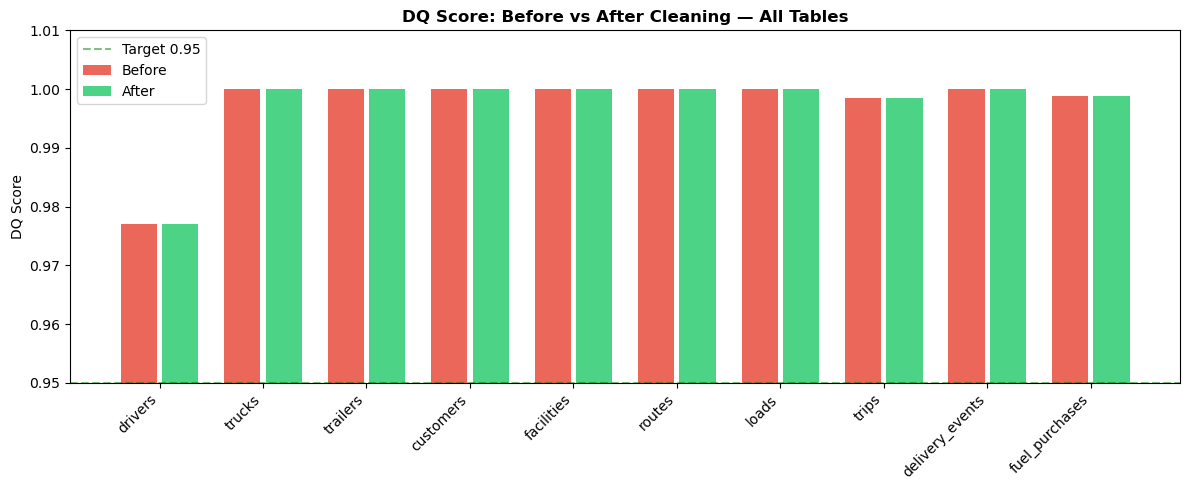

In [28]:
# ── Before/after DQ score comparison ──────────────────────────────
# Shows the cleaning ROI using quick_dq_score across all tables

table_pairs = {
    'drivers'        : (drivers,         pipe_drivers.clean_df,
                        'driver_id',        [], []),
    'trucks'         : (trucks,          pipe_trucks.clean_df,
                        'truck_id',         [], []),
    'trailers'       : (trailers,        pipe_trailers.clean_df,
                        'trailer_id',       [], []),
    'customers'      : (customers,       pipe_customers.clean_df,
                        'customer_id',      [], []),
    'facilities'     : (facilities,      pipe_facilities.clean_df,
                        'facility_id',      [], []),
    'routes'         : (routes,          pipe_routes.clean_df,
                        'route_id',
                        ['typical_distance_miles','base_rate_per_mile',
                         'fuel_surcharge_rate','typical_transit_days'], []),
    'loads'          : (loads,           pipe_loads.clean_df,
                        'load_id',
                        ['revenue','weight_lbs',
                         'fuel_surcharge','accessorial_charges'], []),
    'trips'          : (trips,           pipe_trips.clean_df,
                        'trip_id',
                        ['actual_distance_miles','fuel_gallons_used',
                         'actual_duration_hours','average_mpg','idle_time_hours'], []),
    'delivery_events': (delivery_events, pipe_delivery_events.clean_df,
                        'event_id',         ['detention_minutes'], []),
    'fuel_purchases' : (fuel_purchases,  pipe_fuel_purchases.clean_df,
                        'fuel_purchase_id',
                        ['gallons','price_per_gallon','total_cost'], []),
}

print(f"{'Table':<20} {'Before':>8} {'After':>8} {'Delta':>8}")
print('─' * 45)

results = []
for name, (df_before, df_after, pk, num_cols, cat_cols) in table_pairs.items():
    before    = quick_dq_score(df_before, pk, num_cols, cat_cols)
    after     = quick_dq_score(df_after,  pk, num_cols, cat_cols)
    avg_b     = round(sum(before.values()) / len(before), 4)
    avg_a     = round(sum(after.values())  / len(after),  4)
    delta     = avg_a - avg_b
    arrow     = '⬆️' if delta > 0 else ('➡️' if delta == 0 else '⬇️')
    print(f'{name:<20} {avg_b:>8.4f} {avg_a:>8.4f} {delta:>+8.4f} {arrow}')
    results.append({'table': name, 'before': avg_b, 'after': avg_a})

# Plot before/after comparison
results_df = pd.DataFrame(results)
fig, ax    = plt.subplots(figsize=(12, 5))
x          = np.arange(len(results_df))
ax.bar(x - 0.2, results_df['before'], 0.35,
       label='Before', color='#e74c3c', alpha=0.85)
ax.bar(x + 0.2, results_df['after'],  0.35,
       label='After',  color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df['table'], rotation=45, ha='right')
ax.set_ylim(0.95, 1.01)
ax.axhline(0.95, color='green', linestyle='--', alpha=0.5, label='Target 0.95')
ax.set_ylabel('DQ Score')
ax.set_title('DQ Score: Before vs After Cleaning — All Tables', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 4 Data Modeling

The data-driven DFM approach is applied to translate the reconciled
database into a star schema. Rather than discovering functional
dependencies automatically, they are defined from domain knowledge
of the reconciled database schema, this is the domain validation
step described in the course as the recommended hybrid approach.

### 4.1 Choice of Fact

The fact is selected by applying the four criteria of Golfarelli and Rizzi:
1. **Business event** — represents something that happens in the company
2. **Fine grain** — one row per atomic occurrence, not pre-aggregated
3. **Numeric measures** — values analysts will aggregate
4. **Multiple dimensions** — can be analysed from several perspectives

In [157]:
# ── Define fact table metadata ─────────────────────────────────────
# The trip is the atomic business event in road freight logistics:
# one driver, one truck, one trailer, one load, one route, one date.
# It satisfies all four Golfarelli-Rizzi criteria for fact selection.

fact_table = 'trips'
# Name of the source table selected as the fact
# - Business event: execution of a planned shipment
# - Fine grain: one row per executed trip
# - Measures: distance, fuel, duration, revenue, profit
# - Dimensions: driver, truck, trailer, customer, route, date, facility

fact_pk = 'trip_id'
# Primary key — defines the grain of the fact table

fact_grain = 'one row per executed trip'
# Grain statement — the finest level of detail in the data warehouse

fact_measures = [
    # ── Operational measures ───────────────────────────────────────
    'actual_distance_miles',    # Miles driven on the trip
    'fuel_gallons_used',        # Fuel consumed by the engine
    'average_mpg',              # Fuel efficiency for the trip
    'idle_time_hours',          # Hours engine running while stationary
    'actual_duration_hours',    # Hours from actual pickup to delivery
    # ── Financial measures ─────────────────────────────────────────
    'fuel_gallons_purchased',   # Total gallons purchased at fuel stops
    'fuel_purchased_cost',      # Total spent on fuel purchases
    'revenue',                  # Total amount billed to the customer
    'fuel_surcharge',           # Fuel surcharge applied to the load
    'accessorial_charges',      # Additional charges beyond base rate
    'weight_lbs',               # Weight of the freight carried
    # ── Datetime measures ──────────────────────────────────────────
    'planned_pickup_time',      # Scheduled pickup datetime
    'actual_pickup_time',       # Actual pickup datetime
    'planned_delivery_time',    # Scheduled delivery datetime
    'actual_delivery_time',     # Actual delivery datetime
    # ── Detention measures ─────────────────────────────────────────
    'detention_minutes_pickup',    # Detention at pickup facility
    'detention_minutes_delivery',  # Detention at delivery facility
    'detention_minutes_total',     # Total detention — derived
    # ── Derived time measures ──────────────────────────────────────
    'planned_duration_hours',   # Planned delivery - planned pickup time
    'pickup_delay_hours',       # Actual pickup - planned pickup time
    'delivery_delay_hours',     # Actual delivery - planned delivery time
    'delay_hours',              # Actual duration - planned duration
    # ── Derived financial measures ─────────────────────────────────
    'profit',                   # Revenue - fuel purchased cost
    'profit_margin',            # Profit / revenue
    'fuel_spend_per_mile',      # Fuel purchased cost / actual distance
    # ── KPI flags ──────────────────────────────────────────────────
    'on_time_flag',             # 1 if delivery delay <= 0, else 0
    'delay_category',           # early / on-time / late
]

# ── Print fact table definition ────────────────────────────────────
print(f'🎯 FACT: {fact_table}')
print(f'   Primary key : {fact_pk}')
print(f'   Grain       : {fact_grain}')
print(f'   Rows        : {len(trips):,}')
print(f'   Measures    : {len(fact_measures)}')
print(f'\n   ⊕ Measures:')
for m in fact_measures:
    print(f'      {m}')

🎯 FACT: trips
   Primary key : trip_id
   Grain       : one row per executed trip
   Rows        : 85,410
   Measures    : 27

   ⊕ Measures:
      actual_distance_miles
      fuel_gallons_used
      average_mpg
      idle_time_hours
      actual_duration_hours
      fuel_gallons_purchased
      fuel_purchased_cost
      revenue
      fuel_surcharge
      accessorial_charges
      weight_lbs
      planned_pickup_time
      actual_pickup_time
      planned_delivery_time
      actual_delivery_time
      detention_minutes_pickup
      detention_minutes_delivery
      detention_minutes_total
      planned_duration_hours
      pickup_delay_hours
      delivery_delay_hours
      delay_hours
      profit
      profit_margin
      fuel_spend_per_mile
      on_time_flag
      delay_category


### 4.2 Functional Dependencies

Functional dependencies (FDs) are the formal backbone of the
data-driven DFM approach. An FD **X → Y** states that knowing X
uniquely determines Y.

Rather than discovering FDs automatically from the data, they are
defined here from domain knowledge of the reconciled database schema.
This is the domain validation step — automatic discovery finds
observed dependencies in the sample, but only domain knowledge
confirms which ones are structurally meaningful for modeling.

In [158]:
# ── Build raw structural FDs from actual column names ──────────────
# The raw tree contains ONLY what exists in the reconciled database.
# No derived columns, no region, no pivoted delivery_events columns,
# no aggregated fuel measures — those are added during editing steps.

structural_fds = []
# Initialize empty list

# ── trip_id → all columns in trips ────────────────────────────────
for col in trips.columns:
    if col != 'trip_id':
        structural_fds.append(('trip_id', col))
# trip_id directly determines all attributes of the trips table

# ── driver_id → all columns in drivers ────────────────────────────
for col in drivers.columns:
    if col != 'driver_id':
        structural_fds.append(('driver_id', col))

# ── trailer_id → all columns in trailers ──────────────────────────
for col in trailers.columns:
    if col != 'trailer_id':
        structural_fds.append(('trailer_id', col))

# ── load_id → all columns in loads ────────────────────────────────
for col in loads.columns:
    if col != 'load_id':
        structural_fds.append(('load_id', col))

# ── customer_id → all columns in customers ────────────────────────
for col in customers.columns:
    if col != 'customer_id':
        structural_fds.append(('customer_id', col))

# ── route_id → all columns in routes ──────────────────────────────
for col in routes.columns:
    if col != 'route_id':
        structural_fds.append(('route_id', col))

# ── truck_id → all columns in trucks ──────────────────────────────
for col in trucks.columns:
    if col != 'truck_id':
        structural_fds.append(('truck_id', col))

# trip_id → fuel_purchase_id (1:N link)
structural_fds.append(('trip_id', 'fuel_purchase_id'))
# fuel_purchase_id → all columns in fuel_purchases excluding FKs already in tree
for col in fuel_purchases.columns:
    if col not in ['fuel_purchase_id', 'trip_id', 'truck_id','driver_id']:
        structural_fds.append(('fuel_purchase_id', col))

# trip_id → event_id (1:N link)
structural_fds.append(('trip_id', 'event_id'))
# event_id → all columns in delivery_events excluding FKs already in tree
for col in delivery_events.columns:
    if col not in ['event_id', 'trip_id','load_id']:
        structural_fds.append(('event_id', col))

# ── facility_id → all columns in facilities ───────────────────────
for col in facilities.columns:
    if col != 'facility_id':
        structural_fds.append(('facility_id', col))


# ── Print summary ──────────────────────────────────────────────────
print(f'✅ {len(structural_fds)} raw structural FDs defined')
print(f'\n   {"Parent":<30} {"Child"}')
print(f'   {"─"*50}')
for x, y in structural_fds:
    print(f'   {x:<30} → {y}')

✅ 91 raw structural FDs defined

   Parent                         Child
   ──────────────────────────────────────────────────
   trip_id                        → load_id
   trip_id                        → driver_id
   trip_id                        → truck_id
   trip_id                        → trailer_id
   trip_id                        → dispatch_date
   trip_id                        → actual_distance_miles
   trip_id                        → actual_duration_hours
   trip_id                        → fuel_gallons_used
   trip_id                        → average_mpg
   trip_id                        → idle_time_hours
   trip_id                        → trip_status
   driver_id                      → first_name
   driver_id                      → last_name
   driver_id                      → hire_date
   driver_id                      → termination_date
   driver_id                      → license_number
   driver_id                      → license_state
   driver_id                  

### 4.3 Attribute Tree Construction

The attribute tree is built by rooting at the fact primary key
and expanding outward through the structural FDs. Each FD
X → Y becomes an edge in the tree. The result is the raw
attribute tree before any editing steps.

In [159]:
class AttributeTree:
    """Data-driven attribute tree for DFM modeling."""
    # This class represents the attribute tree used in the data-driven DFM approach.
    # Nodes are attributes.
    # Edges represent functional dependencies: parent → child.

    def __init__(self, root: str):
        # Initialize the attribute tree with a root node.

        self.root = root
        # The root is the primary key of the selected fact.
        # In this lesson: order_id.

        self.children: Dict[str, List[str]] = {root: []}
        # Dictionary representing the tree structure.
        # Key   = parent attribute
        # Value = list of child attributes functionally dependent on the parent.

        self.measures: List[str] = []
        # Measures are stored separately because they are attached to the fact,
        # but they are not part of the descriptive hierarchy.


    def add_fd(self, parent: str, child: str):
        """Add an edge parent → child (FD)."""
        # Add a functional dependency to the tree.

        self.children.setdefault(parent, [])
        # Ensure the parent node exists in the tree.

        self.children.setdefault(child, [])
        # Ensure the child node also exists as a node,
        # even if it has no children yet.

        if child not in self.children[parent]:
            self.children[parent].append(child)
        # Add child only if the edge is not already present.
        # This avoids duplicate branches.


    def add_measure(self, name: str):
        # Attach a measure to the fact.

        if name not in self.measures:
            self.measures.append(name)
        # Avoid duplicate measures.


    def all_nodes(self) -> Set[str]:
        # Return the set of all attributes/nodes in the tree.

        return set(self.children.keys())


    def depth(self, node: str = None, visited=None) -> int:
        # Compute the maximum depth of the tree starting from a given node.

        node = node or self.root
        # If no node is specified, start from the root.

        visited = visited or set()
        # Keep track of visited nodes to avoid infinite recursion in case of cycles.

        if node in visited:
            return 0
        # Stop if a cycle is detected.

        visited.add(node)
        # Mark current node as visited.

        kids = self.children.get(node, [])
        # Get children of the current node.

        if not kids:
            return 0
        # Leaf nodes have depth 0.

        return 1 + max(self.depth(k, visited.copy()) for k in kids)
        # Recursively compute the deepest child path.


    def print_tree(self, node: str = None, indent: str = '', is_last: bool = True, visited=None):
        # Print the attribute tree as a stick diagram with connecting lines

        node    = node or self.root
        visited = visited or set()

        if node in visited:
            print(indent + '└── ' + node + ' (cycle)')
            return
        visited.add(node)

        if node == self.root:
            print('◆ ' + node)
            # Root gets a diamond marker
        else:
            connector = '└── ' if is_last else '├── '
            print(indent + connector + node)
            # Children get tree connectors

        children = self.children.get(node, [])
        # Get children of current node

        for i, child in enumerate(children):
            is_last_child = (i == len(children) - 1)
            # Last child gets └── all others get ├──

            if node == self.root:
                new_indent = ''
                # No indent prefix for root's direct children
            else:
                new_indent = indent + ('    ' if is_last else '│   ')
                # Add vertical bar for non-last nodes

            self.print_tree(child, new_indent, is_last_child, visited.copy())

        if node == self.root and self.measures:
            print()
            print('Measures:')
            for m in self.measures:
                print(f'  ⊕ {m}')
            # Print measures attached to the fact root


    def to_dict(self) -> dict:
        # Convert tree metadata to a dictionary for saving or reuse.

        return {
            'root': self.root,
            # Root node of the attribute tree

            'children': self.children,
            # Full parent → children structure

            'measures': self.measures,
            # Measures attached to the fact

            'depth': self.depth(),
            # Maximum tree depth

            'node_count': len(self.all_nodes()),
            # Number of attributes in the tree
        }

print('✅ AttributeTree class defined')

✅ AttributeTree class defined


In [160]:
# ── Build raw attribute tree ───────────────────────────────────────
# Initialize tree rooted at trip_id and add all structural FDs

tree = AttributeTree(root=fact_pk)
# Root = fact primary key (trip_id)

for parent, child in structural_fds:
    tree.add_fd(parent, child)
# Add each structural FD as an edge in the tree

# ── Print raw tree ─────────────────────────────────────────────────
print('🌳 Raw Attribute Tree (before editing):\n')
tree.print_tree()
print(f'\n   Depth: {tree.depth()}  |  Nodes: {len(tree.all_nodes())}')

🌳 Raw Attribute Tree (before editing):

◆ trip_id
├── load_id
│   ├── customer_id
│   │   ├── customer_name
│   │   ├── customer_type
│   │   ├── credit_terms_days
│   │   ├── primary_freight_type
│   │   ├── account_status
│   │   ├── contract_start_date
│   │   └── annual_revenue_potential
│   ├── route_id
│   │   ├── origin_city
│   │   ├── origin_state
│   │   ├── destination_city
│   │   ├── destination_state
│   │   ├── typical_distance_miles
│   │   ├── base_rate_per_mile
│   │   ├── fuel_surcharge_rate
│   │   └── typical_transit_days
│   ├── load_date
│   ├── load_type
│   ├── weight_lbs
│   ├── pieces
│   ├── revenue
│   ├── fuel_surcharge
│   ├── accessorial_charges
│   ├── load_status
│   └── booking_type
├── driver_id
│   ├── first_name
│   ├── last_name
│   ├── hire_date
│   ├── termination_date
│   ├── license_number
│   ├── license_state
│   ├── date_of_birth
│   ├── home_terminal
│   ├── employment_status
│   ├── cdl_class
│   └── years_experience
├── truck_id
│   ├── 

### 4.4 Attribute Tree Editing

The raw attribute tree is edited through seven motivated steps.
Each step applies pruning or grafting to produce the final tree
that maps directly to the star schema.

- **Pruning** — removes nodes that are not useful for analysis.
  Children of a pruned node are reattached to its parent.
- **Grafting** — moves a node to a new parent, or adds new derived
  nodes that do not exist in the raw data.

In [161]:
def prune(tree: AttributeTree, nodes_to_prune: list):
    """
    Remove nodes from the attribute tree WITHOUT deleting their children.

    This allows us to:
    - remove intermediate nodes (e.g., order_date)
    - keep useful descendants (e.g., order_month → quarter → year)
    - later reattach them via grafting
    """

    removed = set()
    # Track nodes that are explicitly removed

    for node in nodes_to_prune:

        if node not in tree.children:
            continue
        # Skip if node does not exist in the tree

        children = tree.children.get(node, [])
        # Store children BEFORE removing node

        # ── Remove node from its parents ────────────────────────────
        for parent in list(tree.children.keys()):
            if node in tree.children[parent]:

                tree.children[parent].remove(node)
                # Remove node from parent's children list

                # Reattach children to the same parent (preserve hierarchy)
                for c in children:
                    if c not in tree.children[parent]:
                        tree.children[parent].append(c)

        # ── Remove node itself ──────────────────────────────────────
        tree.children.pop(node, None)
        # Delete node from tree structure

        removed.add(node)
        # Track removed node

    return removed


def graft(tree: AttributeTree, node: str, new_parent: str):
    """
    Move `node` so its new parent is `new_parent`.
    Preserves the subtree under `node`.
    """

    # ── Remove node from old parent ─────────────────────────────────
    for parent in list(tree.children.keys()):
        if node in tree.children[parent]:
            tree.children[parent].remove(node)

    # ── Add node to new parent (avoid duplicates) ───────────────────
    if node not in tree.children.get(new_parent, []):
        tree.add_fd(new_parent, node)

print('✅ prune() and graft() functions defined')

✅ prune() and graft() functions defined


In [162]:
# ── Step 1 — Prune non-analytical attributes ───────────────────────
# Remove attributes that carry no value for delivery time or financial
# performance analysis. These are operationally necessary in the source
# system but add no analytical dimension to the data warehouse.

pruned_step1 = [
    # from drivers — operational/legal identifiers
    'license_number', 'license_state', 'date_of_birth', 'cdl_class',

    # from trucks — operational/legal identifiers
    'vin', 'unit_number', 'acquisition_date',
    'acquisition_mileage', 'tank_capacity_gallons',
    'fuel_type', 'home_terminal',

    # from trailers — operational/legal identifiers
    'trailer_number', 'current_location', 'length_feet',

    # from customers — contract management attributes
    'credit_terms_days', 'contract_start_date',
    'annual_revenue_potential',

    # from loads — operational attributes not needed at trip level
    'pieces', 'load_status',

    # from loads — financial measures belong in fact_measures not in tree
    'weight_lbs', 'revenue', 'fuel_surcharge', 'accessorial_charges',

    # from trips — trip_status confirmed all Completed in DQA
    'trip_status',

    # from trips — operational measures belong in fact_measures not in tree
    'actual_distance_miles', 'actual_duration_hours', 'fuel_gallons_used','average_mpg', 'idle_time_hours',

    # from facilities — scheduling constraints not needed for analysis
    'dock_doors', 'operating_hours',

    # from delivery_events — on_time_flag recomputed as derived measure
    # location_city and location_state covered by facilities dimension
    'on_time_flag',

    # from fuel_purchases — transaction detail not needed after aggregation
    'fuel_card_number',
]

removed1 = prune(tree, pruned_step1)
# Apply pruning — removes nodes, reattaches children to parent

print(f'✂️  Step 1 — Pruned {len(removed1)} non-analytical attributes')
print(f'   Remaining nodes: {len(tree.all_nodes())}')

✂️  Step 1 — Pruned 33 non-analytical attributes
   Remaining nodes: 52


In [163]:
# ── Step 1b — Denormalize customer_id and route_id onto trip_id ────
# In the reconciled database customer_id and route_id are linked
# to trip_id through load_id (trip → load → customer/route).
# In the star schema they are denormalized directly into fact_trips
# as FK columns to avoid multi-hop joins at query time.
# They are grafted directly onto trip_id so the star schema generator
# picks them up as separate top-level dimension tables.

graft(tree, 'customer_id', fact_pk)
# customer_id: load_id → customer_id becomes trip_id → customer_id
# dim_customer becomes a direct dimension of fact_trips

graft(tree, 'route_id', fact_pk)
# route_id: load_id → route_id becomes trip_id → route_id
# dim_routes becomes a direct dimension of fact_trips

print(f'🔀 Step 1b — Denormalization: customer_id and route_id')
print(f'   grafted directly onto trip_id')
print(f'   dim_loads now contains only load_type and booking_type')
print(f'   Remaining nodes: {len(tree.all_nodes())}')

🔀 Step 1b — Denormalization: customer_id and route_id
   grafted directly onto trip_id
   dim_loads now contains only load_type and booking_type
   Remaining nodes: 52


In [164]:
# ── Step 2 — Dissolve delivery_events branch ──────────────────────
# delivery_events has a 1:N relationship with trips (two rows per trip).
# It cannot be modelled as a dimension without duplicating fact rows.
# The pivot is performed during ETL — pickup and delivery timestamps
# and detention columns become measures in the fact table.
# The event_id branch is dissolved from the tree entirely.
# facility_id is preserved and handled in Step 3.

pruned_step2 = [
    'event_id',             # Dissolved — replaced by pivot onto trip_id
    'event_type',           # Consumed by the pivot
    'location_city',        # Covered by facilities dimension
    'location_state',       # Covered by facilities dimension
    'scheduled_datetime',   # Renamed and stored as measures during pivot
    'actual_datetime',      # Renamed and stored as measures during pivot
    'detention_minutes',    # Renamed and stored as measures during pivot
    'planned_pickup_time',  # Measure — stored in fact_measures not in tree
    'actual_pickup_time',   # Measure — stored in fact_measures not in tree
    'planned_delivery_time',# Measure — stored in fact_measures not in tree
    'actual_delivery_time', # Measure — stored in fact_measures not in tree
    'detention_minutes_pickup',   # Measure — stored in fact_measures
    'detention_minutes_delivery', # Measure — stored in fact_measures
]

removed2 = prune(tree, pruned_step2)
# Prune the delivery_events branch — do NOT add back to tree
# These columns are measures attached to fact_measures, not dimension nodes

print(f'↔️  Step 2 — Delivery events branch dissolved')
print(f'   Pruned: {len(removed2)} nodes')
print(f'   Datetime and detention columns stored as measures in fact_measures')
print(f'   ETL pivot produces: planned_pickup_time, actual_pickup_time,')
print(f'                       planned_delivery_time, actual_delivery_time,')
print(f'                       detention_minutes_pickup, detention_minutes_delivery')
print(f'   Remaining nodes: {len(tree.all_nodes())}')

↔️  Step 2 — Delivery events branch dissolved
   Pruned: 7 nodes
   Datetime and detention columns stored as measures in fact_measures
   ETL pivot produces: planned_pickup_time, actual_pickup_time,
                       planned_delivery_time, actual_delivery_time,
                       detention_minutes_pickup, detention_minutes_delivery
   Remaining nodes: 45


In [165]:
# ── Step 3 — Graft facilities as role-playing dimension ────────────
# After dissolving the delivery_events branch, facility_id loses its
# parent. Since each trip has both a pickup and a delivery facility,
# facility_id is grafted onto trip_id as two separate FK columns:
# pickup_facility_id and delivery_facility_id.
# Both reference the same physical dim_facilities table — making it
# a role-playing dimension.

# Remove the old flat facility_id node
pruned_step3 = [
    'facility_id',
    'facility_name',  # add these
    'facility_type',
    'city',
    'state',
    'latitude',
    'longitude',
]
removed3 = prune(tree, pruned_step3)

# Add pickup and delivery facility branches
tree.add_fd(fact_pk, 'pickup_facility_id')
tree.add_fd(fact_pk, 'delivery_facility_id')
# Both FK columns reference the same dim_facilities table

# Graft facility attributes under both roles
for col in ['facility_name', 'facility_type',
            'city', 'state', 'latitude', 'longitude']:
    tree.add_fd('pickup_facility_id',   f'pickup_{col}')
    tree.add_fd('delivery_facility_id', f'delivery_{col}')
# Facility attributes replicated under each role for clarity

print(f'🔄  Step 3 — Facilities grafted as role-playing dimension')
print(f'   pickup_facility_id   → dim_facilities (pickup role)')
print(f'   delivery_facility_id → dim_facilities (delivery role)')
print(f'   Remaining nodes: {len(tree.all_nodes())}')

🔄  Step 3 — Facilities grafted as role-playing dimension
   pickup_facility_id   → dim_facilities (pickup role)
   delivery_facility_id → dim_facilities (delivery role)
   Remaining nodes: 52


In [166]:
# ── Step 4 — Dissolve fuel_purchases branch ────────────────────────
# fuel_purchases has a 1:N relationship with trips.
# Individual transactions are aggregated per trip_id during ETL.
# Two scalar measures are grafted directly onto trip_id.
# The fuel_purchase_id branch is dissolved from the tree.

pruned_step4 = [
    'fuel_purchase_id',     # Dissolved — replaced by aggregation
    'gallons',              # Aggregated into fuel_gallons_purchased
    'price_per_gallon',     # Not needed after aggregation
    'total_cost',           # Aggregated into fuel_purchased_cost
    'purchase_date',        # Transaction detail not needed
    'location_city',        # Transaction detail not needed
    'location_state',       # Transaction detail not needed
    'fuel_gallons_purchased', # Measure — stored in fact_measures not in tree
    'fuel_purchased_cost',    # Measure — stored in fact_measures not in tree
]

removed4 = prune(tree, pruned_step4)

print(f'⛽  Step 4 — Fuel purchases branch dissolved')
print(f'   fuel_gallons_purchased = SUM(gallons) per trip → measure')
print(f'   fuel_purchased_cost    = SUM(total_cost) per trip → measure')
print(f'   Remaining nodes: {len(tree.all_nodes())}')

⛽  Step 4 — Fuel purchases branch dissolved
   fuel_gallons_purchased = SUM(gallons) per trip → measure
   fuel_purchased_cost    = SUM(total_cost) per trip → measure
   Remaining nodes: 47


In [167]:
# ── Step 5 — Add route geographic hierarchy ────────────────────────
# The state-to-city mapping is largely one-to-one (confirmed in DQA).
# Restructure the flat route attributes into a proper three-level
# geographic hierarchy: city → state → region.
# This enables roll-up from city to state to regional aggregations.

US_CENSUS_REGIONS = {
    'TX': 'South',  'TN': 'South',  'NC': 'South',
    'GA': 'South',  'FL': 'South',
    'CA': 'West',   'AZ': 'West',   'NV': 'West',
    'CO': 'West',   'OR': 'West',   'WA': 'West',
    'NY': 'Northeast', 'PA': 'Northeast',
    'OH': 'Midwest', 'IL': 'Midwest', 'MI': 'Midwest',
    'MN': 'Midwest', 'MO': 'Midwest', 'IN': 'Midwest',
}
# Maps each state in the dataset to its US Census Bureau region

# ── Restructure origin hierarchy ───────────────────────────────────
# Remove flat origin_state from route_id
# (it was added directly from routes.columns in the raw FDs)
graft(tree, 'origin_state', 'origin_city')
# origin_state is now a child of origin_city instead of route_id
# creating the chain: route_id → origin_city → origin_state

tree.add_fd('origin_state', 'origin_region')
# Add region as child of state — derived from US Census mapping

# ── Restructure destination hierarchy ──────────────────────────────
graft(tree, 'destination_state', 'destination_city')
# destination_state is now a child of destination_city

tree.add_fd('destination_state', 'destination_region')
# Add region as child of state

print(f'🗺️  Step 5 — Route geographic hierarchy restructured')
print(f'   origin:      route_id → origin_city → origin_state → origin_region')
print(f'   destination: route_id → destination_city → destination_state → destination_region')
print(f'   States mapped: {len(US_CENSUS_REGIONS)}')
print(f'   Regions: {sorted(set(US_CENSUS_REGIONS.values()))}')
print(f'   Remaining nodes: {len(tree.all_nodes())}')

🗺️  Step 5 — Route geographic hierarchy restructured
   origin:      route_id → origin_city → origin_state → origin_region
   destination: route_id → destination_city → destination_state → destination_region
   States mapped: 19
   Regions: ['Midwest', 'Northeast', 'South', 'West']
   Remaining nodes: 49


In [168]:
# ── Step 6 — Promote dispatch_date to dim_date ─────────────────────
# dispatch_date is replaced by a date_id surrogate key pointing to
# a generated dim_date dimension. This exposes the time hierarchy:
# day → month → quarter → year, enabling OLAP drill-down and roll-up.
# dim_date is not extracted from source data — it is generated
# programmatically during ETL to cover the full simulation window.

# Remove flat dispatch_date node
pruned_step6 = ['dispatch_date']
removed6 = prune(tree, pruned_step6)

# Add date_id as new time dimension FK
tree.add_fd(fact_pk, 'date_id')
# date_id is the YYYYMMDD surrogate key linking to dim_date

# Add time hierarchy under date_id
tree.add_fd('date_id', 'date')
tree.add_fd('date_id', 'day')
tree.add_fd('date_id', 'weekday')
tree.add_fd('day', 'month')
tree.add_fd('month',   'quarter')
tree.add_fd('quarter', 'year')
# Time hierarchy: day → month → quarter → year

print(f'📅  Step 6 — dispatch_date promoted to dim_date')
print(f'   date_id → dim_date')
print(f'   Hierarchy: day → month → quarter → year')
print(f'   Remaining nodes: {len(tree.all_nodes())}')

📅  Step 6 — dispatch_date promoted to dim_date
   date_id → dim_date
   Hierarchy: day → month → quarter → year
   Remaining nodes: 55


In [169]:
# ── Step 7 — Verify and drop load_date ────────────────────────────
# The DQA consistency check in Section 3 confirmed that load_date
# in loads equals dispatch_date in trips across all 85,410 records.
# load_date is therefore redundant and is dropped from the tree.

pruned_step7 = ['load_date']
removed7 = prune(tree, pruned_step7)

print(f'🗑️  Step 7 — load_date verified as redundant and dropped')
print(f'   Confirmed equal to dispatch_date across all 85,410 records')
print(f'   Removed: {sorted(removed7)}')

🗑️  Step 7 — load_date verified as redundant and dropped
   Confirmed equal to dispatch_date across all 85,410 records
   Removed: ['load_date']


In [170]:
# ── Add measures to the fact root ──────────────────────────────────
# Measures are attached after all editing steps are complete.
# They are stored separately from the descriptive hierarchy.

for m in fact_measures:
    tree.add_measure(m)
# Attach all measures defined in Section 4.1

# ── Edited attribute tree summary ─────────────────────────────────
print('🌳 Edited Attribute Tree (after 7 editing steps):\n')
tree.print_tree()
print(f'\n   Depth: {tree.depth()}  |  Nodes: {len(tree.all_nodes())}')
print(f'\n   Note: Raw and edited attribute tree diagrams are')
print(f'   produced in draw.io and included in the report.')

🌳 Edited Attribute Tree (after 7 editing steps):

◆ trip_id
├── load_id
│   ├── load_type
│   └── booking_type
├── driver_id
│   ├── first_name
│   ├── last_name
│   ├── hire_date
│   ├── termination_date
│   ├── employment_status
│   └── years_experience
├── truck_id
│   ├── make
│   ├── model_year
│   └── status
├── trailer_id
│   ├── trailer_type
│   ├── model_year
│   └── status
├── customer_id
│   ├── customer_name
│   ├── customer_type
│   ├── primary_freight_type
│   └── account_status
├── route_id
│   ├── origin_city
│   │   └── origin_state
│   │       └── origin_region
│   ├── destination_city
│   │   └── destination_state
│   │       └── destination_region
│   ├── typical_distance_miles
│   ├── base_rate_per_mile
│   ├── fuel_surcharge_rate
│   └── typical_transit_days
├── pickup_facility_id
│   ├── pickup_facility_name
│   ├── pickup_facility_type
│   ├── pickup_city
│   ├── pickup_state
│   ├── pickup_latitude
│   └── pickup_longitude
├── delivery_facility_id
│   ├── deliv

### 4.5 Measure Additivity

Every measure in the fact table is classified by its additivity.
This is critical for correct dashboard design — BI tools will not
prevent wrong aggregations if additivity is not documented.

| Type | Definition | Valid aggregations |
|---|---|---|
| **Additive** | Can be SUMmed across all dimensions | SUM, AVG, MIN, MAX |
| **Semi-additive** | Summable across some dimensions but not time | SUM (not time), AVG |
| **Non-additive** | SUM is never meaningful — ratios, flags, categories | AVG, MIN, MAX only |

In [171]:
# ── Measure additivity classification ─────────────────────────────
# Defines how each measure behaves under aggregation in the DW.
# Critical for correct BI dashboard design — misclassifying additivity
# leads to wrong aggregations that BI tools will not prevent.

MEASURE_ADDITIVITY = {

    # ── Additive measures ──────────────────────────────────────────
    # Can be SUMmed across all dimensions without loss of meaning

    'actual_distance_miles'    : 'additive',
    # Total miles driven across any selection of trips

    'fuel_gallons_used'        : 'additive',
    # Total fuel consumed across any selection of trips

    'idle_time_hours'          : 'additive',
    # Total idle time across any selection of trips

    'actual_duration_hours'    : 'additive',
    # Total trip duration across any selection of trips

    'fuel_gallons_purchased'   : 'additive',
    # Total gallons purchased across any selection of trips

    'fuel_purchased_cost'      : 'additive',
    # Total fuel spend across any selection of trips

    'revenue'                  : 'additive',
    # Total revenue across any selection of trips

    'fuel_surcharge'           : 'additive',
    # Total fuel surcharge across any selection of trips

    'accessorial_charges'      : 'additive',
    # Total accessorial charges across any selection of trips

    'detention_minutes_pickup' : 'additive',
    # Total pickup detention across any selection of trips

    'detention_minutes_delivery': 'additive',
    # Total delivery detention across any selection of trips

    'detention_minutes_total'  : 'additive',
    # Total detention across any selection of trips

    'profit'                   : 'additive',
    # Total profit across any selection of trips

    'delay_hours'              : 'additive',
    # Total delay hours across any selection of trips

    'pickup_delay_hours'       : 'additive',
    # Total pickup delay across any selection of trips

    'delivery_delay_hours'     : 'additive',
    # Total delivery delay across any selection of trips

    'planned_duration_hours'   : 'additive',
    # Total planned duration across any selection of trips

    # ── Datetime measures ──────────────────────────────────────────────
    # Datetimes are non-additive — they cannot be summed or averaged
    # They are used for calculation only (subtraction to get delays)

    'planned_pickup_time'   : 'non_additive',
    # Scheduled pickup datetime — used for delay calculation only

    'actual_pickup_time'    : 'non_additive',
    # Actual pickup datetime — used for delay calculation only

    'planned_delivery_time' : 'non_additive',
    # Scheduled delivery datetime — used for delay calculation only

    'actual_delivery_time'  : 'non_additive',
    # Actual delivery datetime — used for delay calculation only

    # ── Non-additive measures ──────────────────────────────────────
    # SUM is never meaningful — must use AVG, MIN, MAX or recompute

    'average_mpg'              : 'non_additive',
    # Ratio — summing MPG values across trips is meaningless
    # Correct aggregation: AVG or recompute as SUM(miles)/SUM(gallons)

    'profit_margin'            : 'non_additive',
    # Ratio (profit/revenue) — must be recomputed from additive components
    # Correct aggregation: SUM(profit)/SUM(revenue)

    'fuel_spend_per_mile'      : 'non_additive',
    # Ratio — must be recomputed from additive components
    # Correct aggregation: SUM(fuel_cost)/SUM(distance)

    'weight_lbs'               : 'non_additive',
    # Weight per individual trip — summing across trips is not meaningful
    # Correct aggregation: AVG

    'on_time_flag'             : 'non_additive',
    # Binary flag — SUM gives count, AVG gives on-time rate
    # Use AVG to compute on-time percentage

    'delay_category'           : 'non_additive',
    # Categorical — not numerically aggregable
    # Use COUNT or MODE
}

# ── Print additivity summary ───────────────────────────────────────
icons = {
    'additive'     : '✅',
    'semi_additive': '⚠️',
    'non_additive' : '❌'
}

print('⊕ Measure additivity classification:\n')
print(f'  {"Measure":<30} {"Additivity":<16} {""}')
print(f'  {"─"*55}')
for measure, additivity in MEASURE_ADDITIVITY.items():
    icon = icons[additivity]
    print(f'  {measure:<30} {additivity:<16} {icon}')

print(f'\n  {"─"*55}')
print(f'  Additive    : {sum(1 for v in MEASURE_ADDITIVITY.values() if v == "additive")}')
print(f'  Non-additive: {sum(1 for v in MEASURE_ADDITIVITY.values() if v == "non_additive")}')

⊕ Measure additivity classification:

  Measure                        Additivity       
  ───────────────────────────────────────────────────────
  actual_distance_miles          additive         ✅
  fuel_gallons_used              additive         ✅
  idle_time_hours                additive         ✅
  actual_duration_hours          additive         ✅
  fuel_gallons_purchased         additive         ✅
  fuel_purchased_cost            additive         ✅
  revenue                        additive         ✅
  fuel_surcharge                 additive         ✅
  accessorial_charges            additive         ✅
  detention_minutes_pickup       additive         ✅
  detention_minutes_delivery     additive         ✅
  detention_minutes_total        additive         ✅
  profit                         additive         ✅
  delay_hours                    additive         ✅
  pickup_delay_hours             additive         ✅
  delivery_delay_hours           additive         ✅
  planned_duration_ho

In [172]:
# ── Demonstration — why non-additive measures must not be SUMmed ───
# Shows the difference between correct and incorrect aggregations
# using real data from the trips and loads tables

total_revenue = loads['revenue'].sum()
# Correct: revenue is additive — SUM across all loads is meaningful

wrong_margin  = trips.merge(
    loads[['load_id', 'revenue']], on='load_id'
)['revenue'].sum() / len(trips)
# WRONG approach: averaging revenue to get margin is not correct

correct_profit = (
    loads['revenue'].sum() -
    fuel_purchases.groupby('trip_id')['total_cost'].sum().sum()
)
# Correct: profit = SUM(revenue) - SUM(fuel_cost) — both additive

correct_margin = correct_profit / total_revenue
# Correct: profit_margin recomputed from additive components

avg_mpg_wrong  = trips['average_mpg'].mean()
# Simplified average — not fully correct

avg_mpg_correct = (
    trips['actual_distance_miles'].sum() /
    trips['fuel_gallons_used'].sum()
)
# Correct: recompute from additive components SUM(miles)/SUM(gallons)

print('📊 Correct vs incorrect aggregations:\n')
print(f'  SUM(revenue)            = ${total_revenue:>15,.2f}  ✅ additive')
print(f'  AVG(average_mpg)        = {avg_mpg_wrong:>15.2f}  ⚠️  simplified')
print(f'  Recomputed MPG          = {avg_mpg_correct:>15.2f}  ✅ correct')
print(f'  Recomputed profit_margin= {correct_margin:>15.2%}  ✅ correct')

📊 Correct vs incorrect aggregations:

  SUM(revenue)            = $ 262,525,800.29  ✅ additive
  AVG(average_mpg)        =            6.50  ⚠️  simplified
  Recomputed MPG          =            6.45  ✅ correct
  Recomputed profit_margin=          63.59%  ✅ correct


### 4.6 DFM Fact Schema

The Dimensional Fact Model (Golfarelli--Rizzi) translates the edited
attribute tree into a formal conceptual schema. The fact box contains
all measures. Dimension lines radiate outward with dots marking
hierarchy levels. The graphical DFM diagram is produced in draw.io
and included in the report. The textual representation below is
generated directly from the edited attribute tree.

In [173]:
def to_dfm_text(tree: AttributeTree) -> str:
    """
    Generate a textual representation of the DFM schema.

    Structure:
    - Fact box with measures
    - Dimensions with hierarchical levels (●)
    """

    lines = []

    # ── FACT BOX ───────────────────────────────────────────────────
    width = 46
    # Fixed width for alignment

    lines.append('╔' + '═' * width + '╗')
    lines.append(f'║  FACT: {tree.root:<{width-8}s}║')
    lines.append('║' + ' ' * width + '║')

    for m in tree.measures:
        lines.append(f'║    ⊕ {m:<{width-6}s}║')
        # ⊕ marks measures (consistent with lectures)

    lines.append('╚' + '═' * width + '╝')
    lines.append('')

    # ── DIMENSIONS & HIERARCHIES ───────────────────────────────────
    lines.append('Dimensions & Hierarchies (● = level):')

    def traverse(node, depth=1):
        # Recursive traversal for proper hierarchy printing

        for child in tree.children.get(node, []):
            indent = '   ' + '  ' * (depth - 1)
            lines.append(f'{indent}● {child}')
            traverse(child, depth + 1)

    # Start from fact root
    for dim in tree.children.get(tree.root, []):
        lines.append(f'   ● {dim}')
        traverse(dim, depth=2)

    return '\n'.join(lines)


print('✅ to_dfm_text() function defined')

✅ to_dfm_text() function defined


In [174]:
# ── Generate and print DFM textual schema ─────────────────────────
# The DFM schema is derived directly from the edited attribute tree.
# Fact box contains all 23 measures.
# Dimensions and hierarchies are shown with ● markers.

print(to_dfm_text(tree))

print('\n   Note: The graphical DFM diagram is produced in draw.io')
print('   and included in the report.')

╔══════════════════════════════════════════════╗
║  FACT: trip_id                               ║
║                                              ║
║    ⊕ actual_distance_miles                   ║
║    ⊕ fuel_gallons_used                       ║
║    ⊕ average_mpg                             ║
║    ⊕ idle_time_hours                         ║
║    ⊕ actual_duration_hours                   ║
║    ⊕ fuel_gallons_purchased                  ║
║    ⊕ fuel_purchased_cost                     ║
║    ⊕ revenue                                 ║
║    ⊕ fuel_surcharge                          ║
║    ⊕ accessorial_charges                     ║
║    ⊕ weight_lbs                              ║
║    ⊕ planned_pickup_time                     ║
║    ⊕ actual_pickup_time                      ║
║    ⊕ planned_delivery_time                   ║
║    ⊕ actual_delivery_time                    ║
║    ⊕ detention_minutes_pickup                ║
║    ⊕ detention_minutes_delivery              ║
║    ⊕ detention_min

### 4.7 Star Schema Definition

The edited attribute tree is translated into the logical star schema.
Each top-level branch of the tree becomes a dimension table.
The fact table retains all measures and adds FK columns pointing
to each dimension.

Two special cases:
- **dim\_loads** — load\_id is a pass-through since loads and trips
  are 1:1. load\_type and booking\_type are the only retained attributes.
- **dim\_facilities** — role-playing dimension referenced twice by
  fact\_trips under pickup\_facility\_id and delivery\_facility\_id.
  Both FKs point to the same physical table.

In [175]:
def build_star_schema(tree: AttributeTree) -> dict:
    """
    Translate the edited Attribute Tree into a logical Star Schema.
    Adapted for logistics dataset — uses plural table names.
    """

    # ── Name mapping: tree node → dimension table name ─────────────
    dim_name_map = {
        'load_id'             : 'dim_loads',
        'driver_id'           : 'dim_drivers',
        'truck_id'            : 'dim_trucks',
        'trailer_id'          : 'dim_trailer',
        'customer_id'         : 'dim_customer',
        'route_id'            : 'dim_routes',
        'pickup_facility_id'  : 'dim_facilities',
        'delivery_facility_id': 'dim_facilities',
        'date_id'             : 'dim_date',
    }
    # Explicit mapping ensures correct plural names and
    # that both facility FKs map to the same dim_facilities table

    star = {
        'fact_table': {
            'name'        : 'fact_trips',
            # Fact table name — one row per executed trip

            'grain'       : fact_grain,
            # Grain statement from Section 4.1

            'measures'    : tree.measures,
            # Measures attached to the fact root

            'foreign_keys': []
            # Will contain dimension table names
        },
        'dimension_tables': {}
    }

    # ── Build dimension tables from top-level branches ─────────────
    for dim in tree.children.get(tree.root, []):
        # Iterate over each direct child of the fact root

        dim_name = dim_name_map.get(dim, f'dim_{dim.replace("_id", "")}')
        # Use explicit mapping or fall back to auto-generated name

        # Collect all descendants (hierarchy levels) of this dimension
        levels = [dim]
        stack  = list(tree.children.get(dim, []))

        while stack:
            n = stack.pop(0)
            levels.append(n)
            stack.extend(tree.children.get(n, []))
        # BFS traversal to collect all hierarchy levels

        if dim_name not in star['dimension_tables']:
            # Only add once — dim_facilities appears twice (role-playing)
            star['dimension_tables'][dim_name] = {
                'surrogate_key': f'{dim_name}_sk',
                # Surrogate key generated in the DW

                'natural_key'  : dim,
                # Original business key for traceability

                'levels'       : levels,
                # Denormalized hierarchy levels

                'role_playing' : dim_name == 'dim_facilities',
                # Flag role-playing dimensions

                'description'  : (
                    'Hierarchy: ' + ' → '.join(levels)
                    if len(levels) > 1
                    else f'Single-level: {dim}'
                )
            }

        if dim_name not in star['fact_table']['foreign_keys']:
            star['fact_table']['foreign_keys'].append(dim_name)
        # Add to FK list — avoid duplicates for role-playing dimensions

    return star

print('✅ build_star_schema() function defined')

✅ build_star_schema() function defined


In [176]:
# ── Generate star schema from edited attribute tree ────────────────
star_schema = build_star_schema(tree)
# Translate the edited attribute tree into the logical star schema

# ── Print star schema summary ──────────────────────────────────────
print('⭐ STAR SCHEMA:\n')
print(f'FACT TABLE: {star_schema["fact_table"]["name"]}')
print(f'   Grain   : {fact_grain}')
print(f'   Measures: {len(star_schema["fact_table"]["measures"])}')
print(f'   FKs     : {len(star_schema["fact_table"]["foreign_keys"])}')
print(f'\nDIMENSION TABLES:')
for name, meta in star_schema['dimension_tables'].items():
    print(f'\n   {name}')
    print(f'      SK    : {meta["surrogate_key"]}')
    print(f'      NK    : {meta["natural_key"]}')
    print(f'      Levels: {len(meta["levels"])}')
    print(f'      Hier  : {meta["description"][:80]}')

⭐ STAR SCHEMA:

FACT TABLE: fact_trips
   Grain   : one row per executed trip
   Measures: 27
   FKs     : 8

DIMENSION TABLES:

   dim_loads
      SK    : dim_loads_sk
      NK    : load_id
      Levels: 3
      Hier  : Hierarchy: load_id → load_type → booking_type

   dim_drivers
      SK    : dim_drivers_sk
      NK    : driver_id
      Levels: 7
      Hier  : Hierarchy: driver_id → first_name → last_name → hire_date → termination_date → e

   dim_trucks
      SK    : dim_trucks_sk
      NK    : truck_id
      Levels: 4
      Hier  : Hierarchy: truck_id → make → model_year → status

   dim_trailer
      SK    : dim_trailer_sk
      NK    : trailer_id
      Levels: 4
      Hier  : Hierarchy: trailer_id → trailer_type → model_year → status

   dim_customer
      SK    : dim_customer_sk
      NK    : customer_id
      Levels: 5
      Hier  : Hierarchy: customer_id → customer_name → customer_type → primary_freight_type → 

   dim_routes
      SK    : dim_routes_sk
      NK    : route_id

### 4.8 Glossary of Measures

The glossary formally documents each measure: its business meaning,
computation, unit, additivity classification, and valid aggregations.
This is a required deliverable and is included in the report.

In [178]:
# ── Glossary of measures ───────────────────────────────────────────
# Formal documentation of all measures in fact_trips.
# Defines meaning, computation, unit, additivity, and valid aggregations.

glossary = [

    # ── Operational measures (base) ───────────────────────────────
    {
        'measure'           : 'actual_distance_miles',
        'definition'        : 'Miles driven on the trip',
        'unit'              : 'miles',
        'computation'       : 'trips.actual_distance_miles (raw)',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'fuel_gallons_used',
        'definition'        : 'Fuel consumed by the engine during the trip',
        'unit'              : 'gallons',
        'computation'       : 'trips.fuel_gallons_used (raw)',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'average_mpg',
        'definition'        : 'Fuel efficiency for the trip',
        'unit'              : 'mpg',
        'computation'       : 'trips.average_mpg (raw) — recompute as SUM(miles)/SUM(gallons)',
        'additivity'        : 'non_additive',
        'valid_aggregations': ['AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'idle_time_hours',
        'definition'        : 'Hours the engine was running while stationary',
        'unit'              : 'hours',
        'computation'       : 'trips.idle_time_hours (raw)',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'actual_duration_hours',
        'definition'        : 'Total hours from actual pickup to actual delivery',
        'unit'              : 'hours',
        'computation'       : 'trips.actual_duration_hours (raw)',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },

    # ── Financial measures (base) ─────────────────────────────────
    {
        'measure'           : 'fuel_gallons_purchased',
        'definition'        : 'Total gallons purchased at fuel stops during the trip',
        'unit'              : 'gallons',
        'computation'       : 'SUM(fuel_purchases.gallons) per trip_id',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'fuel_purchased_cost',
        'definition'        : 'Total amount spent on fuel purchases during the trip',
        'unit'              : 'USD',
        'computation'       : 'SUM(fuel_purchases.total_cost) per trip_id',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'revenue',
        'definition'        : 'Total amount billed to the customer for the load',
        'unit'              : 'USD',
        'computation'       : 'loads.revenue (raw)',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'fuel_surcharge',
        'definition'        : 'Fuel surcharge applied to the load',
        'unit'              : 'USD',
        'computation'       : 'loads.fuel_surcharge (raw)',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'accessorial_charges',
        'definition'        : 'Additional charges beyond the base rate',
        'unit'              : 'USD',
        'computation'       : 'loads.accessorial_charges (raw)',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'weight_lbs',
        'definition'        : 'Weight of the freight carried on the trip',
        'unit'              : 'lbs',
        'computation'       : 'loads.weight_lbs (raw)',
        'additivity'        : 'non_additive',
        'valid_aggregations': ['AVG', 'MIN', 'MAX']
    },

    # ── Datetime measures ─────────────────────────────────────────
    {
        'measure'           : 'planned_pickup_time',
        'definition'        : 'Scheduled pickup datetime',
        'unit'              : 'datetime',
        'computation'       : 'delivery_events.scheduled_datetime where event_type=Pickup',
        'additivity'        : 'non_additive',
        'valid_aggregations': ['MIN', 'MAX']
    },
    {
        'measure'           : 'actual_pickup_time',
        'definition'        : 'Actual pickup datetime',
        'unit'              : 'datetime',
        'computation'       : 'delivery_events.actual_datetime where event_type=Pickup',
        'additivity'        : 'non_additive',
        'valid_aggregations': ['MIN', 'MAX']
    },
    {
        'measure'           : 'planned_delivery_time',
        'definition'        : 'Scheduled delivery datetime',
        'unit'              : 'datetime',
        'computation'       : 'delivery_events.scheduled_datetime where event_type=Delivery',
        'additivity'        : 'non_additive',
        'valid_aggregations': ['MIN', 'MAX']
    },
    {
        'measure'           : 'actual_delivery_time',
        'definition'        : 'Actual delivery datetime',
        'unit'              : 'datetime',
        'computation'       : 'delivery_events.actual_datetime where event_type=Delivery',
        'additivity'        : 'non_additive',
        'valid_aggregations': ['MIN', 'MAX']
    },

    # ── Detention measures ────────────────────────────────────────
    {
        'measure'           : 'detention_minutes_pickup',
        'definition'        : 'Minutes of detention at the pickup facility',
        'unit'              : 'minutes',
        'computation'       : 'delivery_events.detention_minutes where event_type=Pickup',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'detention_minutes_delivery',
        'definition'        : 'Minutes of detention at the delivery facility',
        'unit'              : 'minutes',
        'computation'       : 'delivery_events.detention_minutes where event_type=Delivery',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'detention_minutes_total',
        'definition'        : 'Sum of pickup and delivery detention minutes',
        'unit'              : 'minutes',
        'computation'       : 'detention_minutes_pickup + detention_minutes_delivery',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },

    # ── Derived time measures ─────────────────────────────────────
    {
        'measure'           : 'planned_duration_hours',
        'definition'        : 'Planned hours from scheduled pickup to scheduled delivery',
        'unit'              : 'hours',
        'computation'       : 'planned_delivery_time - planned_pickup_time',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'pickup_delay_hours',
        'definition'        : 'Hours between actual and planned pickup time',
        'unit'              : 'hours',
        'computation'       : 'actual_pickup_time - planned_pickup_time',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'delivery_delay_hours',
        'definition'        : 'Hours between actual and planned delivery time',
        'unit'              : 'hours',
        'computation'       : 'actual_delivery_time - planned_delivery_time',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'delay_hours',
        'definition'        : 'Difference between actual and planned trip duration',
        'unit'              : 'hours',
        'computation'       : 'actual_duration_hours - planned_duration_hours',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },

    # ── Derived financial measures ────────────────────────────────
    {
        'measure'           : 'profit',
        'definition'        : 'Revenue minus fuel purchased cost',
        'unit'              : 'USD',
        'computation'       : 'revenue - fuel_purchased_cost',
        'additivity'        : 'additive',
        'valid_aggregations': ['SUM', 'AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'profit_margin',
        'definition'        : 'Profit as a proportion of revenue',
        'unit'              : 'ratio',
        'computation'       : 'profit / revenue — recompute as SUM(profit)/SUM(revenue)',
        'additivity'        : 'non_additive',
        'valid_aggregations': ['AVG', 'MIN', 'MAX']
    },
    {
        'measure'           : 'fuel_spend_per_mile',
        'definition'        : 'Fuel purchased cost per mile driven',
        'unit'              : 'USD/mile',
        'computation'       : 'fuel_purchased_cost / actual_distance_miles',
        'additivity'        : 'non_additive',
        'valid_aggregations': ['AVG', 'MIN', 'MAX']
    },

    # ── KPI flags ────────────────────────────────────────────────
    {
        'measure'           : 'on_time_flag',
        'definition'        : '1 if delivery delay is zero or negative, else 0',
        'unit'              : 'boolean',
        'computation'       : '1 if delivery_delay_hours <= 0 else 0',
        'additivity'        : 'non_additive',
        'valid_aggregations': ['AVG']
        # AVG gives on-time rate as a percentage
    },
    {
        'measure'           : 'delay_category',
        'definition'        : 'Categorical classification of trip delay',
        'unit'              : 'category',
        'computation'       : 'early if delay < -0.5, on-time if -0.5 to 0.5, late if > 0.5',
        'additivity'        : 'non_additive',
        'valid_aggregations': ['COUNT', 'MODE']
    },
]

# ── Convert to DataFrame ───────────────────────────────────────────
glossary_df = pd.DataFrame(glossary)
# Convert glossary list to DataFrame for display and export

# ── Print formatted glossary ───────────────────────────────────────
print('📖 GLOSSARY OF MEASURES\n')
for g in glossary:
    print(f'━━━ {g["measure"].upper()} ━━━')
    print(f'   Definition  : {g["definition"]}')
    print(f'   Unit        : {g["unit"]}')
    print(f'   Computation : {g["computation"]}')
    print(f'   Additivity  : {g["additivity"]}')
    print(f'   Valid aggs  : {", ".join(g["valid_aggregations"])}')
    print()

# ── Save glossary ──────────────────────────────────────────────────
glossary_df.to_csv(OUTPUT_PATH + 'glossary_measures.csv', index=False)
print(f'✅ Glossary saved to {OUTPUT_PATH}glossary_measures.csv')

📖 GLOSSARY OF MEASURES

━━━ ACTUAL_DISTANCE_MILES ━━━
   Definition  : Miles driven on the trip
   Unit        : miles
   Computation : trips.actual_distance_miles (raw)
   Additivity  : additive
   Valid aggs  : SUM, AVG, MIN, MAX

━━━ FUEL_GALLONS_USED ━━━
   Definition  : Fuel consumed by the engine during the trip
   Unit        : gallons
   Computation : trips.fuel_gallons_used (raw)
   Additivity  : additive
   Valid aggs  : SUM, AVG, MIN, MAX

━━━ AVERAGE_MPG ━━━
   Definition  : Fuel efficiency for the trip
   Unit        : mpg
   Computation : trips.average_mpg (raw) — recompute as SUM(miles)/SUM(gallons)
   Additivity  : non_additive
   Valid aggs  : AVG, MIN, MAX

━━━ IDLE_TIME_HOURS ━━━
   Definition  : Hours the engine was running while stationary
   Unit        : hours
   Computation : trips.idle_time_hours (raw)
   Additivity  : additive
   Valid aggs  : SUM, AVG, MIN, MAX

━━━ ACTUAL_DURATION_HOURS ━━━
   Definition  : Total hours from actual pickup to actual delivery
 

### 4.9 Export schema.json

The star schema definition is exported as `schema.json` — the
contract between Section 4 (modeling) and Section 5 (ETL).
The ETL pipeline reads this file to know which tables to build,
which columns to select, and which FKs to resolve.

In [179]:
# ── Export schema.json ─────────────────────────────────────────────
# Contract between modeling (Section 4) and ETL (Section 5).
# Contains all decisions made during the modeling step.

schema_export = {
    'generated_at'     : datetime.now().isoformat(),
    # Timestamp for traceability

    'source'           : 'notebook.ipynb — Section 4 Data Modeling',
    # Origin of the schema

    'reconciled_db'    : {
        'tables'  : list(manifest['tables'].keys()),
        # Tables available in the reconciled database
        'location': RECONCILED_PATH
        # Location of reconciled CSV files
    },

    'attribute_tree'   : tree.to_dict(),
    # Full attribute tree structure — depth, nodes, measures

    'star_schema'      : star_schema,
    # Logical DW schema — fact table + dimension tables

    'measure_additivity': MEASURE_ADDITIVITY,
    # Additivity classification for all 27 measures

    'region_mapping'   : US_CENSUS_REGIONS,
    # State to US Census region mapping for dim_routes enrichment

    'glossary'         : glossary,
    # Formal measure documentation
}

# ── Save schema.json ───────────────────────────────────────────────
schema_path = 'data/schema.json'
with open(schema_path, 'w') as f:
    json.dump(schema_export, f, indent=2, default=str)
# default=str handles datetime and other non-serializable types

print('✅ schema.json exported')
print(f'   Fact table  : {schema_export["star_schema"]["fact_table"]["name"]}')
print(f'   Dimensions  : {len(schema_export["star_schema"]["dimension_tables"])}')
print(f'   Measures    : {len(schema_export["star_schema"]["fact_table"]["measures"])}')
print(f'   Tree depth  : {schema_export["attribute_tree"]["depth"]}')
print(f'   Generated at: {schema_export["generated_at"][:19]}')
print(f'\n📁 Ready for Section 5 — ETL Pipeline:')
print(f'   ✓ {schema_path}')
print(f'   ✓ {RECONCILED_PATH}')

✅ schema.json exported
   Fact table  : fact_trips
   Dimensions  : 8
   Measures    : 27
   Tree depth  : 5
   Generated at: 2026-05-28T19:47:17

📁 Ready for Section 5 — ETL Pipeline:
   ✓ data/schema.json
   ✓ data/reconciled/


---
## Section 5 — ETL Pipeline

The ETL pipeline translates the cleaned reconciled database into the
star schema defined in Section 4. It follows the Extract → Transform → Load
pattern taught in Lesson 5, driven by the schema.json contract from
Section 4. Each step is tracked with rows in, rows out, duration, and status.

### 5.1 ETL Classes

In [181]:
# ── ETL Step object ────────────────────────────────────────────────
# Represents one tracked ETL operation:
# - extract
# - transform
# - load

class ETLStep:
    """A single ETL step: Extract / Transform / Load on one table."""

    def __init__(self, name: str, kind: str):
        # Initialize one ETL step

        assert kind in ('extract', 'transform', 'load'), f'Unknown kind: {kind}'
        # Validate step type

        self.name = name
        # Human-readable step name

        self.kind = kind
        # Step category: extract / transform / load

        self.rows_in = 0
        # Number of input rows processed by the step

        self.rows_out = 0
        # Number of output rows produced by the step

        self.started_at = None
        # Timestamp when the step starts

        self.duration_s = 0.0
        # Execution duration in seconds

        self.status = 'pending'
        # Step status: pending | ok | error

        self.error_msg = None
        # Error message if the step fails


    def to_dict(self):
        # Convert the step metadata into a dictionary for audit logging

        return {
            'name': self.name,
            'kind': self.kind,
            'rows_in': self.rows_in,
            'rows_out': self.rows_out,
            'started_at': self.started_at,
            'duration_s': round(self.duration_s, 3),
            'status': self.status,
            'error_msg': self.error_msg,
        }


# ── ETL Pipeline controller ────────────────────────────────────────
# Orchestrates the full ETL from reconciled data to DW star schema

class ETLPipeline:
    """Orchestrates the ETL from reconciled DB to DW star schema."""

    def __init__(self, schema: dict, output_path: str):
        # Initialize the ETL pipeline using schema.json from L4

        self.schema = schema
        # Full schema contract from Lesson 4

        self.fact_spec = schema['star_schema']['fact_table']
        # Fact table specification

        self.dim_specs = schema['star_schema']['dimension_tables']
        # Dimension table specifications

        self.output_path = output_path
        # Base folder where L5 outputs will be saved

        self.dw_path = self.output_path + 'dw/'
        # Folder for generated DW CSV tables

        os.makedirs(self.dw_path, exist_ok=True)
        # Create output folder if it does not exist

        self.tables = {}
        # Dictionary storing generated tables:
        # table_name -> DataFrame

        self.log: List[ETLStep] = []
        # List of ETLStep objects used to build etl_log.csv


    def run_step(self, step: ETLStep, fn):
        # Execute one ETL step while tracking time, rows, status, and errors

        step.started_at = datetime.now().isoformat(timespec='seconds')
        # Record start timestamp

        t0 = datetime.now()
        # Record start time for duration calculation

        try:
            fn(step)
            # Execute the actual ETL logic passed as function

            step.status = 'ok'
            # Mark step as successful

        except Exception as e:
            step.status = 'error'
            # Mark step as failed

            step.error_msg = str(e)
            # Store error message

            raise
            # Re-raise the error so execution stops visibly

        finally:
            step.duration_s = (datetime.now() - t0).total_seconds()
            # Compute duration

            self.log.append(step)
            # Append step to audit log

            icon = '✅' if step.status == 'ok' else '❌'
            # Visual status indicator

            print(
                f'   {icon} [{step.kind:9s}] {step.name:30s} '
                f'in={step.rows_in:>5}  out={step.rows_out:>5} '
                f'({step.duration_s:.2f}s)'
            )
            # Print compact progress line


    def log_df(self) -> pd.DataFrame:
        # Convert the internal ETL log into a DataFrame

        return pd.DataFrame([s.to_dict() for s in self.log])

print('✅ ETLStep and ETLPipeline classes defined')

✅ ETLStep and ETLPipeline classes defined


In [184]:
# ── Load schema.json and initialize ETL pipeline ───────────────────
# schema.json is the contract between Section 4 (modeling) and
# Section 5 (ETL). It contains all design decisions from Section 4.

with open('data/schema.json') as f:
    schema = json.load(f)
# Load the modeling contract exported at end of Section 4

etl = ETLPipeline(schema, output_path=OUTPUT_PATH)
# Initialize pipeline with schema contract and output path

print('✅ ETLPipeline initialized')
print(f'   Fact table  : {etl.fact_spec["name"]}')
print(f'   Dimensions  : {len(etl.dim_specs)}')
print(f'   Output path : {etl.dw_path}')

✅ ETLPipeline initialized
   Fact table  : fact_trips
   Dimensions  : 8
   Output path : data/output/dw/


### 5.2 Extract

Source tables are the cleaned DataFrames from the CleaningPipeline
in Section 3. Each table is copied into the ETL workspace to avoid
modifying the cleaned source.

In [185]:
# ── EXTRACT phase ──────────────────────────────────────────────────
# Read source tables from the reconciled database.
# Tables are already loaded as cleaned pandas DataFrames.
# We simulate extraction by copying them into the ETL workspace.

print('▶ EXTRACT\n')

source_tables = {}
# Dictionary storing extracted source tables: name → DataFrame

def make_extractor(name, df):
    """Create an extract function for one source table."""
    def extract(step):
        source_tables[name] = df.copy()
        # Copy cleaned DataFrame into ETL workspace
        # Avoids modifying the original cleaned source
        step.rows_in  = len(df)
        step.rows_out = len(df)
        # Extract phase preserves all rows
    return extract

# ── Run extract steps ──────────────────────────────────────────────
for name, pipe in [
    ('drivers',         pipe_drivers),
    ('trucks',          pipe_trucks),
    ('trailers',        pipe_trailers),
    ('customers',       pipe_customers),
    ('facilities',      pipe_facilities),
    ('routes',          pipe_routes),
    ('loads',           pipe_loads),
    ('trips',           pipe_trips),
    ('delivery_events', pipe_delivery_events),
    ('fuel_purchases',  pipe_fuel_purchases),
]:
    etl.run_step(
        ETLStep(name, 'extract'),
        make_extractor(name, pipe.clean_df)
    )
    # Each extraction step is logged automatically by ETLPipeline

print(f'\n✅ Extracted {len(source_tables)} source tables')

▶ EXTRACT

   ✅ [extract  ] drivers                        in=  150  out=  150 (0.00s)
   ✅ [extract  ] trucks                         in=  120  out=  120 (0.00s)
   ✅ [extract  ] trailers                       in=  180  out=  180 (0.00s)
   ✅ [extract  ] customers                      in=  200  out=  200 (0.00s)
   ✅ [extract  ] facilities                     in=   50  out=   50 (0.00s)
   ✅ [extract  ] routes                         in=   58  out=   58 (0.00s)
   ✅ [extract  ] loads                          in=85410  out=85410 (0.00s)
   ✅ [extract  ] trips                          in=85410  out=85410 (0.00s)
   ✅ [extract  ] delivery_events                in=170820  out=170820 (0.01s)
   ✅ [extract  ] fuel_purchases                 in=196442  out=196442 (0.01s)

✅ Extracted 10 source tables


### 5.3 Transform — Dimension Tables

Each dimension table is built using the generic `build_dimension()`
function from Lesson 5. It selects hierarchy levels, deduplicates on
the natural key, generates a surrogate key, and adds ETL metadata.
Unknown placeholder records are added to dim\_drivers, dim\_trucks,
and dim\_trailer to handle the MCAR missing FK values confirmed in
Section 3.

In [186]:
# ── Generic dimension builder (Lesson 5 pattern) ───────────────────
def build_dimension(step,
                    dim_name:     str,
                    source_table: str,
                    levels:       List[str],
                    sk_col:       str):
    """
    Build one dimension table from a reconciled source table.

    Parameters:
    - dim_name     : target DW dimension name
    - source_table : name of the reconciled source table
    - levels       : hierarchy levels — natural key first
    - sk_col       : surrogate key column name
    """

    src = source_tables[source_table]
    # Read extracted source table from ETL workspace

    step.rows_in = len(src)
    # Record input row count

    nk = levels[0]
    # Natural key is always the first hierarchy level

    df = (
        src[levels]
        .drop_duplicates(subset=[nk])
        .reset_index(drop=True)
    )
    # Select hierarchy columns, deduplicate on natural key,
    # reset index for clean surrogate key generation

    df.insert(0, sk_col, range(1, len(df) + 1))
    # Generate integer surrogate key — DW-internal identifier
    # Independent from source system keys

    df['etl_loaded_at'] = datetime.now().isoformat(timespec='seconds')
    # ETL audit timestamp for traceability

    step.rows_out    = len(df)
    etl.tables[dim_name] = df
    # Store generated dimension in ETL workspace

print('✅ build_dimension() function defined')

✅ build_dimension() function defined


In [187]:
# ── dim_date — generated programmatically ─────────────────────────
# Unlike other dimensions, dim_date is generated rather than extracted.
# Standard DW pattern: one row per calendar date with full hierarchy.
# Covers 2022-01-01 to 2025-01-31 — simulation window plus buffer
# for delivery events spilling into early January 2025.

def build_dim_date(step):
    """Generate dim_date covering the full simulation window."""

    date_range = pd.date_range(start='2022-01-01', end='2025-01-31')
    # Cover simulation window plus buffer for late deliveries

    df = pd.DataFrame({
        'date_id': date_range.strftime('%Y%m%d').astype(int),
        # YYYYMMDD integer surrogate key — easy joining with dispatch_date
        'date'   : date_range.date,
        'day'    : date_range.day,
        'month'  : date_range.month,
        'quarter': date_range.quarter,
        'year'   : date_range.year,
        'weekday': date_range.day_name()
    })
    # Time hierarchy: day → month → quarter → year

    df['etl_loaded_at'] = datetime.now().isoformat(timespec='seconds')
    # ETL audit timestamp

    step.rows_in     = 0
    # Generated — no input rows
    step.rows_out    = len(df)
    etl.tables['dim_date'] = df

etl.run_step(ETLStep('dim_date', 'transform'), build_dim_date)

   ✅ [transform] dim_date                       in=    0  out= 1127 (2.14s)


In [188]:
# ── dim_drivers ────────────────────────────────────────────────────
# Pruned: license_number, license_state, date_of_birth, cdl_class
# Unknown placeholder added for MCAR missing driver_id in trips

def build_dim_drivers(step):
    src = source_tables['drivers']
    step.rows_in = len(src)

    levels = [
        'driver_id', 'first_name', 'last_name', 'hire_date',
        'termination_date', 'home_terminal',
        'employment_status', 'years_experience'
    ]
    # Columns surviving attribute tree pruning in Section 4

    df = (
        src[levels]
        .drop_duplicates(subset=['driver_id'])
        .reset_index(drop=True)
    )

    df.insert(0, 'dim_drivers_sk', range(1, len(df) + 1))
    # Integer surrogate key

    # ── Unknown placeholder ────────────────────────────────────────
    unknown_sk = len(df) + 1
    # Surrogate key for Unknown record

    unknown = pd.DataFrame([{
        'dim_drivers_sk'   : unknown_sk,
        'driver_id'        : 'UNKNOWN',
        'first_name'       : 'Unknown',
        'last_name'        : 'Unknown',
        'hire_date'        : None,
        'termination_date' : None,
        'home_terminal'    : 'Unknown',
        'employment_status': 'Unknown',
        'years_experience' : 0
    }])
    # Handles 1,714 trips with MCAR missing driver_id

    df = pd.concat([df, unknown], ignore_index=True)
    df['etl_loaded_at'] = datetime.now().isoformat(timespec='seconds')

    step.rows_out          = len(df)
    etl.tables['dim_drivers'] = df

etl.run_step(ETLStep('dim_drivers', 'transform'), build_dim_drivers)

   ✅ [transform] dim_drivers                    in=  150  out=  151 (0.01s)


In [189]:
# ── dim_trucks ─────────────────────────────────────────────────────
# Pruned: vin, unit_number, acquisition_date, acquisition_mileage,
#         tank_capacity_gallons, fuel_type, home_terminal

def build_dim_trucks(step):
    src = source_tables['trucks']
    step.rows_in = len(src)

    levels = ['truck_id', 'make', 'model_year', 'status']

    df = (
        src[levels]
        .drop_duplicates(subset=['truck_id'])
        .reset_index(drop=True)
    )
    df.insert(0, 'dim_trucks_sk', range(1, len(df) + 1))

    unknown_sk = len(df) + 1
    unknown = pd.DataFrame([{
        'dim_trucks_sk': unknown_sk,
        'truck_id'     : 'UNKNOWN',
        'make'         : 'Unknown',
        'model_year'   : 0,
        'status'       : 'Unknown'
    }])
    # Handles 1,672 trips with MCAR missing truck_id

    df = pd.concat([df, unknown], ignore_index=True)
    df['etl_loaded_at'] = datetime.now().isoformat(timespec='seconds')

    step.rows_out         = len(df)
    etl.tables['dim_trucks'] = df

etl.run_step(ETLStep('dim_trucks', 'transform'), build_dim_trucks)

   ✅ [transform] dim_trucks                     in=  120  out=  121 (0.00s)


In [190]:
# ── dim_trailer ────────────────────────────────────────────────────
# Pruned: vin, trailer_number, acquisition_date,
#         current_location, length_feet, model_year

def build_dim_trailer(step):
    src = source_tables['trailers']
    step.rows_in = len(src)

    levels = ['trailer_id', 'trailer_type', 'status']

    df = (
        src[levels]
        .drop_duplicates(subset=['trailer_id'])
        .reset_index(drop=True)
    )
    df.insert(0, 'dim_trailer_sk', range(1, len(df) + 1))

    unknown_sk = len(df) + 1
    unknown = pd.DataFrame([{
        'dim_trailer_sk': unknown_sk,
        'trailer_id'    : 'UNKNOWN',
        'trailer_type'  : 'Unknown',
        'status'        : 'Unknown'
    }])
    # Handles 1,680 trips with MCAR missing trailer_id

    df = pd.concat([df, unknown], ignore_index=True)
    df['etl_loaded_at'] = datetime.now().isoformat(timespec='seconds')

    step.rows_out          = len(df)
    etl.tables['dim_trailer'] = df

etl.run_step(ETLStep('dim_trailer', 'transform'), build_dim_trailer)

   ✅ [transform] dim_trailer                    in=  180  out=  181 (0.00s)


In [191]:
# ── dim_customer ───────────────────────────────────────────────────
# Pruned: credit_terms_days, contract_start_date,
#         annual_revenue_potential

etl.run_step(
    ETLStep('dim_customer', 'transform'),
    lambda s: build_dimension(
        s,
        dim_name     = 'dim_customer',
        source_table = 'customers',
        levels       = ['customer_id', 'customer_name', 'customer_type',
                        'primary_freight_type', 'account_status'],
        sk_col       = 'dim_customer_sk'
    )
)

   ✅ [transform] dim_customer                   in=  200  out=  200 (0.00s)


In [192]:
# ── dim_facilities — role-playing dimension ────────────────────────
# Pruned: dock_doors, operating_hours
# Referenced twice in fact_trips:
# pickup_facility_id and delivery_facility_id

etl.run_step(
    ETLStep('dim_facilities', 'transform'),
    lambda s: build_dimension(
        s,
        dim_name     = 'dim_facilities',
        source_table = 'facilities',
        levels       = ['facility_id', 'facility_name', 'facility_type',
                        'city', 'state', 'latitude', 'longitude'],
        sk_col       = 'dim_facilities_sk'
    )
)

   ✅ [transform] dim_facilities                 in=   50  out=   50 (0.00s)


In [193]:
# ── dim_routes — with US Census region enrichment ──────────────────
# Derived columns: origin_region, destination_region
# Geographic hierarchy: city → state → region

def build_dim_routes(step):
    src = source_tables['routes']
    step.rows_in = len(src)

    levels = [
        'route_id', 'origin_city', 'origin_state',
        'destination_city', 'destination_state',
        'typical_distance_miles', 'typical_transit_days',
        'base_rate_per_mile', 'fuel_surcharge_rate'
    ]

    df = (
        src[levels]
        .drop_duplicates(subset=['route_id'])
        .reset_index(drop=True)
    )

    # ── Add region hierarchy ───────────────────────────────────────
    region_mapping = schema['region_mapping']
    # Load region mapping from schema.json — US Census Bureau regions
    # Covers all 18 states confirmed during data inspection

    df['origin_region']      = df['origin_state'].map(region_mapping)
    df['destination_region'] = df['destination_state'].map(region_mapping)
    # Derived columns — city → state → region hierarchy

    df = df[[
        'route_id',
        'origin_city', 'origin_state', 'origin_region',
        'destination_city', 'destination_state', 'destination_region',
        'typical_distance_miles', 'typical_transit_days',
        'base_rate_per_mile', 'fuel_surcharge_rate'
    ]]
    # Reorder to group geographic hierarchy together

    unmapped = df['origin_region'].isna().sum()
    if unmapped > 0:
        print(f'  ⚠️  {unmapped} unmapped origin states')
    # Warn if any states are missing from the region mapping

    df.insert(0, 'dim_routes_sk', range(1, len(df) + 1))
    # Integer surrogate key

    df['etl_loaded_at'] = datetime.now().isoformat(timespec='seconds')

    step.rows_out         = len(df)
    etl.tables['dim_routes'] = df

etl.run_step(ETLStep('dim_routes', 'transform'), build_dim_routes)

   ✅ [transform] dim_routes                     in=   58  out=   58 (0.01s)


In [194]:
# ── dim_loads ──────────────────────────────────────────────────────
# Pruned: pieces, load_status, weight_lbs, revenue,
#         fuel_surcharge, accessorial_charges
# load_date dropped — confirmed equal to dispatch_date in Section 3

etl.run_step(
    ETLStep('dim_loads', 'transform'),
    lambda s: build_dimension(
        s,
        dim_name     = 'dim_loads',
        source_table = 'loads',
        levels       = ['load_id', 'load_type', 'booking_type'],
        sk_col       = 'dim_loads_sk'
    )
)

   ✅ [transform] dim_loads                      in=85410  out=85410 (0.02s)


In [195]:
# ── Dimension table summary ────────────────────────────────────────
print(f'\n{"─"*55}')
print(f'  DIMENSION TABLES SUMMARY')
print(f'{"─"*55}')
print(f'  {"Table":<22} {"Rows":>8} {"Cols":>6}  {"SK column"}')
print(f'  {"─"*50}')
for name, df in etl.tables.items():
    sk_col = df.columns[0]
    # Surrogate key is always the first column
    print(f'  {name:<22} {len(df):>8,} {len(df.columns):>6}  {sk_col}')


───────────────────────────────────────────────────────
  DIMENSION TABLES SUMMARY
───────────────────────────────────────────────────────
  Table                      Rows   Cols  SK column
  ──────────────────────────────────────────────────
  dim_date                  1,127      8  date_id
  dim_drivers                 151     10  dim_drivers_sk
  dim_trucks                  121      6  dim_trucks_sk
  dim_trailer                 181      5  dim_trailer_sk
  dim_customer                200      7  dim_customer_sk
  dim_facilities               50      9  dim_facilities_sk
  dim_routes                   58     13  dim_routes_sk
  dim_loads                85,410      5  dim_loads_sk


### 5.4 Transform — Fact Table

fact\_trips is built through six sequential operations. Natural keys
are replaced with dimension surrogate keys via FK lookup joins.
Referential integrity is validated before the table is stored.

In [196]:
# ── Build fact_trips ───────────────────────────────────────────────
def build_fact_trips(step):
    """
    Build the DW fact table by:
    1. Base join — trips + loads
    2. Pivot delivery_events — two rows per trip into columns
    3. Aggregate fuel_purchases — SUM per trip
    4. Add date_id — YYYYMMDD surrogate key
    5. Fill missing FKs — UNKNOWN placeholder
    6. Compute derived columns — delay, profit, flags
    7. Lookup dimension surrogate keys
    8. Validate referential integrity
    """

    src = source_tables['trips'].copy()
    step.rows_in = len(src)
    # Start from cleaned trips as the fact base

    # ── 1. Base join — trips + loads ──────────────────────────────
    src = src.merge(
        source_tables['loads'][[
            'load_id', 'customer_id', 'route_id',
            'weight_lbs', 'revenue', 'fuel_surcharge',
            'accessorial_charges', 'load_type', 'booking_type'
        ]],
        on='load_id', how='left'
    )
    # Denormalize customer_id and route_id directly into fact_trips
    # Avoids multi-hop joins at query time

    # ── 2. Pivot delivery_events ───────────────────────────────────
    de = source_tables['delivery_events'].copy()

    pickup = de[de['event_type'] == 'Pickup'][[
        'trip_id', 'scheduled_datetime', 'actual_datetime',
        'detention_minutes', 'facility_id'
    ]].rename(columns={
        'scheduled_datetime': 'planned_pickup_time',
        'actual_datetime'   : 'actual_pickup_time',
        'detention_minutes' : 'detention_minutes_pickup',
        'facility_id'       : 'pickup_facility_id'
    })
    # Rename pickup event columns

    delivery = de[de['event_type'] == 'Delivery'][[
        'trip_id', 'scheduled_datetime', 'actual_datetime',
        'detention_minutes', 'facility_id'
    ]].rename(columns={
        'scheduled_datetime': 'planned_delivery_time',
        'actual_datetime'   : 'actual_delivery_time',
        'detention_minutes' : 'detention_minutes_delivery',
        'facility_id'       : 'delivery_facility_id'
    })
    # Rename delivery event columns

    src = src.merge(pickup,   on='trip_id', how='left')
    src = src.merge(delivery, on='trip_id', how='left')
    # Join pivoted columns onto fact

    src['detention_minutes_total'] = (
        src['detention_minutes_pickup'].fillna(0) +
        src['detention_minutes_delivery'].fillna(0)
    )
    # Total detention derived from pickup and delivery

    # ── 3. Aggregate fuel_purchases ────────────────────────────────
    fuel_agg = source_tables['fuel_purchases'].groupby('trip_id').agg(
        fuel_gallons_purchased=('gallons',    'sum'),
        fuel_purchased_cost   =('total_cost', 'sum')
    ).reset_index()
    # SUM gallons and total_cost per trip_id

    src = src.merge(fuel_agg, on='trip_id', how='left')

    no_fuel = src['fuel_purchased_cost'].isna().sum()
    src['fuel_gallons_purchased'] = src['fuel_gallons_purchased'].fillna(0)
    src['fuel_purchased_cost']    = src['fuel_purchased_cost'].fillna(0)
    # Fill with 0 — confirmed MCAR in Section 3
    # No systematic difference in distance or revenue

    print(f'  ℹ️  {no_fuel:,} trips had no fuel purchases → filled with 0 (MCAR)')

    # ── 4. Add date_id ─────────────────────────────────────────────
    src['date_id'] = pd.to_datetime(
        src['dispatch_date'], errors='coerce'
    ).dt.strftime('%Y%m%d').astype(int)
    # YYYYMMDD integer surrogate key linking to dim_date

    # ── 5. Fill missing FKs with UNKNOWN ──────────────────────────
    for col in ['driver_id', 'truck_id', 'trailer_id']:
        nulls = src[col].isna().sum()
        src[col] = src[col].fillna('UNKNOWN')
        print(f'  ℹ️  {col}: {nulls:,} nulls → UNKNOWN (MCAR confirmed)')
    # Unknown placeholder records added to dim tables above

    # ── 6. Compute derived columns ─────────────────────────────────
    for col in ['planned_pickup_time', 'actual_pickup_time',
                'planned_delivery_time', 'actual_delivery_time']:
        src[col] = pd.to_datetime(src[col], errors='coerce')
    # Convert datetime columns for calculations

    src['planned_duration_hours'] = (
        (src['planned_delivery_time'] - src['planned_pickup_time'])
        .dt.total_seconds() / 3600
    ).round(4)

    src['pickup_delay_hours'] = (
        (src['actual_pickup_time'] - src['planned_pickup_time'])
        .dt.total_seconds() / 3600
    ).round(4)

    src['delivery_delay_hours'] = (
        (src['actual_delivery_time'] - src['planned_delivery_time'])
        .dt.total_seconds() / 3600
    ).round(4)

    src['delay_hours'] = (
        src['actual_duration_hours'] - src['planned_duration_hours']
    ).round(4)

    src['profit'] = (
        src['revenue'] - src['fuel_purchased_cost']
    ).round(4)

    src['profit_margin'] = (
        src['profit'] / src['revenue']
    ).round(4)

    src['fuel_spend_per_mile'] = (
        src['fuel_purchased_cost'] / src['actual_distance_miles']
    ).round(4)

    src['on_time_flag'] = (src['delivery_delay_hours'] <= 0).astype(int)

    src['delay_category'] = pd.cut(
        src['delivery_delay_hours'],
        bins=[-float('inf'), -0.5, 0.5, float('inf')],
        labels=['early', 'on-time', 'late']
    )

    # ── 7. Lookup dimension surrogate keys ─────────────────────────
    # Replace natural keys with dimension surrogate keys
    # Following the lesson pattern: merge on natural key → get SK

    src = src.merge(
        etl.tables['dim_date'][['date_id', 'dim_date_sk']]
        if 'dim_date_sk' in etl.tables['dim_date'].columns
        else etl.tables['dim_date'][['date_id']].assign(
            dim_date_sk=etl.tables['dim_date']['date_id']
        ),
        on='date_id', how='left'
    ) if 'dim_date_sk' in etl.tables['dim_date'].columns else src
    # dim_date uses date_id directly as SK — no separate lookup needed

    src = src.merge(
        etl.tables['dim_drivers'][['driver_id', 'dim_drivers_sk']],
        on='driver_id', how='left'
    )
    # Lookup driver surrogate key

    src = src.merge(
        etl.tables['dim_trucks'][['truck_id', 'dim_trucks_sk']],
        on='truck_id', how='left'
    )
    # Lookup truck surrogate key

    src = src.merge(
        etl.tables['dim_trailer'][['trailer_id', 'dim_trailer_sk']],
        on='trailer_id', how='left'
    )
    # Lookup trailer surrogate key

    src = src.merge(
        etl.tables['dim_customer'][['customer_id', 'dim_customer_sk']],
        on='customer_id', how='left'
    )
    # Lookup customer surrogate key

    src = src.merge(
        etl.tables['dim_routes'][['route_id', 'dim_routes_sk']],
        on='route_id', how='left'
    )
    # Lookup route surrogate key

    src = src.merge(
        etl.tables['dim_facilities'][['facility_id', 'dim_facilities_sk']]
        .rename(columns={'facility_id': 'pickup_facility_id',
                         'dim_facilities_sk': 'pickup_facility_sk'}),
        on='pickup_facility_id', how='left'
    )
    # Lookup pickup facility surrogate key

    src = src.merge(
        etl.tables['dim_facilities'][['facility_id', 'dim_facilities_sk']]
        .rename(columns={'facility_id': 'delivery_facility_id',
                         'dim_facilities_sk': 'delivery_facility_sk'}),
        on='delivery_facility_id', how='left'
    )
    # Lookup delivery facility surrogate key — same dim, different role

    src = src.merge(
        etl.tables['dim_loads'][['load_id', 'dim_loads_sk']],
        on='load_id', how='left'
    )
    # Lookup load surrogate key

    # ── 8. Validate referential integrity ──────────────────────────
    sk_cols = [
        'dim_drivers_sk', 'dim_trucks_sk', 'dim_trailer_sk',
        'dim_customer_sk', 'dim_routes_sk',
        'pickup_facility_sk', 'delivery_facility_sk', 'dim_loads_sk'
    ]
    # All surrogate key columns that must be resolved

    orphan_mask = src[sk_cols].isnull().any(axis=1)
    orphans     = src[orphan_mask]
    # Rows where at least one FK could not be resolved

    if len(orphans) > 0:
        raise ValueError(
            f'❌ {len(orphans):,} fact rows have unmatched dimension keys '
            f'— investigate before loading\n{src[sk_cols].isnull().sum()}'
        )
    # Stop ETL if referential integrity is broken

    print(f'  ✅ Referential integrity validated — 0 orphan rows')

    # ── Select final columns ───────────────────────────────────────
    fact_trips = src[[
        # ── Surrogate keys ─────────────────────────────────────────
        'trip_id',
        'date_id',
        'dim_drivers_sk',
        'dim_trucks_sk',
        'dim_trailer_sk',
        'dim_loads_sk',
        'dim_customer_sk',
        'dim_routes_sk',
        'pickup_facility_sk',
        'delivery_facility_sk',
        # ── Natural keys (for traceability) ────────────────────────
        'driver_id', 'truck_id', 'trailer_id',
        'load_id', 'customer_id', 'route_id',
        'pickup_facility_id', 'delivery_facility_id',
        # ── Datetime measures ──────────────────────────────────────
        'planned_pickup_time', 'actual_pickup_time',
        'planned_delivery_time', 'actual_delivery_time',
        'detention_minutes_pickup', 'detention_minutes_delivery',
        'detention_minutes_total',
        # ── Derived time measures ──────────────────────────────────
        'planned_duration_hours', 'actual_duration_hours',
        'delay_hours', 'pickup_delay_hours', 'delivery_delay_hours',
        # ── Operational measures ───────────────────────────────────
        'actual_distance_miles', 'fuel_gallons_used',
        'average_mpg', 'idle_time_hours',
        # ── Financial measures ─────────────────────────────────────
        'revenue', 'fuel_surcharge', 'accessorial_charges',
        'weight_lbs', 'fuel_gallons_purchased', 'fuel_purchased_cost',
        # ── Derived financial measures ─────────────────────────────
        'profit', 'profit_margin', 'fuel_spend_per_mile',
        # ── Load attributes ────────────────────────────────────────
        'load_type', 'booking_type',
        # ── KPI flags ──────────────────────────────────────────────
        'on_time_flag', 'delay_category',
    ]].copy()

    # ── Add fact surrogate key ─────────────────────────────────────
    fact_trips.insert(0, 'fact_trips_sk', range(1, len(fact_trips) + 1))
    # Fact surrogate key — recommended best practice

    # ── Add ETL metadata ───────────────────────────────────────────
    fact_trips['etl_loaded_at'] = datetime.now().isoformat(timespec='seconds')
    # ETL audit timestamp

    step.rows_out = len(fact_trips)
    etl.tables['fact_trips'] = fact_trips
    # Store final fact table in ETL workspace


print('▶ TRANSFORM — Fact table\n')
etl.run_step(ETLStep('fact_trips', 'transform'), build_fact_trips)

▶ TRANSFORM — Fact table

  ℹ️  8,471 trips had no fuel purchases → filled with 0 (MCAR)
  ℹ️  driver_id: 1,714 nulls → UNKNOWN (MCAR confirmed)
  ℹ️  truck_id: 1,672 nulls → UNKNOWN (MCAR confirmed)
  ℹ️  trailer_id: 1,680 nulls → UNKNOWN (MCAR confirmed)
  ✅ Referential integrity validated — 0 orphan rows
   ✅ [transform] fact_trips                     in=85410  out=85410 (1.45s)


In [197]:
# ── Fact table summary ─────────────────────────────────────────────
ft = etl.tables['fact_trips']
print(f'\n{"─"*55}')
print(f'  FACT TABLE SUMMARY')
print(f'{"─"*55}')
print(f'  Rows    : {len(ft):,}')
print(f'  Columns : {len(ft.columns)}')
print(f'\n  Sample KPIs:')
print(f'  Total revenue        : ${ft["revenue"].sum():>15,.2f}')
print(f'  Average profit margin: {ft["profit_margin"].mean():>15.2%}')
print(f'  On-time rate         : {ft["on_time_flag"].mean():>15.2%}')
print(f'  Average delay        : {ft["delay_hours"].mean():>15.2f} hours')
print(f'\n  Delay distribution:')
print(ft['delay_category'].value_counts().to_string())


───────────────────────────────────────────────────────
  FACT TABLE SUMMARY
───────────────────────────────────────────────────────
  Rows    : 85,410
  Columns : 49

  Sample KPIs:
  Total revenue        : $ 262,525,800.29
  Average profit margin:          26.40%
  On-time rate         :          33.28%
  Average delay        :           -1.00 hours

  Delay distribution:
delay_category
late       52126
early      23664
on-time     9620


### 5.5 Load

All dimension tables and the fact table are exported to CSV files
in data/output/ for consumption by Power BI. An ETL audit log is
also exported for traceability.

In [198]:
# ── LOAD phase — export all DW tables to CSV ──────────────────────
# BI tools (Power BI) consume CSV directly.
# CSV export is the standard pattern for free BI tools
# as described in Lesson 5.

print('▶ LOAD\n')

def load_table(step, table_name):
    """Export one DW table to CSV."""
    df       = etl.tables[table_name]
    out_path = OUTPUT_PATH + f'{table_name}.csv'
    # Output path in data/output/

    step.rows_in = len(df)
    df.to_csv(out_path, index=False)
    # Export to CSV — index=False avoids adding row numbers
    step.rows_out = len(df)

# ── Export all tables ──────────────────────────────────────────────
for tbl in list(etl.tables.keys()):
    etl.run_step(
        ETLStep(tbl, 'load'),
        lambda s, t=tbl: load_table(s, t)
    )
    # Each load step is logged automatically

# ── Export ETL audit log ───────────────────────────────────────────
log_df    = etl.log_df()
log_path  = OUTPUT_PATH + 'etl_log.csv'
log_df.to_csv(log_path, index=False)
# Save full ETL audit trail for traceability and compliance

print(f'\n✅ ETL audit log saved — {len(log_df)} steps logged')
print(f'\n{"─"*60}')
print(f'  ETL PIPELINE COMPLETE')
print(f'{"─"*60}')
print(f'\n  {"Table":<25} {"Rows":>8}  {"File"}')
print(f'  {"─"*55}')
for tbl, df in etl.tables.items():
    print(f'  {tbl:<25} {len(df):>8,}  {tbl}.csv')
print(f'  {"─"*55}')
print(f'  etl_log.csv               {len(log_df):>8}  steps logged')

▶ LOAD

   ✅ [load     ] dim_date                       in= 1127  out= 1127 (0.03s)
   ✅ [load     ] dim_drivers                    in=  151  out=  151 (0.02s)
   ✅ [load     ] dim_trucks                     in=  121  out=  121 (0.01s)
   ✅ [load     ] dim_trailer                    in=  181  out=  181 (0.01s)
   ✅ [load     ] dim_customer                   in=  200  out=  200 (0.01s)
   ✅ [load     ] dim_facilities                 in=   50  out=   50 (0.01s)
   ✅ [load     ] dim_routes                     in=   58  out=   58 (0.01s)
   ✅ [load     ] dim_loads                      in=85410  out=85410 (0.11s)
   ✅ [load     ] fact_trips                     in=85410  out=85410 (1.83s)

✅ ETL audit log saved — 28 steps logged

────────────────────────────────────────────────────────────
  ETL PIPELINE COMPLETE
────────────────────────────────────────────────────────────

  Table                         Rows  File
  ───────────────────────────────────────────────────────
  dim_date        

---
## Section 6 — Validation & Sanity Checks

The star schema is validated through four checks and one sample
analytical query demonstrating that the DW supports OLAP-style
analysis.

In [199]:
# ── Reload DW tables from exported CSVs ───────────────────────────
# Simulate how Power BI or a downstream analyst would consume the DW.
# Reload from CSV rather than from memory to verify the export.

fact_trips_dw  = pd.read_csv(OUTPUT_PATH + 'fact_trips.csv')
dim_date_dw    = pd.read_csv(OUTPUT_PATH + 'dim_date.csv')
dim_drivers_dw = pd.read_csv(OUTPUT_PATH + 'dim_drivers.csv')
dim_trucks_dw  = pd.read_csv(OUTPUT_PATH + 'dim_trucks.csv')
dim_trailer_dw = pd.read_csv(OUTPUT_PATH + 'dim_trailer.csv')
dim_customer_dw= pd.read_csv(OUTPUT_PATH + 'dim_customer.csv')
dim_facilities_dw = pd.read_csv(OUTPUT_PATH + 'dim_facilities.csv')
dim_routes_dw  = pd.read_csv(OUTPUT_PATH + 'dim_routes.csv')
dim_loads_dw   = pd.read_csv(OUTPUT_PATH + 'dim_loads.csv')

print('✅ DW tables reloaded from CSV')

✅ DW tables reloaded from CSV


In [200]:
# ── Validation & Sanity Checks ─────────────────────────────────────
print('═' * 55)
print('  VALIDATION & SANITY CHECKS')
print('═' * 55)

# ── 1. Row count verification ──────────────────────────────────────
print('\n1. Row count verification')
expected = {
    'fact_trips'    : (fact_trips_dw,   85_410),
    'dim_date'      : (dim_date_dw,      1_127),
    'dim_drivers'   : (dim_drivers_dw,     151),
    'dim_trucks'    : (dim_trucks_dw,      121),
    'dim_trailer'   : (dim_trailer_dw,     181),
    'dim_customer'  : (dim_customer_dw,    200),
    'dim_facilities': (dim_facilities_dw,   50),
    'dim_routes'    : (dim_routes_dw,       58),
    'dim_loads'     : (dim_loads_dw,    85_410),
}
for name, (df, exp) in expected.items():
    status = '✅' if len(df) == exp else '❌'
    print(f'   {status} {name:<20} rows: {len(df):>8,}  expected: {exp:>8,}')

# ── 2. Null checks on FK columns ───────────────────────────────────
print('\n2. Null checks on FK columns in fact_trips')
fk_cols = [
    'trip_id', 'date_id', 'driver_id', 'truck_id', 'trailer_id',
    'load_id', 'customer_id', 'route_id',
    'pickup_facility_id', 'delivery_facility_id'
]
all_clean = True
for col in fk_cols:
    nulls  = fact_trips_dw[col].isna().sum()
    status = '✅' if nulls == 0 else '❌'
    if nulls > 0:
        all_clean = False
    print(f'   {status} {col:<30} nulls: {nulls}')
print(f'   {"✅ All FK columns clean" if all_clean else "❌ Issues found"}')

# ── 3. Referential integrity checks ───────────────────────────────
print('\n3. Referential integrity checks')
ri_checks = [
    ('driver_id',            dim_drivers_dw,   'driver_id'),
    ('truck_id',             dim_trucks_dw,    'truck_id'),
    ('trailer_id',           dim_trailer_dw,   'trailer_id'),
    ('customer_id',          dim_customer_dw,  'customer_id'),
    ('route_id',             dim_routes_dw,    'route_id'),
    ('load_id',              dim_loads_dw,     'load_id'),
    ('pickup_facility_id',   dim_facilities_dw,'facility_id'),
    ('delivery_facility_id', dim_facilities_dw,'facility_id'),
    ('date_id',              dim_date_dw,      'date_id'),
]
for fk, dim_df, pk in ri_checks:
    orphans = (~fact_trips_dw[fk].isin(dim_df[pk])).sum()
    status  = '✅' if orphans == 0 else '❌'
    print(f'   {status} fact_trips.{fk:<28} orphans: {orphans}')

# ── 4. KPI spot checks ─────────────────────────────────────────────
print('\n4. KPI spot checks')
print(f'   Total revenue        : ${fact_trips_dw["revenue"].sum():>15,.2f}')
print(f'   Total profit         : ${fact_trips_dw["profit"].sum():>15,.2f}')
print(f'   Average profit margin: {fact_trips_dw["profit_margin"].mean():>15.2%}')
print(f'   Average delay        : {fact_trips_dw["delay_hours"].mean():>15.2f} hours')
print(f'   On-time rate         : {fact_trips_dw["on_time_flag"].mean():>15.2%}')
print(f'   Average MPG          : {fact_trips_dw["average_mpg"].mean():>15.2f}')
print(f'   Total distance       : {fact_trips_dw["actual_distance_miles"].sum():>15,.0f} miles')

# ── 5. Delay category distribution ────────────────────────────────
print('\n5. Delay category distribution')
delay_dist = fact_trips_dw['delay_category'].value_counts()
for cat, count in delay_dist.items():
    pct = count / len(fact_trips_dw) * 100
    print(f'   {cat:<10} : {count:>8,} ({pct:.1f}%)')

print('\n' + '═' * 55)
print('  VALIDATION COMPLETE')
print('═' * 55)

═══════════════════════════════════════════════════════
  VALIDATION & SANITY CHECKS
═══════════════════════════════════════════════════════

1. Row count verification
   ✅ fact_trips           rows:   85,410  expected:   85,410
   ✅ dim_date             rows:    1,127  expected:    1,127
   ✅ dim_drivers          rows:      151  expected:      151
   ✅ dim_trucks           rows:      121  expected:      121
   ✅ dim_trailer          rows:      181  expected:      181
   ✅ dim_customer         rows:      200  expected:      200
   ✅ dim_facilities       rows:       50  expected:       50
   ✅ dim_routes           rows:       58  expected:       58
   ✅ dim_loads            rows:   85,410  expected:   85,410

2. Null checks on FK columns in fact_trips
   ✅ trip_id                        nulls: 0
   ✅ date_id                        nulls: 0
   ✅ driver_id                      nulls: 0
   ✅ truck_id                       nulls: 0
   ✅ trailer_id                     nulls: 0
   ✅ load_id  

In [201]:
# ── Sample analytical query — OLAP demonstration ───────────────────
# Demonstrates that the star schema supports OLAP-style analysis.
# Business question: "What is total revenue and average profit margin
# by region and customer type?"
# This query is complex on normalized operational data but simple
# on the star schema.

analysis = (
    fact_trips_dw
    .merge(
        dim_routes_dw[['dim_routes_sk', 'origin_region']],
        on='dim_routes_sk'
    )
    # Join routes dimension — get origin region

    .merge(
        dim_customer_dw[['dim_customer_sk', 'customer_type']],
        on='dim_customer_sk'
    )
    # Join customer dimension — get customer type

    .groupby(['origin_region', 'customer_type'])
    # OLAP aggregation: revenue by region × customer type
    # Demonstrates slice and dice operation

    .agg(
        total_revenue  =('revenue',       'sum'),
        # Additive measure — SUM is correct
        total_profit   =('profit',        'sum'),
        # Additive measure — SUM is correct
        profit_margin  =('profit',        lambda x:
                         x.sum() / fact_trips_dw.loc[x.index, 'revenue'].sum()),
        # Non-additive — recomputed from additive components
        trip_count     =('trip_id',       'count'),
        # Count of trips in each cell
        on_time_rate   =('on_time_flag',  'mean'),
        # Non-additive — AVG gives on-time rate
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print('📊 Sample OLAP query — Revenue by region × customer type:\n')
print(f'   {"Region":<12} {"Customer type":<20} {"Revenue":>15} '
      f'{"Margin":>8} {"On-time":>8} {"Trips":>7}')
print(f'   {"─"*75}')
for _, row in analysis.iterrows():
    print(f'   {row["origin_region"]:<12} {row["customer_type"]:<20} '
          f'${row["total_revenue"]:>14,.0f} '
          f'{row["profit_margin"]:>8.1%} '
          f'{row["on_time_rate"]:>8.1%} '
          f'{row["trip_count"]:>7,}')

print(f'\n✅ Star schema validated — OLAP queries execute correctly')
print(f'   Simple joins on surrogate keys, intuitive dimensions,')
print(f'   fast aggregations, BI-ready structure.')

📊 Sample OLAP query — Revenue by region × customer type:

   Region       Customer type                Revenue   Margin  On-time   Trips
   ───────────────────────────────────────────────────────────────────────────
   Midwest      Contract             $    32,799,557    64.6%    33.5%  10,429
   South        Contract             $    32,613,714    63.9%    33.7%  10,514
   Midwest      Spot                 $    27,832,043    64.4%    33.8%   8,824
   South        Spot                 $    27,651,779    64.5%    32.8%   8,747
   Midwest      Dedicated            $    27,513,621    64.4%    33.6%   8,738
   South        Dedicated            $    26,859,768    64.6%    33.8%   8,567
   West         Contract             $    26,668,134    67.2%    32.1%   7,853
   West         Spot                 $    22,214,090    66.6%    33.7%   6,552
   West         Dedicated            $    21,273,939    66.9%    31.7%   6,286
   Northeast    Contract             $     6,713,805    43.1%    32.8%   